In [19]:
# pip uninstall numpy -y
# pip install "numpy<2"

In [1]:
# =============================================================================
# Standard Library
# =============================================================================
import os
import random
import time
import gc
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Data Processing & Numerical Computing
# =============================================================================
import numpy as np
import pandas as pd

# =============================================================================
# Visualization
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
import seaborn as sns
import networkx as nx

plt.rcParams["figure.figsize"] = (11, 11)

# =============================================================================
# Statistical Analysis & Scientific Computing
# =============================================================================
from scipy import stats
from scipy.stats import (
    gaussian_kde, shapiro, jarque_bera, ks_2samp, 
    t, normaltest
)
from scipy.optimize import leastsq

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.sandbox.stats.runs import runstest_1samp

# =============================================================================
# Scikit-learn: Preprocessing & Models
# =============================================================================
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.base import clone
from sklearn.utils import resample

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct, ConstantKernel as C
from sklearn.neural_network import MLPRegressor

# =============================================================================
# Scikit-learn: Model Selection & Metrics
# =============================================================================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    KFold
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =============================================================================
# Gradient Boosting Frameworks
# =============================================================================
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# =============================================================================
# Deep Learning: TensorFlow & Keras
# =============================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from scikeras.wrappers import KerasRegressor

# =============================================================================
# Hyperparameter Optimization & Metaheuristics
# =============================================================================
from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args

from mealpy import FloatVar, ICA  
from ailearn.Swarm import ES     

In [2]:
# Seperate training and test data with Kolmogorov-Smirnov test
def split_with_ks_test(xx, yy, significance_level=0.05):
    """
    Split data into training, test, and validation sets with KS test validation
    
    Parameters:
    xx: features dataframe
    yy: target series
    significance_level: significance level for KS test (default=0.05)
    
    Returns:
    Split datasets and KS test results
    """
    # First split: 60% training, 40% for combined test + validation
    x_train_raw, x_test_val_raw, y_train_raw, y_test_val_raw = train_test_split(
        xx, yy, shuffle=True, test_size=0.4, random_state=1
    )
    
    # Second split: from the 40%, take 25% as validation → 30% test, 10% validation (relative to full data)
    x_test_raw, x_val_raw, y_test_raw, y_val_raw = train_test_split(
        x_test_val_raw, y_test_val_raw, shuffle=True, test_size=0.25, random_state=1
    )
    
    # Initialize scalers
    zscore = StandardScaler()        
    scaler = MinMaxScaler()   
    
    # Fit scalers ONLY on training data to prevent data leakage
    zscore.fit(x_train_raw)
    scaler.fit(np.reshape(y_train_raw.values, (len(y_train_raw), 1)))
    
    # Transform all datasets using training statistics
    x_train = zscore.transform(x_train_raw)
    x_test_val = zscore.transform(x_test_val_raw)
    x_test = zscore.transform(x_test_raw)
    x_val = zscore.transform(x_val_raw)
    
    # Transform target variable
    y_train = scaler.transform(np.reshape(y_train_raw.values, (len(y_train_raw), 1))).ravel()
    y_test_val = scaler.transform(np.reshape(y_test_val_raw.values, (len(y_test_val_raw), 1))).ravel()
    y_test = scaler.transform(np.reshape(y_test_raw.values, (len(y_test_raw), 1))).ravel()
    y_val = scaler.transform(np.reshape(y_val_raw.values, (len(y_val_raw), 1))).ravel()
    
    # Transform entire dataset for reference
    xx_scaled = zscore.transform(xx)
    yy_scaled = scaler.transform(np.reshape(yy.values, (len(yy), 1))).ravel()
    
    # KOLMOGOROV-SMIRNOV TEST
    print("\n" + "="*60)
    print("KOLMOGOROV-SMIRNOV TEST RESULTS")
    print("="*60)
    
    # Store KS test results
    ks_results = {
        'feature': [],
        'ks_stat_train_test': [], # KS statistic between train and test
        'p_value_train_test': [], # p-value for train vs. test
        'ks_stat_train_val': [],  # KS statistic between train and validation
        'p_value_train_val': [],  # p-value for train vs. validation
        'ks_stat_test_val': [],   # KS statistic between test and validation (optional)
        'p_value_test_val': [],   # p-value for test vs. validation (optional
        'same_distribution': []   # Boolean: True if both p-values > significance_level
    }
    
    # Convert scaled arrays back to DataFrames for easier column-wise access
    train_df = pd.DataFrame(x_train, columns=xx.columns)
    test_df = pd.DataFrame(x_test, columns=xx.columns)
    val_df = pd.DataFrame(x_val, columns=xx.columns)
    
    # Include the target variable in the KS test by adding it as a column named 'target'
    features_to_test = list(xx.columns) + ['target']
    train_df['target'] = y_train
    test_df['target'] = y_test
    val_df['target'] = y_val
    
    # Perform KS test for each feature
    all_passed = True
    failed_features = []
    
    for feature in features_to_test:
        # KS test between train and test
        ks_stat_train_test, p_value_train_test = stats.ks_2samp(
            train_df[feature], test_df[feature]
        )
        
        # KS test between train and validation
        ks_stat_train_val, p_value_train_val = stats.ks_2samp(
            train_df[feature], val_df[feature]
        )
        
        ks_stat_test_val, p_value_test_val = stats.ks_2samp(
            test_df[feature], val_df[feature]
        )
        
        # Store results
        ks_results['feature'].append(feature)
        ks_results['ks_stat_train_test'].append(ks_stat_train_test)
        ks_results['p_value_train_test'].append(p_value_train_test)
        ks_results['ks_stat_train_val'].append(ks_stat_train_val)
        ks_results['p_value_train_val'].append(p_value_train_val)
        ks_results['ks_stat_test_val'].append(ks_stat_test_val)
        ks_results['p_value_test_val'].append(p_value_test_val)
        
        # Check if distributions are the same (p-value > significance_level)
        same_dist = (p_value_train_test > significance_level) and (p_value_train_val > significance_level)
        ks_results['same_distribution'].append(same_dist)
        
        # Print results
        print(f"Feature '{feature}':")
        print(f"  Train vs Test   - KS Stat: {ks_stat_train_test:.4f}, p-value: {p_value_train_test:.4f}")
        print(f"  Train vs Val    - KS Stat: {ks_stat_train_val:.4f}, p-value: {p_value_train_val:.4f}")
        print(f"  Test vs Val     - KS Stat: {ks_stat_test_val:.4f}, p-value: {p_value_test_val:.4f}")
        
        if same_dist:
            print(f"  ✅ Feature '{feature}' comes from the same distribution across all sets")
        else:
            print(f"  ⚠️  Feature '{feature}' may have distribution shift!")
            all_passed = False
            failed_features.append(feature)
        
        print("-" * 40)
    
    print(f"\n=== SUMMARY ===")
    if all_passed:
        print(f"✅ All {len(features_to_test)} features passed KS test at significance level {significance_level}")
    else:
        print(f"❌ {len(failed_features)}/{len(features_to_test)} features failed KS test:")
        for feature in failed_features:
            print(f"   - {feature}")
        print(f"\nRecommendation: Consider re-splitting data or investigate these features")
    
    # Create KS results dataframe
    ks_df = pd.DataFrame(ks_results)
    
    # Generate approximate indices for original data positions (note: due to shuffling in train_test_split,
    # these indices are NOT the true original indices—this is a simplified placeholder)
    # A more robust approach would require tracking indices before shuffling.
    y2 = yy_scaled
    ind_train = [i for i in range(len(y2)) if i < len(y_train)]  # Simplified for demonstration
    ind_test = [i for i in range(len(y_train), len(y_train) + len(y_test))]
    ind_val = [i for i in range(len(y_train) + len(y_test), len(y_train) + len(y_test) + len(y_val))]
    
    return (x_train, x_test, x_val, y_train, y_test, y_val, 
            xx_scaled, yy_scaled, 
            np.asarray(ind_train), 
            np.asarray(ind_test), 
            np.asarray(ind_val),
            ks_df)

In [3]:
df = pd.read_csv(r"C:\Users\86157\Desktop\大四下\Febby_FYP\new\clean_date.csv", index_col=None, engine='c') 
print('original datasize:', df.shape)
df.dropna(inplace=True)
print('adjusted datasize:', df.shape)
print('data:')
print(df.head())

yy = df.iloc[:, -1]  # target - kd
xx = df.iloc[:, 0:-1]  # predictors

(x_train, x_test, x_val, y_train, y_test, y_val, 
 x_scaled, y_scaled, ind_train, ind_test, ind_val, ks_df) = split_with_ks_test(xx, yy)

print('\n' + '='*60)
print('DATA SUMMARY')
print('='*60)
print('target is ', yy.name)
print('predictors are ', xx.columns.tolist())
print('samples size is ', xx.shape[0], '; number of predictors is ', xx.shape[1])
print('training data size is ', x_train.shape[0], '; test data size is ', x_test.shape[0], '; validation data size is ', x_val.shape[0])

if not ks_df['same_distribution'].all():
    train_df = pd.DataFrame(x_train, columns=xx.columns)
    test_df = pd.DataFrame(x_test, columns=xx.columns)
    val_df = pd.DataFrame(x_val, columns=xx.columns)
    train_df['target'] = y_train
    test_df['target'] = y_test
    val_df['target'] = y_val

original datasize: (512, 10)
adjusted datasize: (512, 10)
data:
    SSA        C%       H/C       O/C     E     S     A     B       V  \
0  0.04  0.683575  0.147232  0.157833  1.73  1.55  0.47  0.45  1.8088   
1  0.04  0.632581  0.139353  0.220736  1.73  1.55  0.47  0.45  1.8088   
2  0.04  0.592297  0.132170  0.278086  1.73  1.55  0.47  0.45  1.8088   
3  0.04  0.444276  0.094589  0.578131  1.73  1.55  0.47  0.45  1.8088   
4  0.04  0.654811  0.142939  0.192110  1.73  1.55  0.47  0.45  1.8088   

    log(Kd)  
0  1.380471  
1  1.579577  
2  1.703839  
3  2.015285  
4  1.825297  

KOLMOGOROV-SMIRNOV TEST RESULTS
Feature 'SSA':
  Train vs Test   - KS Stat: 0.0641, p-value: 0.7617
  Train vs Val    - KS Stat: 0.0993, p-value: 0.7302
  Test vs Val     - KS Stat: 0.1261, p-value: 0.5182
  ✅ Feature 'SSA' comes from the same distribution across all sets
----------------------------------------
Feature 'C%':
  Train vs Test   - KS Stat: 0.0501, p-value: 0.9450
  Train vs Val    - KS Stat: 0.

In [4]:
# CDF comparison figure
def plot_ks_cdf_figure(train_df, test_df, val_df, features_to_plot, ks_df):

    fig, axes = plt.subplots(len(features_to_plot), 3, figsize=(18, 5*len(features_to_plot)))
    
    if len(features_to_plot) == 1:
        axes = axes.reshape(1, -1)
    
    for i, feature in enumerate(features_to_plot):
        feature_ks = ks_df[ks_df['feature'] == feature].iloc[0]
        p_train_test = feature_ks['p_value_train_test']
        p_train_val = feature_ks['p_value_train_val']
        p_test_val = feature_ks['p_value_test_val'] 
        
        # calculate cumulative distribution function (CDF) for each dataset
        x_train = np.sort(train_df[feature])
        y_train = np.arange(1, len(x_train)+1) / len(x_train)
        
        x_test = np.sort(test_df[feature])
        y_test = np.arange(1, len(x_test)+1) / len(x_test)
        
        x_val = np.sort(val_df[feature])
        y_val = np.arange(1, len(x_val)+1) / len(x_val)
        
        # Train-Test 
        axes[i, 0].plot(x_train, y_train, label='Training', color='blue', linewidth=2)
        axes[i, 0].plot(x_test, y_test, label='Test', color='orange', linewidth=2, alpha=0.7)
        axes[i, 0].set_xlabel('Feature true values')
        axes[i, 0].set_ylabel('Cumulative distribution function proportion (0 to 1)')
        axes[i, 0].set_title(f'Train-Test: {feature}\np-value = {p_train_test:.4f}')
        axes[i, 0].legend(loc='lower right')
        axes[i, 0].grid(True, alpha=0.3)
        
        # Train-Val 
        axes[i, 1].plot(x_train, y_train, label='Training', color='blue', linewidth=2)
        axes[i, 1].plot(x_val, y_val, label='Validation', color='green', linewidth=2, alpha=0.7)
        axes[i, 1].set_xlabel('Feature true values')
        axes[i, 1].set_title(f'Train-Val: {feature}\np-value = {p_train_val:.4f}')
        axes[i, 1].legend(loc='lower right')
        axes[i, 1].grid(True, alpha=0.3)
        
        # Test-Val
        axes[i, 2].plot(x_test, y_test, label='Test', color='orange', linewidth=2)
        axes[i, 2].plot(x_val, y_val, label='Validation', color='green', linewidth=2, alpha=0.7)
        axes[i, 2].set_xlabel('Feature true values')
        axes[i, 2].set_title(f'Test-Val: {feature}\np-value = {p_test_val:.4f}')
        axes[i, 2].legend(loc='lower right')
        axes[i, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return fig

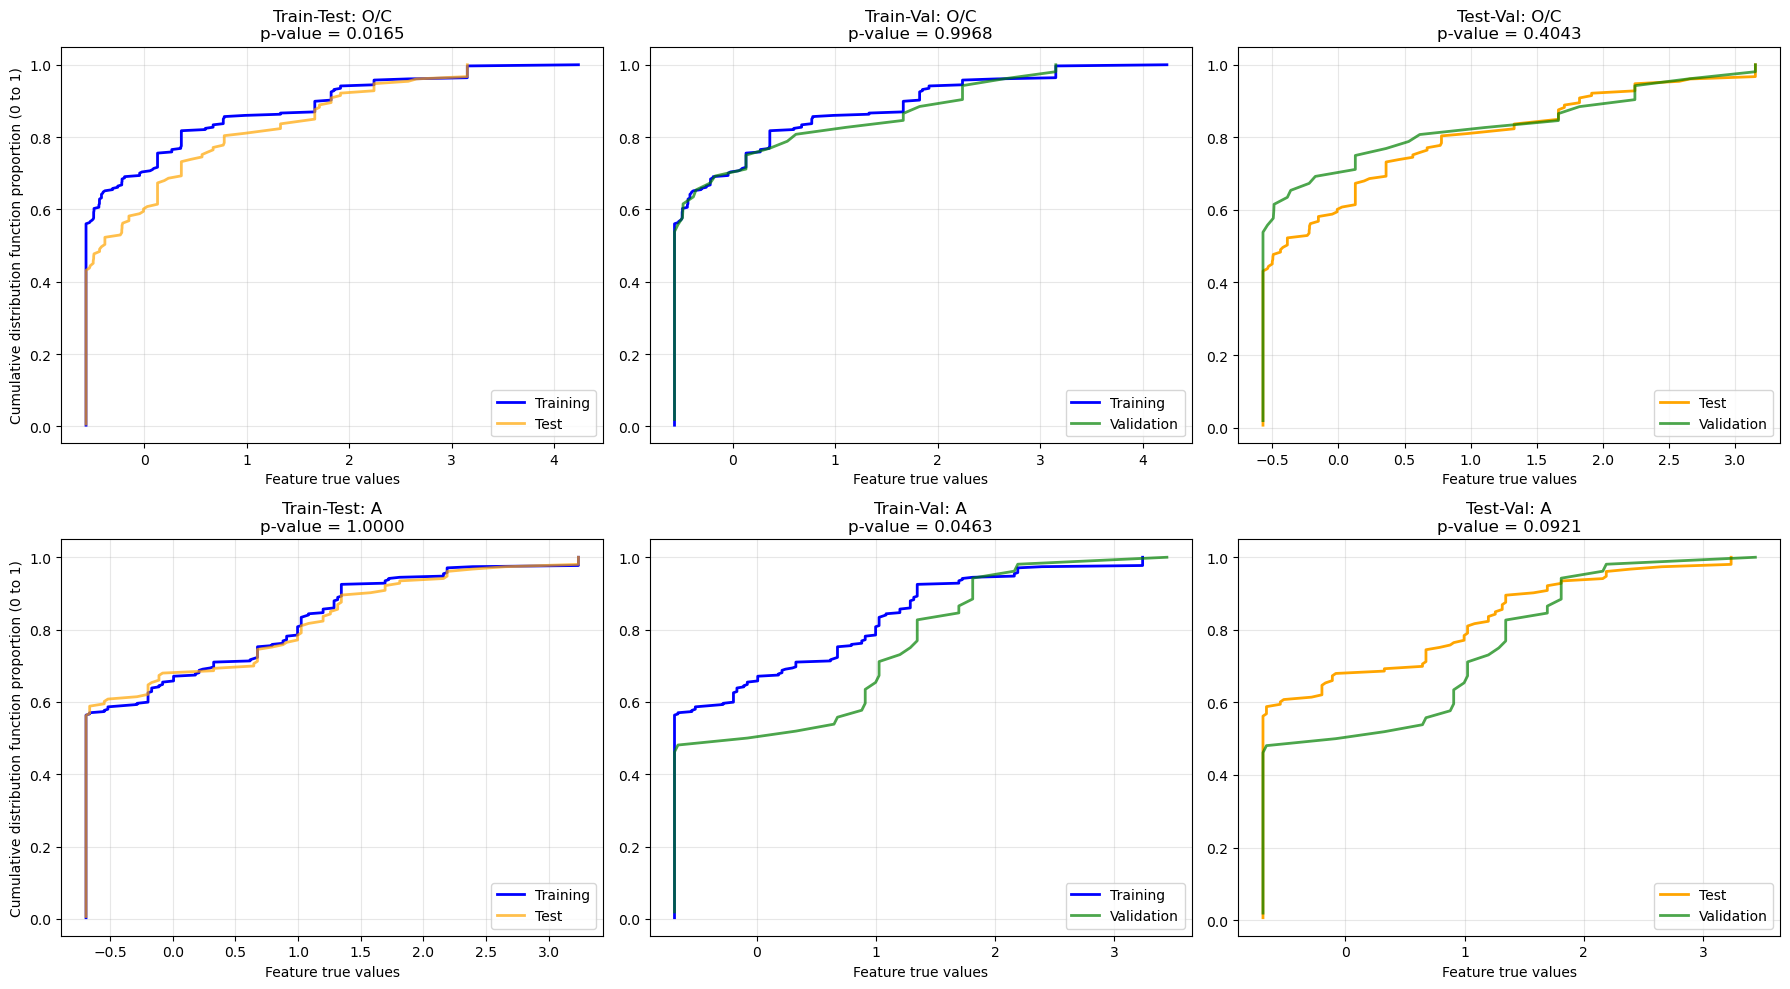

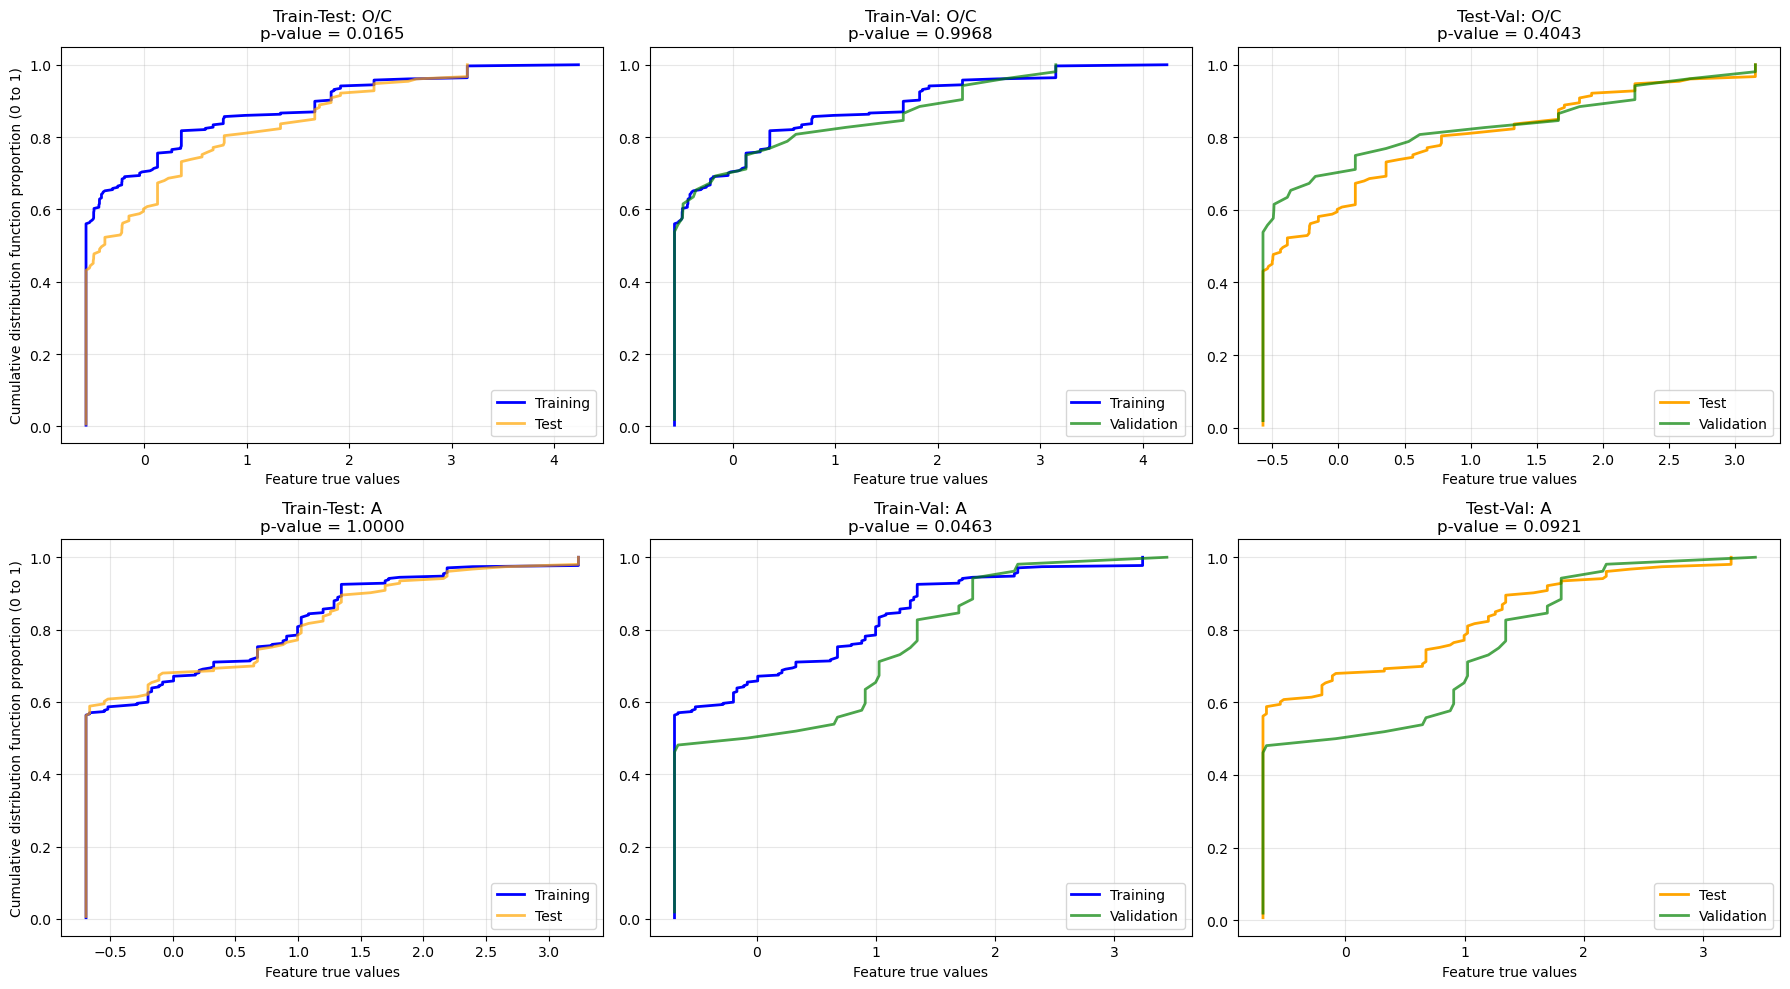

In [5]:
# Identify features that failed KS test and plot their CDF comparisons (O/C and A)
failed_features = ks_df[~ks_df['same_distribution']]['feature'].tolist()
plot_ks_cdf_figure(train_df, test_df, val_df, failed_features, ks_df)

In [6]:
FEATURES = ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V']
TARGET = 'log(Kd)' 
STRATIFY_COLS = ['O/C', 'A']  # need stratification features 

In [7]:

# Process the 'O/C' and 'A' to perform stratified splitting
def stratified_split(df, features, target, test_size=0.2, val_size=0.125, random_state=42):
    df_split = df.copy().reset_index(drop=True)  
    
    # Stratification based on O/C ratio
    o_c_values = df_split['O/C'].values
    
    # Create binary bins for 'O/C': low (<=0.01) vs. high (>0.01), if both groups exist
    if (o_c_values > 0.01).sum() > 0 and (o_c_values <= 0.01).sum() > 0:
        o_c_bins = [-0.001, 0.01, np.inf] # Slightly below zero to handle possible negatives
        o_c_labels = [0, 1]  # 0: low O/C, 1: high O/C
    else:
        o_c_bins = [-0.001, np.inf]
        o_c_labels = [0]
    df_split['O/C_strat'] = pd.cut(df_split['O/C'], bins=o_c_bins, labels=o_c_labels)
    
    # Stratification based on feature 'A' using quantile-based binning 
    a_values = df_split['A'].values
    a_labels = [0]
    
    try:
        # Split 'A' into 3 quantile-based bins (tertiles)
        a_bins = pd.qcut(a_values, q=3, duplicates='drop')
        a_unique_bins = a_bins.cat.categories.nunique()
        a_labels = list(range(a_unique_bins))
        df_split['A_strat'] = pd.qcut(a_values, q=3, labels=a_labels, duplicates='drop')
    except:
        # If quantile binning fails (e.g., too few unique values), assign all to one group
        df_split['A_strat'] = 0
        a_labels = [0]
    
    # Combine both stratification dimensions into a single categorical label
    df_split['strat_label'] = df_split['O/C_strat'].astype(str) + '_' + df_split['A_strat'].astype(str)

    X = df_split[features]
    y = df_split[target]
    strat_label = df_split['strat_label']
    
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, stratify=strat_label, random_state=random_state
    )
    strat_label_train_val = df_split.loc[X_train_val.index, 'strat_label']
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size/(1-test_size), 
        stratify=strat_label_train_val, random_state=random_state
    )
    
    # Reset indices to avoid misalignment in downstream operations
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    X_val = X_val.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    y_val = y_val.reset_index(drop=True)
    
    print(f"\nSample counts after splitting:")
    print(f"Training:{len(X_train)} samples, Test:{len(X_test)} samples, Validation:{len(X_val)} samples")
    return X_train, X_test, X_val, y_train, y_test, y_val

# Re-generate aligned train/test/val datasets using stratified splitting
x_train, x_test, x_val, y_train, y_test, y_val = stratified_split(
    df, FEATURES, TARGET
)

print(f"\nAfter re-splitting - x_train samples: {len(x_train)}, y_train samples: {len(y_train)}")


Sample counts after splitting:
Training:345 samples, Test:103 samples, Validation:64 samples

After re-splitting - x_train samples: 345, y_train samples: 345


In [8]:
def ks_test_validation(X_train, X_test, X_val, test_features):
    print("KS test results (Objective: p-value > 0.05, no significant distribution shift)")
    
    for feat in test_features:
        print(f"\nFeature:{feat}")
        ks_stat_tt, p_val_tt = stats.ks_2samp(x_train[feat], x_test[feat])
        ks_stat_tv, p_val_tv = stats.ks_2samp(x_train[feat], x_val[feat])
        ks_stat_tv2, p_val_tv2 = stats.ks_2samp(x_test[feat], x_val[feat])  # Optional: test vs val

        print(f"  Training vs Test: KS={ks_stat_tt:.4f}, p-value={p_val_tt:.4f} {'✅' if p_val_tt > 0.05 else '⚠️'}")
        print(f"  Training vs Validation: KS={ks_stat_tv:.4f}, p-value={p_val_tv:.4f} {'✅' if p_val_tv > 0.05 else '⚠️'}")
        print(f"  Test vs Validation: KS={ks_stat_tv2:.4f}, p-value={p_val_tv2:.4f} {'✅' if p_val_tv2 > 0.05 else '⚠️'}")

# Validate the new splits with KS test on specified features
ks_test_validation(x_train, x_test, x_val, test_features=['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V'])

KS test results (Objective: p-value > 0.05, no significant distribution shift)

Feature:SSA
  Training vs Test: KS=0.1275, p-value=0.1373 ✅
  Training vs Validation: KS=0.1243, p-value=0.3424 ✅
  Test vs Validation: KS=0.1992, p-value=0.0733 ✅

Feature:C%
  Training vs Test: KS=0.1225, p-value=0.1679 ✅
  Training vs Validation: KS=0.0958, p-value=0.6642 ✅
  Test vs Validation: KS=0.1390, p-value=0.3857 ✅

Feature:H/C
  Training vs Test: KS=0.1028, p-value=0.3431 ✅
  Training vs Validation: KS=0.0934, p-value=0.6939 ✅
  Test vs Validation: KS=0.1675, p-value=0.1899 ✅

Feature:O/C
  Training vs Test: KS=0.0442, p-value=0.9954 ✅
  Training vs Validation: KS=0.1207, p-value=0.3764 ✅
  Test vs Validation: KS=0.1468, p-value=0.3218 ✅

Feature:E
  Training vs Test: KS=0.1085, p-value=0.2831 ✅
  Training vs Validation: KS=0.1250, p-value=0.3361 ✅
  Test vs Validation: KS=0.1387, p-value=0.3893 ✅

Feature:S
  Training vs Test: KS=0.0910, p-value=0.4933 ✅
  Training vs Validation: KS=0.1241, p-v

In [9]:
def evaluate_model(model, x_train, y_train, x_test, y_test, x_val, y_val, model_name):
    # ensure feature data is 2-dimensional
    def ensure_2d(data):
        if isinstance(data, pd.Series):
            # Convert pandas Series to DataFrame (2D)
            return data.to_frame()
        elif isinstance(data, np.ndarray):
            # Reshape 1D NumPy array to 2D (n_samples, 1)
            if len(data.shape) == 1:
                return data.reshape(-1, 1)
            return data
        return data
    
    x_train_2d = ensure_2d(x_train)
    x_test_2d = ensure_2d(x_test)
    x_val_2d = ensure_2d(x_val)
    
    y_train_pred = model.predict(x_train_2d).ravel()  
    y_test_pred = model.predict(x_test_2d).ravel()  
    y_val_pred = model.predict(x_val_2d).ravel()   
    
    # Compute regression metrics: R² and RMSE for all three splits
    metrics = {
        "Train R²": r2_score(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test R²": r2_score(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Val R²": r2_score(y_val, y_val_pred),
        "Val RMSE": np.sqrt(mean_squared_error(y_val, y_val_pred)),
    }

    print(f"  x_train: {x_train_2d.shape}, x_test: {x_test_2d.shape}, x_val: {x_val_2d.shape}")
    for k, v in metrics.items():
            print(f"{k}: {v:.4f}")

SVM

In [29]:
print("Traditional SVM")
svm_param_grid = {
    'C': [0.01, 0.05, 0.1, 0.2, 1.0],                # Regularization parameter
    'gamma': ['scale', 'auto', 0.001, 0.005, 0.01],  # Kernel coefficient
    'epsilon': [0.01, 0.05, 0.1]                     # Epsilon-tube for insensitive loss function
}

# Perform randomized hyperparameter search using RandomizedSearchCV
svm_random = RandomizedSearchCV(
    estimator=SVR(kernel='rbf'),  
    param_distributions=svm_param_grid, 
    n_iter=30,     # Number of random parameter combinations to evaluate
    cv=5,          # 5-fold cross-validation
    scoring='r2',  # Optimize for R² score during validation
    n_jobs=-1, 
    random_state=1 
)

svm_random.fit(x_train, y_train)
print(f"Best SVM parameters: {svm_random.best_params_}")
SVM_model = svm_random.best_estimator_
evaluate_model(SVM_model, x_train, y_train, x_test, y_test, x_val, y_val, "SVM")

Traditional SVM
Best SVM parameters: {'gamma': 'auto', 'epsilon': 0.1, 'C': 0.2}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.4212
Train RMSE: 1.2767
Test R²: 0.3899
Test RMSE: 1.3367
Val R²: 0.3769
Val RMSE: 1.2181


GPR

In [30]:
param_dist = {
    'kernel': [
        # Kernel option 1: Moderate complexity
        C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(x_train.shape[1]), 
                               length_scale_bounds=(1e-4, 1e6)) + 
        WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1)),
        
        # Kernel option 2: Higher flexibility and noise tolerance
        C(1.0, (1e-2, 1e2)) * RBF(length_scale=np.ones(x_train.shape[1]), 
                               length_scale_bounds=(1e-3, 1e7)) + 
        WhiteKernel(noise_level=0.5, noise_level_bounds=(1e-4, 10)),
        
        #  Kernel option 3: Very flexible with wide bounds and higher noise level
        C(1.0, (1e-1, 1e1)) * RBF(length_scale=np.ones(x_train.shape[1]), 
                               length_scale_bounds=(1e-2, 1e8)) + 
        WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 100))
    ],
    'alpha': [1e-3, 1e-2, 1e-1, 1e0],   # Observation noise variance (added to diagonal of kernel matrix)
    'normalize_y': [True, False],       # Whether to normalize the target variable before fitting
    'n_restarts_optimizer': [5, 10, 15] # Number of restarts for the optimizer to avoid local minima
}

base_gpr = GaussianProcessRegressor(random_state=0)

# Randomized search for hyperparameter optimization
random_search = RandomizedSearchCV(
    estimator=base_gpr,
    param_distributions=param_dist,
    n_iter=25,    # Number of random parameter settings sampled 
    cv=5,         # 5-fold cross-validation 
    scoring='r2', # Optimize for R² score during validation
    n_jobs=-1,  
    random_state=42,
    verbose=1,
    error_score='raise'
)

random_search.fit(x_train, y_train)
best_gpr = random_search.best_estimator_
best_params = random_search.best_params_
print(f"Best GPR parameters: {best_params}")

evaluate_model(best_gpr, x_train, y_train, x_test, y_test, x_val, y_val, "GPR-RandomSearch")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best GPR parameters: {'normalize_y': True, 'n_restarts_optimizer': 10, 'kernel': 1**2 * RBF(length_scale=[1, 1, 1, 1, 1, 1, 1, 1, 1]) + WhiteKernel(noise_level=0.5), 'alpha': 0.1}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9559
Train RMSE: 0.3523
Test R²: 0.6810
Test RMSE: 0.9666
Val R²: 0.5977
Val RMSE: 0.9788


In [31]:
# Convert pandas DataFrames to NumPy arrays if necessary
if hasattr(x_train, 'values'):
    x_train = x_train.values
    x_test = x_test.values
    x_val = x_val.values
if hasattr(y_train, 'values'):
    y_train = y_train.values
    y_test = y_test.values
    y_val = y_val.values

feature_names = ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V']

Regression

In [32]:
# Linear Regression
print("Linear Regression")
LR_model = LinearRegression()

LR_model.fit(x_train, y_train)

evaluate_model(LR_model, x_train, y_train, x_test, y_test, x_val, y_val, "LR")

Linear Regression
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.3782
Train RMSE: 1.3232
Test R²: 0.4981
Test RMSE: 1.2124
Val R²: 0.3610
Val RMSE: 1.2336


In [33]:
# Linear Regression
print("Two Linear Regression Models: ppLFER (5 features) vs. LR (9 features)")

# Define feature names for both equations 
features_S3 = ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V'] # All 9 features for LR
features_S2 = ['E', 'S', 'A', 'B', 'V']                     # First 5 features for ppLFER

# Prepare feature matrices for both models
# ppLFER first 5 features 
X_S2_train = x_train[:, 0:5]
X_S2_test = x_test[:, 0:5]
X_S2_val = x_val[:, 0:5]

# LR: all 9 features 
X_S3_train = x_train
X_S3_test = x_test
X_S3_val = x_val


# Fit linear regression models for both equations and print coefficients
# Model 1: ppLFER (5 features)
LR_S2 = LinearRegression()
LR_S2.fit(X_S2_train, y_train)

print(f"\nppLFER (5 features):")
print(f"  Intercept: {LR_S2.intercept_:.4f}")
for feat, coef in zip(features_S2, LR_S2.coef_):
    print(f"    {feat}: {coef:.4f}")

# Model 2: LR (9 features)
LR_S3 = LinearRegression()
LR_S3.fit(X_S3_train, y_train)

print(f"\nLR (9 features):")
print(f"  Intercept: {LR_S3.intercept_:.4f}")
for feat, coef in zip(features_S3, LR_S3.coef_):
    print(f"    {feat}: {coef:.4f}")


# Function to get predictions and compute metrics for both models
def get_predictions_and_metrics(model, X_train, y_train, X_test, y_test, X_val, y_val):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    val_pred = model.predict(X_val)
    
    metrics = {
        'train_r2': r2_score(y_train, train_pred),
        'test_r2': r2_score(y_test, test_pred),
        'val_r2': r2_score(y_val, val_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred)),
        'val_rmse': np.sqrt(mean_squared_error(y_val, val_pred))
    }
    
    return train_pred, test_pred, val_pred, metrics

pred_S2_train, pred_S2_test, pred_S2_val, metrics_S2 = get_predictions_and_metrics(
    LR_S2, X_S2_train, y_train, X_S2_test, y_test, X_S2_val, y_val
)

pred_S3_train, pred_S3_test, pred_S3_val, metrics_S3 = get_predictions_and_metrics(
    LR_S3, X_S3_train, y_train, X_S3_test, y_test, X_S3_val, y_val
)

print(f"\nppLFER (5 features):")
print(f"  Training:  R² = {metrics_S2['train_r2']:.4f}, RMSE = {metrics_S2['train_rmse']:.4f}")
print(f"  Test:      R² = {metrics_S2['test_r2']:.4f}, RMSE = {metrics_S2['test_rmse']:.4f}")
print(f"  Validation: R² = {metrics_S2['val_r2']:.4f}, RMSE = {metrics_S2['val_rmse']:.4f}")

print(f"\nLR (9 features):")
print(f"  Training:  R² = {metrics_S3['train_r2']:.4f}, RMSE = {metrics_S3['train_rmse']:.4f}")
print(f"  Test:      R² = {metrics_S3['test_r2']:.4f}, RMSE = {metrics_S3['test_rmse']:.4f}")
print(f"  Validation: R² = {metrics_S3['val_r2']:.4f}, RMSE = {metrics_S3['val_rmse']:.4f}")

# Paired t-test for the differences in predictions between ppLFER and LR
diff_train = pred_S2_train - pred_S3_train
diff_test = pred_S2_test - pred_S3_test
diff_val = pred_S2_val - pred_S3_val

t_train, p_train = stats.ttest_rel(pred_S2_train, pred_S3_train)
t_test, p_test = stats.ttest_rel(pred_S2_test, pred_S3_test)
t_val, p_val = stats.ttest_rel(pred_S2_val, pred_S3_val)

table_s2_data = {
    '': ['training', 'test', 'validation'],
    'mean': [np.mean(diff_train), np.mean(diff_test), np.mean(diff_val)],
    'Std. deviation': [np.std(diff_train, ddof=1), np.std(diff_test, ddof=1), np.std(diff_val, ddof=1)],
    'Std. error mean': [np.std(diff_train, ddof=1)/np.sqrt(len(diff_train)), 
                        np.std(diff_test, ddof=1)/np.sqrt(len(diff_test)), 
                        np.std(diff_val, ddof=1)/np.sqrt(len(diff_val))],
    'Lower': [np.mean(diff_train) - 1.96*np.std(diff_train, ddof=1)/np.sqrt(len(diff_train)),
              np.mean(diff_test) - 1.96*np.std(diff_test, ddof=1)/np.sqrt(len(diff_test)),
              np.mean(diff_val) - 1.96*np.std(diff_val, ddof=1)/np.sqrt(len(diff_val))],
    'Upper': [np.mean(diff_train) + 1.96*np.std(diff_train, ddof=1)/np.sqrt(len(diff_train)),
              np.mean(diff_test) + 1.96*np.std(diff_test, ddof=1)/np.sqrt(len(diff_test)),
              np.mean(diff_val) + 1.96*np.std(diff_val, ddof=1)/np.sqrt(len(diff_val))],
    't': [t_train, t_test, t_val],
    'Degree of freedom': [len(diff_train)-1, len(diff_test)-1, len(diff_val)-1],
    'p-value': [p_train, p_test, p_val]
}

table_s2 = pd.DataFrame(table_s2_data)

print("\nPair samples t-test of ppLFER and LR prediction")
print("-"*90)
print(table_s2.to_string(index=False))
print("-"*90)

Two Linear Regression Models: ppLFER (5 features) vs. LR (9 features)

ppLFER (5 features):
  Intercept: 1.5187
    E: 0.0130
    S: 1.5377
    A: -3.4237
    B: -0.1112
    V: 0.1876

LR (9 features):
  Intercept: 1.7723
    SSA: 0.0069
    C%: 1.1022
    H/C: -2.2384
    O/C: -0.2180
    E: 0.6646
    S: 0.0207
    A: -0.6221
    B: -1.1006
    V: 0.0623

ppLFER (5 features):
  Training:  R² = 0.1020, RMSE = 1.5902
  Test:      R² = 0.1145, RMSE = 1.6105
  Validation: R² = -0.0889, RMSE = 1.6103

LR (9 features):
  Training:  R² = 0.3782, RMSE = 1.3232
  Test:      R² = 0.4981, RMSE = 1.2124
  Validation: R² = 0.3610, RMSE = 1.2336

Pair samples t-test of ppLFER and LR prediction
------------------------------------------------------------------------------------------
                    mean  Std. deviation  Std. error mean     Lower    Upper             t  Degree of freedom  p-value
  training -4.865673e-16        0.883289         0.047555 -0.093207 0.093207 -1.023174e-14         

In [34]:
print("\n[Assumption 2: Normality of Differences]")

normality_results = {}

for name, diff in [('Train', diff_train), ('Test', diff_test), ('Val', diff_val)]:
    # Shapiro-Wilk test 
    stat_sw, p_sw = shapiro(diff[:5000])  
    
    normality_results[name] = {
        'p_sw': p_sw,
        'is_normal': p_sw > 0.05
    }
    
    p_sw_display = f"{p_sw:.2e}" if p_sw < 0.001 else f"{p_sw:.4f}"
    
    print(f"{name:6s} set: Shapiro-Wilk p = {p_sw_display}, "
          f"{'✅ Approx. normal' if p_sw > 0.05 else '⚠️ Non-normal'}")


[Assumption 2: Normality of Differences]
Train  set: Shapiro-Wilk p = 4.17e-09, ⚠️ Non-normal
Test   set: Shapiro-Wilk p = 1.07e-05, ⚠️ Non-normal
Val    set: Shapiro-Wilk p = 1.41e-05, ⚠️ Non-normal


In [35]:
print("\n【Assumption 3: Independence of Differences】")
from statsmodels.stats.stattools import durbin_watson
for name, diff in [('Train', diff_train), ('Test', diff_test), ('Val', diff_val)]:
    dw = durbin_watson(diff)
    print(f"{name:6s} set: Durbin-Watson = {dw:.3f} → "
          f"{'✅ No autocorrelation' if 1.5 < dw < 2.5 else '⚠️ Possible autocorrelation'}")


【Assumption 3: Independence of Differences】
Train  set: Durbin-Watson = 1.791 → ✅ No autocorrelation
Test   set: Durbin-Watson = 1.658 → ✅ No autocorrelation
Val    set: Durbin-Watson = 1.535 → ✅ No autocorrelation


In [36]:
print("\n[Verification of the Independence of the Tour Itinerary]")
for name, diff in [('Train', diff_train), ('Test', diff_test), ('Val', diff_val)]:
    # Runs Test: Classify the residuals into positive and negative categories based on the mean of the differences
    z_stat, p_run = runstest_1samp(diff, cutoff='mean')
    print(f"{name:6s} set: Runs Test z = {z_stat:.3f}, p = {p_run:.4f} → "
          f"{'✅ Random/Independent' if p_run > 0.05 else '⚠️ Non-random/Dependent'}")


[Verification of the Independence of the Tour Itinerary]
Train  set: Runs Test z = -0.692, p = 0.4889 → ✅ Random/Independent
Test   set: Runs Test z = -0.285, p = 0.7757 → ✅ Random/Independent
Val    set: Runs Test z = -0.573, p = 0.5664 → ✅ Random/Independent


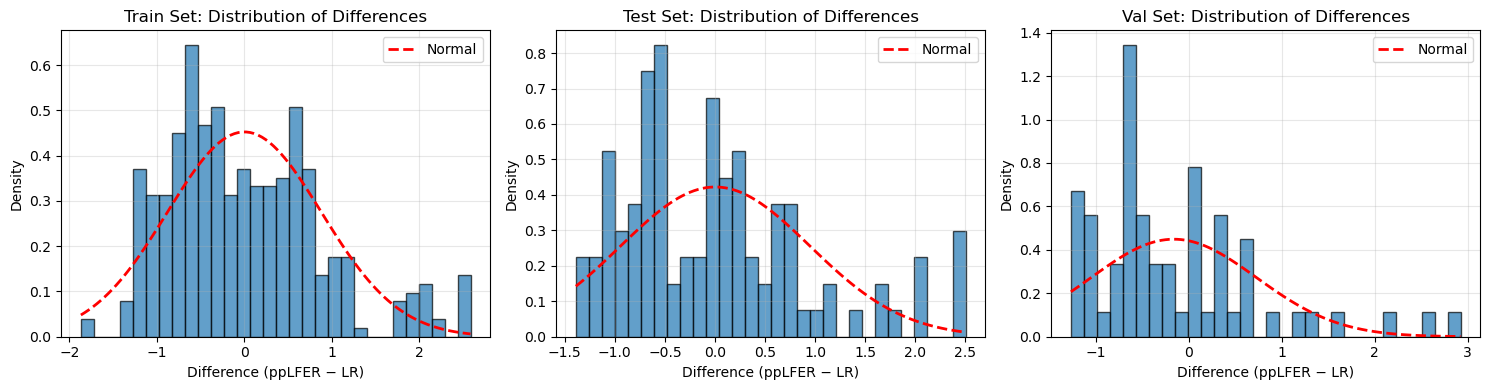

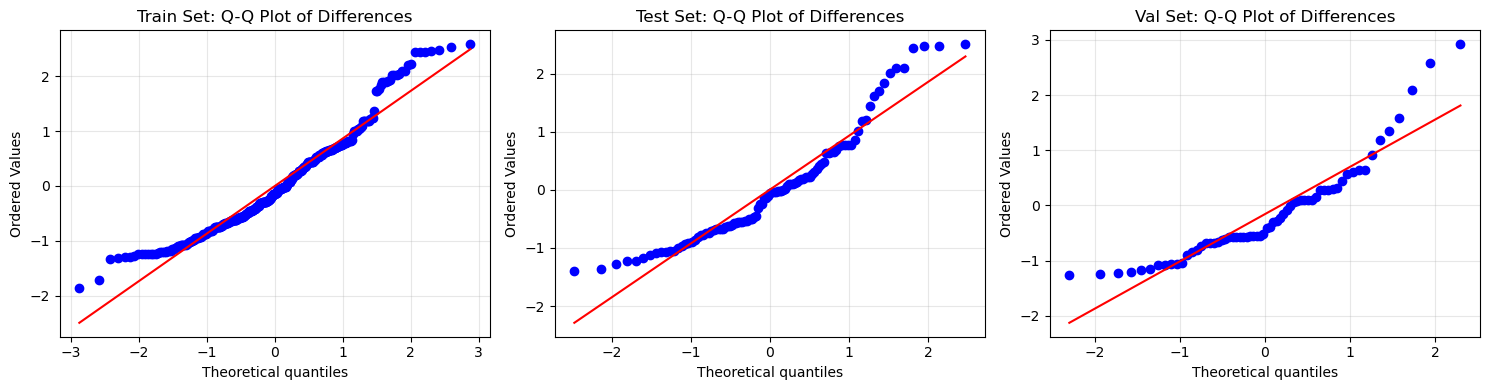

In [37]:
# Histogram with overlaid normal distribution curve
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, diff, name in zip(axes, [diff_train, diff_test, diff_val], ['Train', 'Test', 'Val']):
    ax.hist(diff, bins=30, edgecolor='black', alpha=0.7, density=True)
    
    x = np.linspace(diff.min(), diff.max(), 100)
    ax.plot(x, stats.norm.pdf(x, np.mean(diff), np.std(diff)), 'r--', linewidth=2, label='Normal')
    
    ax.set_title(f'{name} Set: Distribution of Differences')
    ax.set_xlabel('Difference (ppLFER − LR)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Q-Q plot to visually assess normality of differences
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, diff, name in zip(axes, [diff_train, diff_test, diff_val], ['Train', 'Test', 'Val']):
    stats.probplot(diff, dist="norm", plot=ax)
    ax.set_title(f'{name} Set: Q-Q Plot of Differences')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
def bootstrap_mean_ci(data, n_boot=5000, alpha=0.05, seed=42):
    np.random.seed(seed)
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) 
                  for _ in range(n_boot)]
    ci_lower = np.percentile(boot_means, 100*alpha/2)
    ci_upper = np.percentile(boot_means, 100*(1-alpha/2))
    return np.mean(data), (ci_lower, ci_upper)

print(f"\n{'Set':<8} {'Mean Diff':<12} {'95% CI':<25} {'Includes 0?'}")
print("-"*60)
for name, diff in [('Train', diff_train), ('Test', diff_test), ('Val', diff_val)]:
    mean_diff, (ci_low, ci_high) = bootstrap_mean_ci(diff)
    includes_0 = 'Yes' if ci_low <= 0 <= ci_high else 'No'
    print(f"{name:<8} {mean_diff:<12.4f} [{ci_low:.4f}, {ci_high:.4f}]  {includes_0}")


Set      Mean Diff    95% CI                    Includes 0?
------------------------------------------------------------
Train    -0.0000      [-0.0883, 0.0921]  Yes
Test     0.0031       [-0.1768, 0.1958]  Yes
Val      -0.1591      [-0.3695, 0.0680]  Yes


In [39]:
print("REGRESSION EQUATIONS")

def format_equation(intercept, coefficients, feature_names, precision=4):
    equation = f"log Kd = {intercept:.{precision}f}"
    
    for feat, coef in zip(feature_names, coefficients):
        if coef >= 0:
            equation += f" + {coef:.{precision}f} × {feat}"
        else:
            equation += f" - {abs(coef):.{precision}f} × {feat}"
    
    return equation

# ppLFER Equation (5 features)
print("\nppLFER (5 features)")
print("-"*70)
ppLFER_equation = format_equation(LR_S2.intercept_, LR_S2.coef_, features_S2)
print(f"{ppLFER_equation}")
print("\nCoefficient:")
print(f"  Intercept = {LR_S2.intercept_:.4f}")
for feat, coef in zip(features_S2, LR_S2.coef_):
    print(f"  {feat:<5} = {coef:+.4f}")

# MLR Equation (9 features)
print("\nMLR (9 features)")
print("-"*70)
LR_equation = format_equation(LR_S3.intercept_, LR_S3.coef_, features_S3)
print(f"{LR_equation}")
print("\nCoefficient:")
print(f"  Intercept = {LR_S3.intercept_:.4f}")
for feat, coef in zip(features_S3, LR_S3.coef_):
    print(f"  {feat:<5} = {coef:+.4f}")

REGRESSION EQUATIONS

ppLFER (5 features)
----------------------------------------------------------------------
log Kd = 1.5187 + 0.0130 × E + 1.5377 × S - 3.4237 × A - 0.1112 × B + 0.1876 × V

Coefficient:
  Intercept = 1.5187
  E     = +0.0130
  S     = +1.5377
  A     = -3.4237
  B     = -0.1112
  V     = +0.1876

MLR (9 features)
----------------------------------------------------------------------
log Kd = 1.7723 + 0.0069 × SSA + 1.1022 × C% - 2.2384 × H/C - 0.2180 × O/C + 0.6646 × E + 0.0207 × S - 0.6221 × A - 1.1006 × B + 0.0623 × V

Coefficient:
  Intercept = 1.7723
  SSA   = +0.0069
  C%    = +1.1022
  H/C   = -2.2384
  O/C   = -0.2180
  E     = +0.6646
  S     = +0.0207
  A     = -0.6221
  B     = -1.1006
  V     = +0.0623


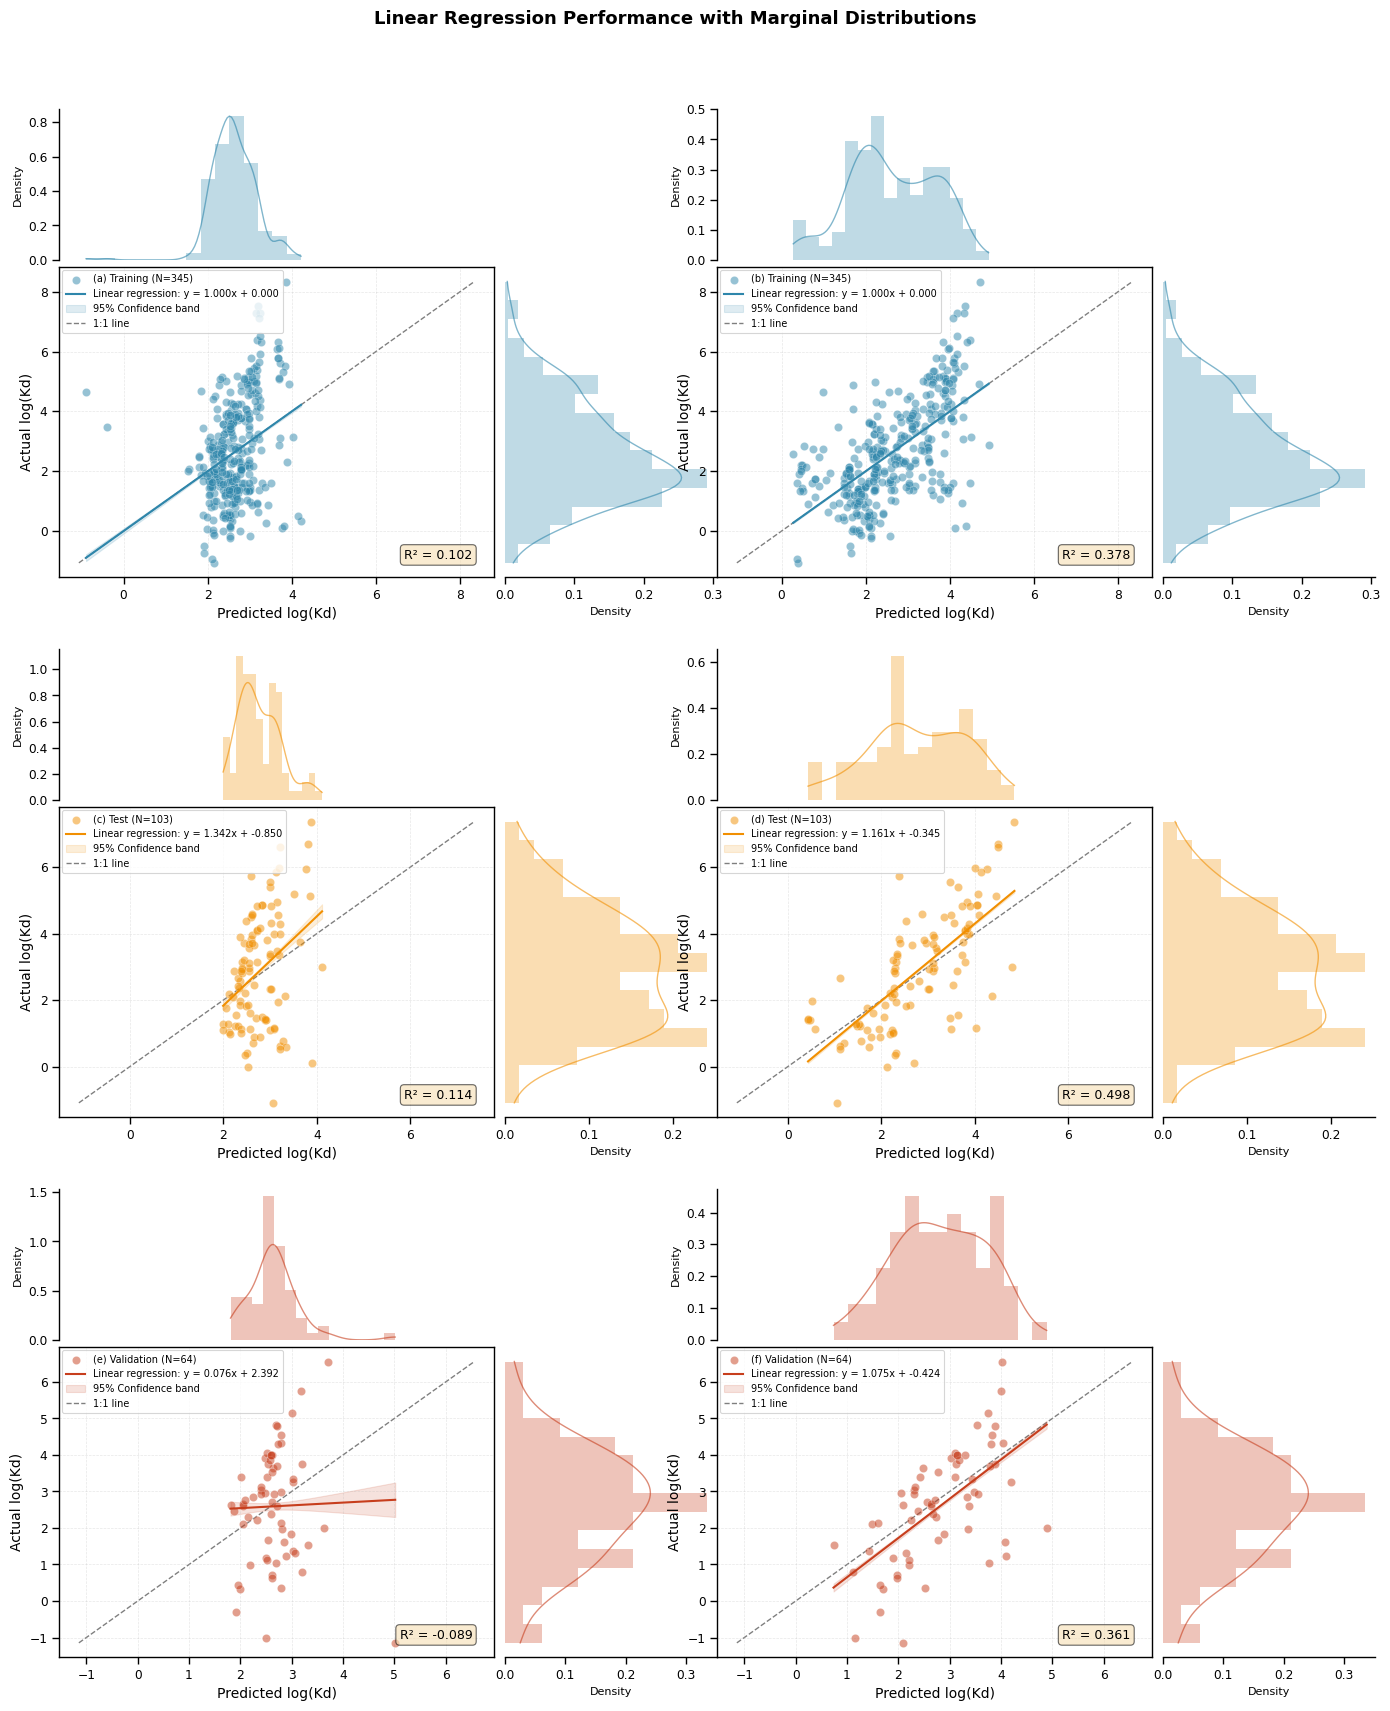

In [40]:
plt.style.use('default')
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.0)

fig = plt.figure(figsize=(14, 18))

colors = {
    'S2_train': '#2E86AB', 'S3_train': '#2E86AB',
    'S2_test': '#F18F01', 'S3_test': '#F18F01',
    'S2_val': '#C73E1D', 'S3_val': '#C73E1D'
}

datasets = [
    ('(a) Training - ppLFER (5 features)', y_train, pred_S2_train, colors['S2_train']),
    ('(b) Training - LR (9 features)', y_train, pred_S3_train, colors['S3_train']),
    ('(c) Test - ppLFER (5 features)', y_test, pred_S2_test, colors['S2_test']),
    ('(d) Test - LR (9 features)', y_test, pred_S3_test, colors['S3_test']),
    ('(e) Validation - ppLFER (5 features)', y_val, pred_S2_val, colors['S2_val']),
    ('(f) Validation - LR (9 features)', y_val, pred_S3_val, colors['S3_val']),
]

for idx, (title, y_actual, y_pred, color) in enumerate(datasets):
    row = idx // 2
    col = idx % 2
    
    gs = gridspec.GridSpec(3, 3, 
                           left=0.06 + col * 0.47, 
                           right=0.06 + (col + 1) * 0.47,
                           top=0.93 - row * 0.30, 
                           bottom=0.07 + (2 - row) * 0.30,
                           wspace=0.05, hspace=0.05)

    ax_main = fig.add_subplot(gs[1:, :-1])
    
    ax_top = fig.add_subplot(gs[0, :-1], sharex=ax_main)

    ax_right = fig.add_subplot(gs[1:, -1], sharey=ax_main)
    
    ax_main.scatter(y_pred, y_actual, color=color, alpha=0.5, s=35, 
                    edgecolors='white', linewidth=0.3, zorder=2, label=f'{title.split("-")[0].strip()} (N={len(y_actual)})')
    
    z = np.polyfit(y_pred, y_actual, 1)
    p = np.poly1d(z)
    x_line = np.linspace(y_pred.min(), y_pred.max(), 100)
    y_line = p(x_line)
    ax_main.plot(x_line, y_line, color=color, linewidth=1.5, 
                 label=f'Linear regression: y = {z[0]:.3f}x + {z[1]:.3f}', zorder=3)
    
    n = len(y_pred)
    y_pred_main = p(y_pred)
    residuals = y_actual - y_pred_main
    mse = np.sum(residuals**2) / (n - 2)
    se = np.sqrt(mse / np.sum((y_pred - np.mean(y_pred))**2))
    
    ci_upper = y_line + 1.96 * se * np.sqrt(1/n + (x_line - np.mean(y_pred))**2 / np.sum((y_pred - np.mean(y_pred))**2))
    ci_lower = y_line - 1.96 * se * np.sqrt(1/n + (x_line - np.mean(y_pred))**2 / np.sum((y_pred - np.mean(y_pred))**2))
    ax_main.fill_between(x_line, ci_lower, ci_upper, color=color, alpha=0.15, label='95% Confidence band', zorder=1)
    
    min_val = min(y_pred.min(), y_actual.min())
    max_val = max(y_pred.max(), y_actual.max())
    ax_main.plot([min_val, max_val], [min_val, max_val], 'k--', 
                 linewidth=1, alpha=0.5, label='1:1 line', zorder=0)
    
    r2 = r2_score(y_actual, y_pred)
    ax_main.text(0.95, 0.05, f'R² = {r2:.3f}', transform=ax_main.transAxes, 
                 fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6), zorder=4)
    
    ax_main.set_xlabel('Predicted log(Kd)', fontsize=10)
    ax_main.set_ylabel('Actual log(Kd)', fontsize=10)
    ax_main.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax_main.legend(loc='upper left', fontsize=7, framealpha=0.8, borderaxespad=0.3)
    ax_main.grid(True, alpha=0.3, zorder=0, linestyle='--', linewidth=0.5)
    

    ax_top.hist(y_pred, bins=15, color=color, alpha=0.3, edgecolor='none', 
                density=True, zorder=1)
    kde = gaussian_kde(y_pred)
    x_kde = np.linspace(y_pred.min(), y_pred.max(), 100)
    ax_top.plot(x_kde, kde(x_kde), color=color, linewidth=1, alpha=0.6, zorder=2)
    ax_top.tick_params(labelbottom=False, labelleft=True, left=True, bottom=False)
    ax_top.set_ylabel('Density', fontsize=8)
    ax_top.grid(False)

    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.spines['bottom'].set_visible(False)
    

    ax_right.hist(y_actual, bins=15, color=color, alpha=0.3, edgecolor='none', 
                  density=True, orientation='horizontal', zorder=1)

    kde_y = gaussian_kde(y_actual)
    y_kde = np.linspace(y_actual.min(), y_actual.max(), 100)
    ax_right.plot(kde_y(y_kde), y_kde, color=color, linewidth=1, alpha=0.6, zorder=2)
    ax_right.tick_params(labelleft=False, labelbottom=True, bottom=True, left=False)
    ax_right.set_xlabel('Density', fontsize=8)
    ax_right.grid(False)

    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)
    ax_right.spines['left'].set_visible(False)
    
    ax_main.tick_params(labeltop=False, labelright=False)

plt.suptitle('Linear Regression Performance with Marginal Distributions', 
             fontsize=13, fontweight='bold', y=0.985)
plt.show()

In [41]:
# Lasso Regression
print("Lasso Regression")
lasso_param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0,100],
                    'max_iter': [10000]}  # Regularization strength and max iterations
lasso_random = RandomizedSearchCV(
    estimator=Lasso(random_state=1, max_iter=10000),  
    param_distributions=lasso_param_grid,  
    n_iter=10,  
    cv=5,  
    scoring='r2', 
    n_jobs=-1,  
    random_state=1  
)

lasso_random.fit(x_train, y_train)
print(f"Best Lasso parameters: {lasso_random.best_params_}")
Lasso_model = lasso_random.best_estimator_

evaluate_model(Lasso_model, x_train, y_train, x_test, y_test, x_val, y_val, "Lasso")

Lasso Regression
Best Lasso parameters: {'max_iter': 10000, 'alpha': 0.1}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.3105
Train RMSE: 1.3934
Test R²: 0.4035
Test RMSE: 1.3217
Val R²: 0.2809
Val RMSE: 1.3087


In [42]:
print(f"\nLasso Regression Equation:")
equation_lasso = f"log Kd = {Lasso_model.intercept_:.4f}"
for feat, coef in zip(features_S3, Lasso_model.coef_):
    if coef != 0:  
        sign = "+" if coef >= 0 else "-"
        equation_lasso += f" {sign} {abs(coef):.4f} × {feat}"
print(equation_lasso)


Lasso Regression Equation:
log Kd = 2.5579 + 0.0138 × SSA + 0.4449 × E - 1.0013 × B


In [43]:
# Ridge Regression
print("Ridge Regression")
ridge_param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_random = RandomizedSearchCV(
    estimator=Ridge(random_state=1), 
    param_distributions=ridge_param_grid,  
    n_iter=5, 
    cv=5,  
    scoring='r2',  
    n_jobs=-1, 
    random_state=1 
)
ridge_random.fit(x_train, y_train)
print(f"Best Ridge parameters: {ridge_random.best_params_}")
Ridge_model = ridge_random.best_estimator_
evaluate_model(Ridge_model, x_train, y_train, x_test, y_test, x_val, y_val, "Ridge")

Ridge Regression
Best Ridge parameters: {'alpha': 10.0}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.3653
Train RMSE: 1.3369
Test R²: 0.4722
Test RMSE: 1.2434
Val R²: 0.3579
Val RMSE: 1.2366


In [44]:
print(f"\nRidge Regression Equation:")
equation_ridge = f"log Kd = {Ridge_model.intercept_:.4f}"
for feat, coef in zip(features_S3, Ridge_model.coef_):
    sign = "+" if coef >= 0 else "-"
    equation_ridge += f" {sign} {abs(coef):.4f} × {feat}"
print(equation_ridge)


Ridge Regression Equation:
log Kd = 1.9761 + 0.0098 × SSA + 0.5582 × C% - 0.4971 × H/C - 0.1876 × O/C + 0.6426 × E + 0.0125 × S - 0.5900 × A - 1.0557 × B + 0.0510 × V



Coefficient Comparison (OLS vs Lasso vs Ridge)

Coefficient comparison table:
Feature       OLS     Lasso     Ridge  Ridge_Shrinkage_Ratio  Lasso_Shrinkage_Ratio
    SSA  0.006908  0.013796  0.009763               1.413216               1.996990
     C%  1.102167  0.000000  0.558248               0.506501               0.000000
    H/C -2.238436 -0.000000 -0.497131               0.222089               0.000000
    O/C -0.218037 -0.000000 -0.187611               0.860452               0.000000
      E  0.664603  0.444873  0.642574               0.966854               0.669382
      S  0.020691 -0.000000  0.012491               0.603704               0.000000
      A -0.622059 -0.000000 -0.589975               0.948422               0.000000
      B -1.100555 -1.001263 -1.055740               0.959279               0.909780
      V  0.062325  0.000000  0.050961               0.817664               0.000000


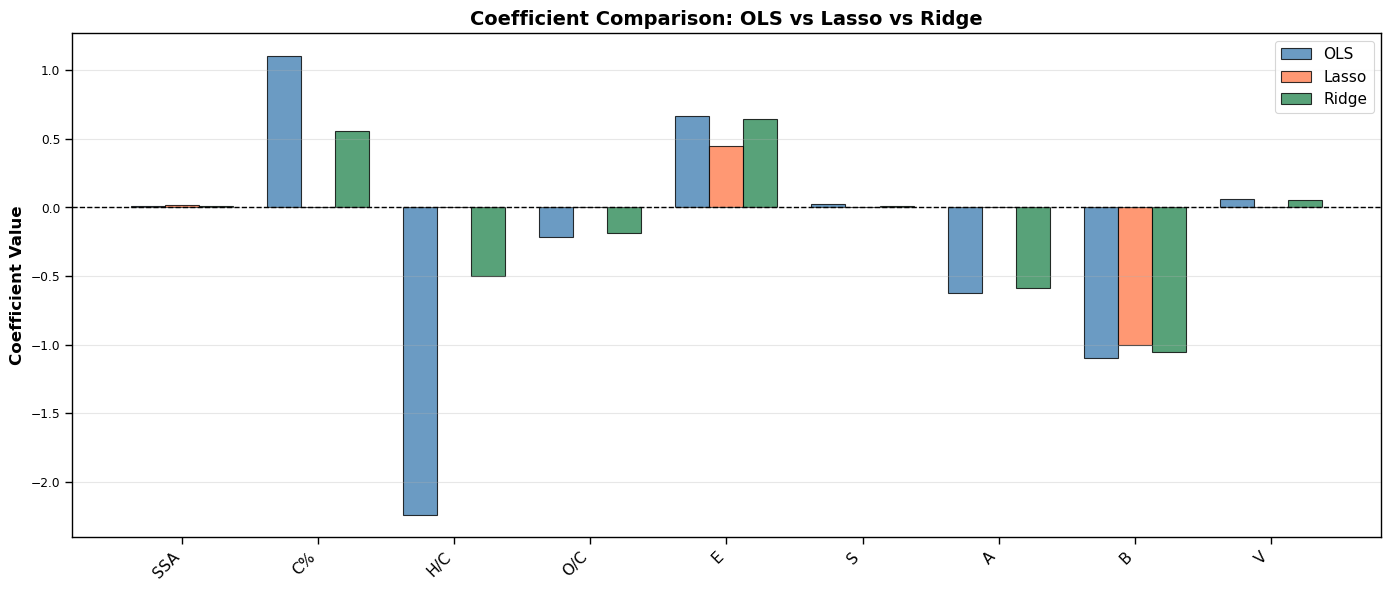

In [45]:
print("\nCoefficient Comparison (OLS vs Lasso vs Ridge)")

ols_model = LinearRegression()
ols_model.fit(x_train, y_train)

lasso_model = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso_model.fit(x_train, y_train)

feature_names = ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V']

coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'OLS': ols_model.coef_,
    'Lasso': lasso_model.coef_,
    'Ridge': Ridge_model.coef_,
    'Ridge_Shrinkage_Ratio': np.abs(Ridge_model.coef_) / (np.abs(ols_model.coef_) + 1e-10),
    'Lasso_Shrinkage_Ratio': np.abs(lasso_model.coef_) / (np.abs(ols_model.coef_) + 1e-10)
})

print("\nCoefficient comparison table:")
print(coef_comparison.to_string(index=False))

fig, ax = plt.subplots(1, 1, figsize=(14, 6))  

x_pos = np.arange(len(feature_names))
width = 0.25

ax.bar(x_pos - width, ols_model.coef_, width, label='OLS', alpha=0.8, color='steelblue', edgecolor='black')
ax.bar(x_pos, lasso_model.coef_, width, label='Lasso', alpha=0.8, color='coral', edgecolor='black')
ax.bar(x_pos + width, Ridge_model.coef_, width, label='Ridge', alpha=0.8, color='seagreen', edgecolor='black')

ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Coefficient Comparison: OLS vs Lasso vs Ridge', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Process Model Analysis with Statistical Tests 

--------------------------------------------------------------------------------
Model (E): SSA, C%, H/C, O/C, B → E
--------------------------------------------------------------------------------
R² = 0.1605
Residual normality test: Shapiro-Wilk p = 0.0000, Jarque-Bera p = 0.0000

Path Coefficients (Standardized):
Predictor  Coef       SE         t          p-value      VIF      Signif
--------------------------------------------------------------------------------
SSA        0.0348     0.0018     0.818      0.4135       1.21     
C%         0.1585     0.0724     9.031      0.0000       4.21     ***
H/C        -0.0653    0.3336     -1.660     0.0975       3.18     
O/C        -0.0329    0.1091     -0.840     0.4012       1.28     
B          0.3515     0.0365     8.640      0.0000       2.00     ***

--------------------------------------------------------------------------------
Model (S): SSA, C%, H/C, O/C, B → S
---------------------

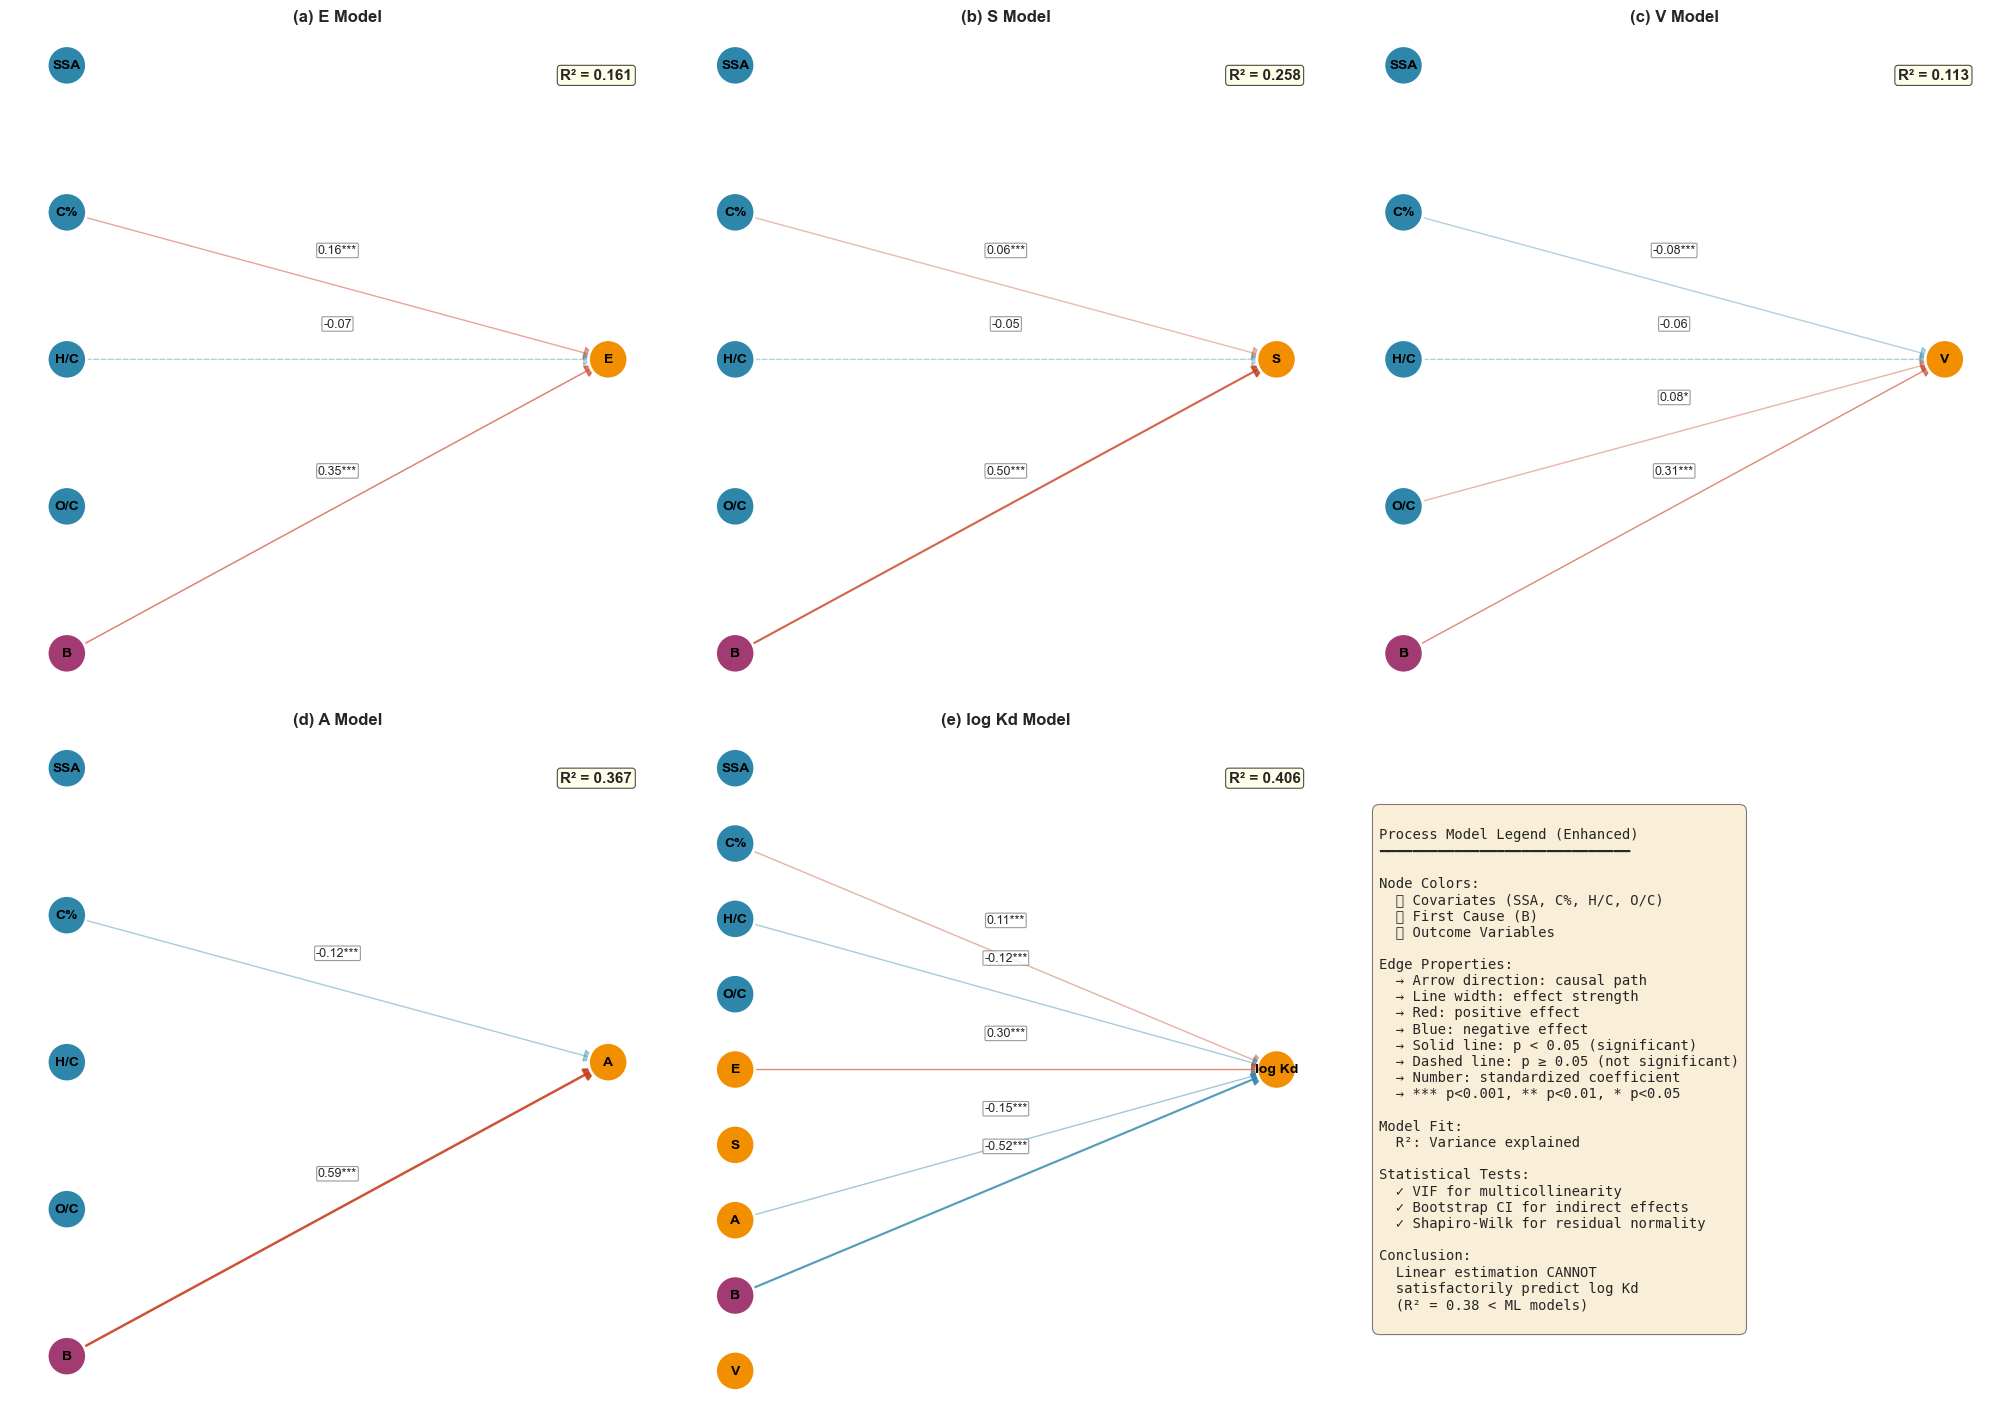

In [46]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print('Process Model Analysis with Statistical Tests ')

X_all = np.vstack([x_train, x_test, x_val])
y_all = np.concatenate([y_train, y_test, y_val])

df_process = pd.DataFrame(X_all, columns=feature_names)
df_process['log_Kd'] = y_all

# Covariances: surface properties and elemental ratios  
covariates = ['SSA', 'C%', 'H/C', 'O/C']

# Mediators: adsorbate properties
mediators = ['E', 'S', 'A', 'V']

# First Cause: feature with the highest correlation to log Kd
first_cause = 'B'

# Outcome
outcome = 'log_Kd'

# Statistical modeling function
def fit_linear_model_with_stats(X, y, feature_names):
    model = LinearRegression()
    model.fit(X, y)
    
    n = X.shape[0]
    p = X.shape[1]
    
    # Predictions and residuals
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # R²
    r2 = r2_score(y, y_pred)
    
    rmse = np.sqrt(np.mean(residuals**2))
    
    # MSE
    mse = np.sum(residuals**2) / (n - p - 1)
    
    # Standard error of coefficients
    XtX_inv = np.linalg.inv(X.T @ X)
    coef_se = np.sqrt(np.diag(XtX_inv) * mse)
    
    # t stats and p-values
    t_stats = model.coef_ / coef_se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))
    
    # Standardized coefficients
    X_std = X.std(axis=0)
    y_std = y.std()
    std_coefs = model.coef_ * X_std / y_std
    
    # VIF
    vif_values = []
    for i in range(p):
        vif = variance_inflation_factor(X, i)
        vif_values.append(vif)
    
    # Normality tests on residuals
    shapiro_stat, shapiro_p = shapiro(residuals[:5000]) 
    jb_stat, jb_p = jarque_bera(residuals)
    
    results = {
        'model': model,
        'coefs': model.coef_,
        'std_coefs': std_coefs,
        'coef_se': coef_se,
        't_stats': t_stats,
        'p_values': p_values,
        'r2': r2,
        'rmse':rmse,
        'vif': vif_values,
        'residuals': residuals,
        'shapiro_stat': shapiro_stat,
        'shapiro_p': shapiro_p,
        'jb_stat': jb_stat,
        'jb_p': jb_p,
        'mse': mse,
        'n': n,
        'p': p
    }
    
    return results

model_results = {}

print("\n" + "-"*80)
print("Model (E): SSA, C%, H/C, O/C, B → E")
print("-"*80)

X_a = df_process[covariates + [first_cause]].values
y_a = df_process['E'].values

results_a = fit_linear_model_with_stats(X_a, y_a, covariates + [first_cause])
model_results['E'] = {
    'coefs': results_a['std_coefs'],
    'p_values': results_a['p_values'],
    'se': results_a['coef_se'],
    'vif': results_a['vif'],
    'r2': results_a['r2'],
    'rmse':results_a['mse'],
    'features': covariates + [first_cause],
    'residuals': results_a['residuals'],
    'shapiro_p': results_a['shapiro_p'],
    'jb_p': results_a['jb_p']
}

print(f"R² = {results_a['r2']:.4f}")
print(f"Residual normality test: Shapiro-Wilk p = {results_a['shapiro_p']:.4f}, Jarque-Bera p = {results_a['jb_p']:.4f}")
print("\nPath Coefficients (Standardized):")
print(f"{'Predictor':<10} {'Coef':<10} {'SE':<10} {'t':<10} {'p-value':<12} {'VIF':<8} {'Signif'}")
print("-"*80)
for i, feat in enumerate(covariates + [first_cause]):
    sig = '***' if results_a['p_values'][i] < 0.001 else '**' if results_a['p_values'][i] < 0.01 else '*' if results_a['p_values'][i] < 0.05 else ''
    print(f"{feat:<10} {results_a['std_coefs'][i]:<10.4f} {results_a['coef_se'][i]:<10.4f} {results_a['t_stats'][i]:<10.3f} {results_a['p_values'][i]:<12.4f} {results_a['vif'][i]:<8.2f} {sig}")


# ============================================================================
print("\n" + "-"*80)
print("Model (S): SSA, C%, H/C, O/C, B → S")
print("-"*80)

X_b = df_process[covariates + [first_cause]].values
y_b = df_process['S'].values

results_b = fit_linear_model_with_stats(X_b, y_b, covariates + [first_cause])
model_results['S'] = {
    'coefs': results_b['std_coefs'],
    'p_values': results_b['p_values'],
    'se': results_b['coef_se'],
    'vif': results_b['vif'],
    'r2': results_b['r2'],
    'rmse':results_b['rmse'],
    'features': covariates + [first_cause],
    'residuals': results_b['residuals'],
    'shapiro_p': results_b['shapiro_p'],
    'jb_p': results_b['jb_p']
}

print(f"R² = {results_b['r2']:.4f}")
print(f"Residual normality test：Shapiro-Wilk p = {results_b['shapiro_p']:.4f}, Jarque-Bera p = {results_b['jb_p']:.4f}")
print("\nPath Coefficients (Standardized):")
print(f"{'Predictor':<10} {'Coef':<10} {'SE':<10} {'t':<10} {'p-value':<12} {'VIF':<8} {'Signif'}")
print("-"*80)
for i, feat in enumerate(covariates + [first_cause]):
    sig = '***' if results_b['p_values'][i] < 0.001 else '**' if results_b['p_values'][i] < 0.01 else '*' if results_b['p_values'][i] < 0.05 else ''
    print(f"{feat:<10} {results_b['std_coefs'][i]:<10.4f} {results_b['coef_se'][i]:<10.4f} {results_b['t_stats'][i]:<10.3f} {results_b['p_values'][i]:<12.4f} {results_b['vif'][i]:<8.2f} {sig}")


# ============================================================================
print("\n" + "-"*80)
print("Model (V): SSA, C%, H/C, O/C, B → V")
print("-"*80)

X_c = df_process[covariates + [first_cause]].values
y_c = df_process['V'].values

results_c = fit_linear_model_with_stats(X_c, y_c, covariates + [first_cause])
model_results['V'] = {
    'coefs': results_c['std_coefs'],
    'p_values': results_c['p_values'],
    'se': results_c['coef_se'],
    'vif': results_c['vif'],
    'r2': results_c['r2'],
    'rmse':results_c['mse'],
    'features': covariates + [first_cause],
    'residuals': results_c['residuals'],
    'shapiro_p': results_c['shapiro_p'],
    'jb_p': results_c['jb_p']
}

print(f"R² = {results_c['r2']:.4f}")
print(f"Residual normality test: Shapiro-Wilk p = {results_c['shapiro_p']:.4f}, Jarque-Bera p = {results_c['jb_p']:.4f}")
print("\nPath Coefficients (Standardized):")
print(f"{'Predictor':<10} {'Coef':<10} {'SE':<10} {'t':<10} {'p-value':<12} {'VIF':<8} {'Signif'}")
print("-"*80)
for i, feat in enumerate(covariates + [first_cause]):
    sig = '***' if results_c['p_values'][i] < 0.001 else '**' if results_c['p_values'][i] < 0.01 else '*' if results_c['p_values'][i] < 0.05 else ''
    print(f"{feat:<10} {results_c['std_coefs'][i]:<10.4f} {results_c['coef_se'][i]:<10.4f} {results_c['t_stats'][i]:<10.3f} {results_c['p_values'][i]:<12.4f} {results_c['vif'][i]:<8.2f} {sig}")


# ============================================================================
print("\n" + "-"*80)
print("Model (A): SSA, C%, H/C, O/C, B → A")
print("-"*80)

X_d = df_process[covariates + [first_cause]].values
y_d = df_process['A'].values

results_d = fit_linear_model_with_stats(X_d, y_d, covariates + [first_cause])
model_results['A'] = {
    'coefs': results_d['std_coefs'],
    'p_values': results_d['p_values'],
    'se': results_d['coef_se'],
    'vif': results_d['vif'],
    'r2': results_d['r2'],
    'rmse':results_d['rmse'],
    'features': covariates + [first_cause],
    'residuals': results_d['residuals'],
    'shapiro_p': results_d['shapiro_p'],
    'jb_p': results_d['jb_p']
}

print(f"R² = {results_d['r2']:.4f}")
print(f"Residual normality test: Shapiro-Wilk p = {results_d['shapiro_p']:.4f}, Jarque-Bera p = {results_d['jb_p']:.4f}")
print("\nPath Coefficients (Standardized):")
print(f"{'Predictor':<10} {'Coef':<10} {'SE':<10} {'t':<10} {'p-value':<12} {'VIF':<8} {'Signif'}")
print("-"*80)
for i, feat in enumerate(covariates + [first_cause]):
    sig = '***' if results_d['p_values'][i] < 0.001 else '**' if results_d['p_values'][i] < 0.01 else '*' if results_d['p_values'][i] < 0.05 else ''
    print(f"{feat:<10} {results_d['std_coefs'][i]:<10.4f} {results_d['coef_se'][i]:<10.4f} {results_d['t_stats'][i]:<10.3f} {results_d['p_values'][i]:<12.4f} {results_d['vif'][i]:<8.2f} {sig}")


# ============================================================================
print("\n" + "-"*80)
print("Model (log Kd): All 9 features → log Kd")
print("-"*80)

X_e = df_process[feature_names].values
y_e = df_process['log_Kd'].values

results_e = fit_linear_model_with_stats(X_e, y_e, feature_names)
model_results['log_Kd'] = {
    'coefs': results_e['std_coefs'],
    'p_values': results_e['p_values'],
    'se': results_e['coef_se'],
    'vif': results_e['vif'],
    'r2': results_e['r2'],
    'rmse': results_e['rmse'],
    'features': feature_names,
    'residuals': results_e['residuals'],
    'shapiro_p': results_e['shapiro_p'],
    'jb_p': results_e['jb_p']
}

print(f"R² = {results_e['r2']:.4f}")
print(f"Residual normality test: Shapiro-Wilk p = {results_e['shapiro_p']:.4f}, Jarque-Bera p = {results_e['jb_p']:.4f}")
print("\nPath Coefficients (Standardized):")
print(f"{'Predictor':<10} {'Coef':<10} {'SE':<10} {'t':<10} {'p-value':<12} {'VIF':<8} {'Signif'}")
print("-"*80)
for i, feat in enumerate(feature_names):
    sig = '***' if results_e['p_values'][i] < 0.001 else '**' if results_e['p_values'][i] < 0.01 else '*' if results_e['p_values'][i] < 0.05 else ''
    print(f"{feat:<10} {results_e['std_coefs'][i]:<10.4f} {results_e['coef_se'][i]:<10.4f} {results_e['t_stats'][i]:<10.3f} {results_e['p_values'][i]:<12.4f} {results_e['vif'][i]:<8.2f} {sig}")


# ============================================================================
print("\n" + "="*80)
print("VIF Analysis")
print("="*80)

vif_summary = []
for model_name, results in model_results.items():
    for i, feat in enumerate(results['features']):
        vif_summary.append({
            'Model': model_name,
            'Feature': feat,
            'VIF': results['vif'][i],
            'Severity': 'High' if results['vif'][i] > 10 else 'Moderate' if results['vif'][i] > 5 else 'Low'
        })

vif_df = pd.DataFrame(vif_summary)
print("\nVIF Summary:")
print(vif_df.to_string(index=False))

# ============================================================================
print("\n" + "="*80)
print("Bootstrap Confidence Intervals for Indirect Effects")
print("="*80)

def bootstrap_indirect_effect(df, cov, mediator, outcome, n_bootstrap=1000, 
                             covariates=covariates, first_cause=first_cause,
                             feature_names=feature_names):

    indirect_effects = []
    
    for i in range(n_bootstrap):
        # Resample with replacement
        sample = resample(df, replace=True, n_samples=len(df))
        
        try:
            # Fit covariate → mediator model
            X_med = sample[covariates + [first_cause]].values
            y_med = sample[mediator].values
            
            if cov in covariates:
                cov_idx = covariates.index(cov)
            else:
                cov_idx = len(covariates)  # first_cause
            
            model_med = LinearRegression()
            model_med.fit(X_med, y_med)
            
            X_std_med = X_med.std(axis=0)
            y_std_med = y_med.std()
            if y_std_med > 0:
                coef_cov_med = model_med.coef_[cov_idx] * X_std_med[cov_idx] / y_std_med
            else:
                coef_cov_med = 0
            
            # Fit mediator → outcome model
            X_out = sample[feature_names].values
            y_out = sample[outcome].values
            
            med_idx = feature_names.index(mediator)
            model_out = LinearRegression()
            model_out.fit(X_out, y_out)
            
            X_std_out = X_out.std(axis=0)
            y_std_out = y_out.std()
            if y_std_out > 0:
                coef_med_out = model_out.coef_[med_idx] * X_std_out[med_idx] / y_std_out
            else:
                coef_med_out = 0
            
            # Calculate indirect effect for this iteration
            indirect = coef_cov_med * coef_med_out
            indirect_effects.append(indirect)
            
        except:
            continue
    
    if len(indirect_effects) > 0:
        ci_lower = np.percentile(indirect_effects, 2.5)
        ci_upper = np.percentile(indirect_effects, 97.5)
        mean_effect = np.mean(indirect_effects)
        return mean_effect, (ci_lower, ci_upper), len(indirect_effects)
    else:
        return 0, (0, 0), 0


def bootstrap_total_indirect_effect(df, cov, outcome, n_bootstrap=1000, 
                                   covariates=covariates, first_cause=first_cause,
                                   feature_names=feature_names, mediators=mediators):

    total_indirect_effects = []
    
    for i in range(n_bootstrap):
        # Resample with replacement
        sample = resample(df, replace=True, n_samples=len(df))
        
        try:
            total_indirect = 0
            
            # Iterate through all mediators to calculate total indirect effect
            for mediator in mediators:
                # Fit covariate → mediator model
                X_med = sample[covariates + [first_cause]].values
                y_med = sample[mediator].values
                
                if cov in covariates:
                    cov_idx = covariates.index(cov)
                else:
                    cov_idx = len(covariates)  # first_cause
                
                model_med = LinearRegression()
                model_med.fit(X_med, y_med)
                
                X_std_med = X_med.std(axis=0)
                y_std_med = y_med.std()
                if y_std_med > 0:
                    coef_cov_med = model_med.coef_[cov_idx] * X_std_med[cov_idx] / y_std_med
                else:
                    coef_cov_med = 0
                
                # Fit mediator → outcome model
                X_out = sample[feature_names].values
                y_out = sample[outcome].values
                
                med_idx = feature_names.index(mediator)
                model_out = LinearRegression()
                model_out.fit(X_out, y_out)
                
                X_std_out = X_out.std(axis=0)
                y_std_out = y_out.std()
                if y_std_out > 0:
                    coef_med_out = model_out.coef_[med_idx] * X_std_out[med_idx] / y_std_out
                else:
                    coef_med_out = 0
                
                # Calculate indirect effect for this mediator and add to total
                indirect = coef_cov_med * coef_med_out
                total_indirect += indirect
            
            total_indirect_effects.append(total_indirect)
            
        except:
            continue
    
    if len(total_indirect_effects) > 0:
        ci_lower = np.percentile(total_indirect_effects, 2.5)
        ci_upper = np.percentile(total_indirect_effects, 97.5)
        mean_effect = np.mean(total_indirect_effects)
        return mean_effect, (ci_lower, ci_upper), len(total_indirect_effects)
    else:
        return 0, (0, 0), 0

# ============================================================================
bootstrap_results = {}
total_indirect_results = {}

print("\nIndirect Effects Bootstrap Confidence Intervals (95% CI):")
print("="*100)
print(f"{'Predictor':<10} {'Mediator':<10} {'Effect':<10} {'CI Lower':<12} {'CI Upper':<12} {'Signif'}")
print("-"*100)

for cov in covariates + [first_cause]:
    print(f"\n[{cov}]")
    
    # Calculate indirect effects for each mediator
    for mediator in mediators:
        effect, ci, n_valid = bootstrap_indirect_effect(df_process, cov, mediator, outcome, 
                                                        n_bootstrap=1000)
        
        # Determine significance based on CI
        signif = '***' if ci[0] > 0 or ci[1] < 0 else ''
        
        if n_valid > 0:
            bootstrap_results[f'{cov}→{mediator}'] = {
                'effect': effect,
                'ci': ci,
                'significant': ci[0] > 0 or ci[1] < 0
            }
            print(f"  {mediator:<10} {effect:<10.4f} {ci[0]:<12.4f} {ci[1]:<12.4f} {signif}")
    
    # Calculate the total indirect effect and its confidence interval
    total_effect, total_ci, n_valid_total = bootstrap_total_indirect_effect(
        df_process, cov, outcome, n_bootstrap=1000
    )
    
    total_signif = '***' if total_ci[0] > 0 or total_ci[1] < 0 else ''
    
    total_indirect_results[cov] = {
        'effect': total_effect,
        'ci': total_ci,
        'significant': total_ci[0] > 0 or total_ci[1] < 0
    }
    
    print(f"  → Total Indirect Effect: {total_effect:.4f} (95% CI: [{total_ci[0]:.4f}, {total_ci[1]:.4f}]) {total_signif}")

print("\n" + "="*100)

# ============================================================================
print("\n" + "="*80)
print("Effect Decomposition")
print("="*80)

# Direct effects 
direct_effects = dict(zip(feature_names, results_e['std_coefs']))

# Indirect effects (sum of all mediators for each covariate)
indirect_effects = {}
for cov in covariates + [first_cause]:
    indirect = 0
    for mediator in mediators:
        key = f'{cov}→{mediator}'
        if key in bootstrap_results:
            indirect += bootstrap_results[key]['effect']
    indirect_effects[cov] = indirect

total_effects = {}
for feat in feature_names:
    total_effects[feat] = direct_effects[feat] + indirect_effects.get(feat, 0)

effect_table_data = []
print("\n" + "-"*80)
print(f"{'Feature':<8} {'Direct':<12} {'Indirect':<12} {'Total':<12} {'Prop.Indirect'}")
print("-"*80)
for feat in feature_names:
    direct = direct_effects[feat]
    indirect = indirect_effects.get(feat, 0)
    total = total_effects[feat]
    prop_indirect = abs(indirect/total) if total != 0 else 0
    
    effect_table_data.append({
        'Feature': feat,
        'Direct_Effect': direct,
        'Indirect_Effect': indirect,
        'Total_Effect': total,
        'Proportion_Indirect': prop_indirect
    })
    
    print(f"{feat:<8} {direct:<12.4f} {indirect:<12.4f} {total:<12.4f} {prop_indirect:<12.2%}")
print("-"*80)

effect_table = pd.DataFrame(effect_table_data)


# ============================================================================
print("\n" + "="*80)
print("Process Model Path Diagram")
print("="*80)

def draw_process_model_subplot(ax, model_name, predictors, outcome_var, 
                               coefs, p_values, r2, covariates, first_cause, mediators):

    G = nx.DiGraph()
    for pred in predictors:
        G.add_node(pred, type='covariate' if pred in covariates else 'first_cause')
    G.add_node(outcome_var, type='outcome')

    for pred, coef, p_val in zip(predictors, coefs, p_values):
        if abs(coef) > 0.05:
            G.add_edge(pred, outcome_var, weight=coef, p_value=p_val)

    pos = {}
    n_preds = len(predictors)
    for i, pred in enumerate(predictors):
        pos[pred] = (0, 1 - i/(n_preds-1) if n_preds > 1 else 0.5)
    pos[outcome_var] = (1, 0.5)

    node_colors = []
    for node in G.nodes():
        if node in covariates:
            node_colors.append('#2E86AB')
        elif node == first_cause:
            node_colors.append('#A23B72')
        else:
            node_colors.append('#F18F01')

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800,
                          ax=ax, edgecolors='white', linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

    edges = G.edges()
    edge_weights = [G[u][v]['weight'] for u, v in edges]
    edge_pvalues = [G[u][v]['p_value'] for u, v in edges]

    for (u, v), weight, p_val in zip(edges, edge_weights, edge_pvalues):
        width = max(1, abs(weight) * 3)
        color = '#C73E1D' if weight > 0 else '#2E86AB'
        alpha = min(1, abs(weight) + 0.3)
        
        # Set the line type based on significance
        linestyle = '-' if p_val < 0.05 else '--'
        
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width,
                              edge_color=color, alpha=alpha, ax=ax,
                              arrows=True, arrowsize=20, style=linestyle)
        x_mid = (pos[u][0] + pos[v][0]) / 2
        y_mid = (pos[u][1] + pos[v][1]) / 2
        
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
        ax.text(x_mid, y_mid + 0.05, f'{weight:.2f}{sig}',
               fontsize=9, ha='center', va='bottom',
               bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                         alpha=0.8, edgecolor='gray'))

    ax.text(0.95, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes,
           fontsize=11, fontweight='bold', ha='right', va='top',
           bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.7))

    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')
    return G

fig, axes = plt.subplots(2, 3, figsize=(20, 14), constrained_layout=True)
axes = axes.flatten()

draw_process_model_subplot(axes[0], '(a) E Model',
                          covariates + [first_cause], 'E',
                          model_results['E']['coefs'], model_results['E']['p_values'],
                          model_results['E']['r2'],
                          covariates, first_cause, mediators)

draw_process_model_subplot(axes[1], '(b) S Model',
                          covariates + [first_cause], 'S',
                          model_results['S']['coefs'], model_results['S']['p_values'],
                          model_results['S']['r2'],
                          covariates, first_cause, mediators)

draw_process_model_subplot(axes[2], '(c) V Model',
                          covariates + [first_cause], 'V',
                          model_results['V']['coefs'], model_results['V']['p_values'],
                          model_results['V']['r2'],
                          covariates, first_cause, mediators)

draw_process_model_subplot(axes[3], '(d) A Model',
                          covariates + [first_cause], 'A',
                          model_results['A']['coefs'], model_results['A']['p_values'],
                          model_results['A']['r2'],
                          covariates, first_cause, mediators)

draw_process_model_subplot(axes[4], '(e) log Kd Model',
                          feature_names, 'log Kd',
                          model_results['log_Kd']['coefs'], model_results['log_Kd']['p_values'],
                          model_results['log_Kd']['r2'],
                          covariates, first_cause, mediators)

axes[5].axis('off')
legend_text = """
Process Model Legend (Enhanced)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Node Colors:
  🔵 Covariates (SSA, C%, H/C, O/C)
  🟣 First Cause (B)
  🟠 Outcome Variables

Edge Properties:
  → Arrow direction: causal path
  → Line width: effect strength
  → Red: positive effect
  → Blue: negative effect
  → Solid line: p < 0.05 (significant)
  → Dashed line: p ≥ 0.05 (not significant)
  → Number: standardized coefficient
  → *** p<0.001, ** p<0.01, * p<0.05

Model Fit:
  R²: Variance explained

Statistical Tests:
  ✓ VIF for multicollinearity
  ✓ Bootstrap CI for indirect effects
  ✓ Shapiro-Wilk for residual normality

Conclusion:
  Linear estimation CANNOT 
  satisfactorily predict log Kd
  (R² = 0.38 < ML models)
"""
axes[5].text(0.05, 0.5, legend_text, fontsize=10, verticalalignment='center',
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))

plt.show()


In process model, the indirect effect and 95% confidence interval of Bootstrap are the results of a single run. Due to the randomness of resampling, repeated runs will cause small numerical fluctuations of ±0.001 to ±0.005, but its statistical significance remains consistent with the effect direction

In [47]:
print("PATH ANALYSIS MODEL EQUATIONS")

# The intercept and coefficients of the storage path model
path_intercepts = {}
path_coefs_raw = {}

# Mediator models: E, S, A, V
mediator_features = covariates + [first_cause]  # ['SSA', 'C%', 'H/C', 'O/C', 'B']

print("\nMediator Models")
print("-"*70)

for med in ['E', 'S', 'A', 'V']:
    # Fit linear model for each mediator
    X_med = df_process[mediator_features].values
    y_med = df_process[med].values
    
    model_med = LinearRegression()
    model_med.fit(X_med, y_med)
    
    path_intercepts[med] = model_med.intercept_
    path_coefs_raw[med] = model_med.coef_
    
    eq = f"{med} = {model_med.intercept_:.4f}"
    for feat, coef in zip(mediator_features, model_med.coef_):
        sign = "+" if coef >= 0 else "-"
        eq += f" {sign} {abs(coef):.4f}×{feat}"
    print(eq)


print("\nOutcome Model")
print("-"*70)

X_out = df_process[feature_names].values
y_out = df_process['log_Kd'].values

model_out = LinearRegression()
model_out.fit(X_out, y_out)

path_intercepts['log_Kd'] = model_out.intercept_
path_coefs_raw['log_Kd'] = model_out.coef_

eq_outcome = f"log Kd = {model_out.intercept_:.4f}"
for feat, coef in zip(feature_names, model_out.coef_):
    sign = "+" if coef >= 0 else "-"
    eq_outcome += f" {sign} {abs(coef):.4f}×{feat}"
print(eq_outcome)


PATH ANALYSIS MODEL EQUATIONS

Mediator Models
----------------------------------------------------------------------
E = 1.1076 + 0.0015×SSA + 0.6537×C% - 0.5538×H/C - 0.0917×O/C + 0.3152×B
S = 1.0110 - 0.0005×SSA + 0.3130×C% - 0.5456×H/C - 0.0485×O/C + 0.5582×B
A = 0.2349 - 0.0003×SSA - 0.2546×C% + 0.0128×H/C + 0.0129×O/C + 0.2773×B
V = 1.9972 + 0.0000×SSA - 0.5061×C% - 0.8290×H/C + 0.3518×O/C + 0.4415×B

Outcome Model
----------------------------------------------------------------------
log Kd = 1.7128 + 0.0053×SSA + 1.0761×C% - 2.4920×H/C - 0.0488×O/C + 0.7410×E + 0.0254×S - 0.7121×A - 1.1312×B + 0.0572×V


KNN

In [48]:
# KNN
print("K-Nearest Neighbors")
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11],  # Number of neighbors
                  'weights': ['uniform', 'distance']}  # Weighting method

knn_random = RandomizedSearchCV(
    estimator=KNeighborsRegressor(),  
    param_distributions=knn_param_grid, 
    n_iter=8, 
    cv=5,  
    scoring='r2', 
    n_jobs=-1,  
    random_state=1 
)

knn_random.fit(x_train, y_train)
print(f"Best KNN parameters: {knn_random.best_params_}")
KNN_model = knn_random.best_estimator_

evaluate_model(KNN_model, x_train, y_train, x_test, y_test, x_val, y_val, "KNN")

K-Nearest Neighbors
Best KNN parameters: {'weights': 'distance', 'n_neighbors': 11}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9973
Train RMSE: 0.0876
Test R²: 0.5873
Test RMSE: 1.0995
Val R²: 0.5580
Val RMSE: 1.0260


Tree （DT、Bagging、Boosting）

In [49]:
# Decision Tree
print("Decision Tree")
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],   # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]      # Minimum samples required to be at a leaf node
}

dt_random = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=1),  
    param_distributions=dt_param_grid, 
    n_iter=35, 
    cv=5,  
    scoring='r2', 
    n_jobs=-1,
    random_state=1  
)

dt_random.fit(x_train, y_train)
print(f"Best Decision Tree parameters: {dt_random.best_params_}")
DT_model = dt_random.best_estimator_

evaluate_model(DT_model, x_train, y_train, x_test, y_test, x_val, y_val, "DT")

Decision Tree
Best Decision Tree parameters: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9131
Train RMSE: 0.4946
Test R²: 0.7421
Test RMSE: 0.8691
Val R²: 0.5862
Val RMSE: 0.9928


In [50]:
# Random Forest
print("Random Forest")
rf_param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [5, 10, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5]  # Minimum samples required to split an internal node
}
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=1, n_jobs=-1),
    param_distributions=rf_param_grid,  
    n_iter=15,  
    cv=5, 
    scoring='r2',  
    n_jobs=-1, 
    random_state=1  
)

rf_random.fit(x_train, y_train)
print(f"Best Random Forest parameters: {rf_random.best_params_}")
RF_model = rf_random.best_estimator_

evaluate_model(RF_model, x_train, y_train, x_test, y_test, x_val, y_val, "RF")

Random Forest
Best Random Forest parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9665
Train RMSE: 0.3071
Test R²: 0.8253
Test RMSE: 0.7153
Val R²: 0.7550
Val RMSE: 0.7639


In [51]:
# Extra Trees
print("Extra Trees")
et_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2]
}

et_grid = GridSearchCV(ExtraTreesRegressor(random_state=1, n_jobs=-1), 
                       et_param_grid, cv=3, scoring='r2', n_jobs=-1)

et_grid.fit(x_train, y_train)
print(f"Best Extra Trees parameters: {et_grid.best_params_}")
ET_model = et_grid.best_estimator_

evaluate_model(ET_model, x_train, y_train, x_test, y_test, x_val, y_val, "ET")

Extra Trees
Best Extra Trees parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9683
Train RMSE: 0.2986
Test R²: 0.8278
Test RMSE: 0.7101
Val R²: 0.6999
Val RMSE: 0.8454


In [52]:
# XGBoost
print("XGBoost")
xgb_param_grid = {
    'n_estimators': [50, 100, 200], # Number of boosting rounds (trees)
    'max_depth': [3, 5, 7],         # Maximum depth of each tree (controls model complexity)
    'learning_rate': [0.01, 0.1],   # Step size shrinkage to prevent overfitting
    'subsample': [0.8, 1.0]         # Fraction of training samples used for fitting each tree
}

xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=1, n_jobs=-1),
    param_distributions=xgb_param_grid,  
    n_iter=20,  
    cv=5,  
    scoring='r2', 
    n_jobs=-1, 
    random_state=1  
)

xgb_random.fit(x_train, y_train)
print(f"Best XGBoost parameters: {xgb_random.best_params_}")
XGB_model = xgb_random.best_estimator_

evaluate_model(XGB_model, x_train, y_train, x_test, y_test, x_val, y_val, "XGB")

XGBoost
Best XGBoost parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9947
Train RMSE: 0.1218
Test R²: 0.8569
Test RMSE: 0.6473
Val R²: 0.7828
Val RMSE: 0.7191


In [53]:
# LightGBM
print("LightGBM")
lgb_param_grid = {
    'n_estimators': [50, 100, 200], 
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 63],  
    'min_data_in_leaf': [5, 10]     # Minimum number of data points required in a leaf; higher values help prevent overfitting on small datasets
}
lgb_random = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=1, verbose=-1), 
    param_distributions=lgb_param_grid, 
    n_iter=18,  
    cv=5,  
    scoring='r2',
    n_jobs=-1, 
    random_state=1  
)

lgb_random.fit(x_train, y_train)
print(f"Best LightGBM parameters: {lgb_random.best_params_}")
LGB_model = lgb_random.best_estimator_

evaluate_model(LGB_model, x_train, y_train, x_test, y_test, x_val, y_val, "LGB")

LightGBM
Best LightGBM parameters: {'num_leaves': 31, 'n_estimators': 100, 'min_data_in_leaf': 5, 'learning_rate': 0.1}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9904
Train RMSE: 0.1644
Test R²: 0.8407
Test RMSE: 0.6830
Val R²: 0.7695
Val RMSE: 0.7409


In [54]:
# MLP
print("MLP Neural Network")
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],  # Architecture of hidden layers
    'alpha': [0.0001, 0.001],                         # L2 regularization term
    'learning_rate_init': [0.001, 0.01]               # Initial learning rate
}

mlp_random = RandomizedSearchCV(
    estimator=MLPRegressor(random_state=1, max_iter=500), 
    param_distributions=mlp_param_grid,
    n_iter=10, 
    cv=5, 
    scoring='r2',  
    n_jobs=-1,
    random_state=1  
)

mlp_random.fit(x_train, y_train)
print(f"Best MLP parameters: {mlp_random.best_params_}")
MLP_model = mlp_random.best_estimator_

evaluate_model(MLP_model, x_train, y_train, x_test, y_test, x_val, y_val, "MLP")

MLP Neural Network
Best MLP parameters: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (50, 50), 'alpha': 0.001}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.7496
Train RMSE: 0.8396
Test R²: 0.6625
Test RMSE: 0.9943
Val R²: 0.5816
Val RMSE: 0.9982


In [55]:
print("ANN")

param_dist = {
    'learning_rate': [1e-4, 5e-4, 1e-3, 2e-3],  
    'dropout_rate': [0.1, 0.2, 0.3],             # Dropout fraction to reduce overfitting in hidden layers
    'units_layer1': [32, 64, 128],               # Number of neurons in the first (input) hidden layer
    'batch_size': [8, 16, 32]                    # Number of samples per gradient update
}

# Build a configurable ANN model (accepts hyperparameters as arguments)
def build_ann(learning_rate=0.001, dropout_rate=0.15, units_layer1=64):
    model = Sequential()
    model.add(Dense(units_layer1, activation='relu', input_dim=9))  # Input layer 
    model.add(Dropout(dropout_rate))                                # Dropout for regularization
    model.add(Dense(32, activation='relu'))                         # Second hidden layer
    model.add(Dense(1))                                             # Output layer for regression
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Manual randomized search with early stopping 
best_val_loss = float('inf')
best_params = None

for i in range(15):  
    params = {k: np.random.choice(v) for k, v in param_dist.items()}
    
    model = build_ann(
        learning_rate=params['learning_rate'],
        dropout_rate=params['dropout_rate'],
        units_layer1=params['units_layer1']
    )
    
    # Early stopping callback: halt training if validation loss doesn't improve for 5 epochs
    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True,
        verbose=0
    )
    
    # Train the model (max 50 epochs; early stopping may terminate earlier)
    history = model.fit(
        x_train, y_train,
        epochs=50,
        batch_size=params['batch_size'],
        validation_data=(x_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )
    
    val_loss = model.evaluate(x_val, y_val, verbose=0)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_params = params.copy()
        best_model = model 
    
    print(f"Trial {i+1}/15 | Val Loss: {val_loss:.4f} | Params: {params}")

print(f"Best hyperparameters: {best_params} | Validation loss: {best_val_loss:.4f}")

# `.ravel()` ensures predictions are 1D arrays compatible with sklearn metrics
y_pred_train = best_model.predict(x_train).ravel()
y_pred_test = best_model.predict(x_test).ravel()
y_pred_val = best_model.predict(x_val).ravel()

evaluate_model(best_model, x_train, y_train, x_test, y_test, x_val, y_val, "ANN (Tuned)")

ANN
Trial 1/15 | Val Loss: 1.6556 | Params: {'learning_rate': 0.002, 'dropout_rate': 0.3, 'units_layer1': 128, 'batch_size': 8}
Trial 2/15 | Val Loss: 1.7876 | Params: {'learning_rate': 0.0005, 'dropout_rate': 0.2, 'units_layer1': 32, 'batch_size': 32}
Trial 3/15 | Val Loss: 1.3721 | Params: {'learning_rate': 0.002, 'dropout_rate': 0.1, 'units_layer1': 32, 'batch_size': 32}
Trial 4/15 | Val Loss: 1.6275 | Params: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'units_layer1': 128, 'batch_size': 8}
Trial 5/15 | Val Loss: 3.0405 | Params: {'learning_rate': 0.0001, 'dropout_rate': 0.3, 'units_layer1': 64, 'batch_size': 32}
Trial 6/15 | Val Loss: 1.9063 | Params: {'learning_rate': 0.0005, 'dropout_rate': 0.2, 'units_layer1': 64, 'batch_size': 16}
Trial 7/15 | Val Loss: 1.8935 | Params: {'learning_rate': 0.001, 'dropout_rate': 0.1, 'units_layer1': 32, 'batch_size': 32}
Trial 8/15 | Val Loss: 2.8733 | Params: {'learning_rate': 0.0001, 'dropout_rate': 0.3, 'units_layer1': 32, 'batch_size': 16}


In [56]:
print("CNN")
# Reshape input data to 3D format required by Conv1D: (samples, timesteps, features)
x_train_cnn = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_test_cnn = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
x_val_cnn = np.reshape(x_val, (x_val.shape[0], x_val.shape[1], 1))

def build_simple_cnn():
    model = Sequential()

    # Conv1D layer: applies 32 filters of size 2 over the 9-feature input sequence
    model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(9, 1)))
    model.add(MaxPooling1D(pool_size=2))
    
    # Dropout regularization (20%) to mitigate overfitting—especially
    model.add(Dropout(0.2))
    model.add(Flatten())

    # Fully connected hidden layer with 64 neurons
    model.add(Dense(64, activation='relu'))
    
    # Output layer for regression
    model.add(Dense(1))
    
    # Compile model: regression uses MSE loss, Adam optimizer
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

CNN_model = build_simple_cnn()
CNN_model.fit(
    x_train_cnn, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(x_val_cnn, y_val),
    verbose=0 
)

y_pred_train = CNN_model.predict(x_train_cnn).ravel()
y_pred_test = CNN_model.predict(x_test_cnn).ravel()
y_pred_val = CNN_model.predict(x_val_cnn).ravel()

evaluate_model(CNN_model, x_train_cnn, y_train, x_test_cnn, y_test, x_val_cnn, y_val, "CNN")

CNN
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
  x_train: (345, 9, 1), x_test: (103, 9, 1), x_val: (64, 9, 1)
Train R²: 0.5520
Train RMSE: 1.1232
Test R²: 0.5611
Test RMSE: 1.1338
Val R²: 0.4956
Val RMSE: 1.0961


In [ ]:
# Extract and compile model metrics into a summary table
def get_model_metrics(model, x_train, y_train, x_test, y_test, x_val, y_val, model_name):

    evaluate_model(model, x_train, y_train, x_test, y_test, x_val, y_val, model_name)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    y_val_pred = model.predict(x_val)
    
    # Compute and return metrics in a structured, rounded format
    return {
        "Model Name": model_name,
        "Train R²": round(r2_score(y_train, y_train_pred), 4),
        "Train RMSE": round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 4),
        "Test R²": round(r2_score(y_test, y_test_pred), 4),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 4),
        "Val R²": round(r2_score(y_val, y_val_pred), 4),
        "Val RMSE": round(np.sqrt(mean_squared_error(y_val, y_val_pred)), 4)
    }

selected_models_metrics = []  

selected_models_metrics.append(get_model_metrics(SVM_model, x_train, y_train, x_test, y_test, x_val, y_val, "SVM"))
selected_models_metrics.append(get_model_metrics(best_gpr, x_train, y_train, x_test, y_test, x_val, y_val, "GPR"))
selected_models_metrics.append(get_model_metrics(LR_model, x_train, y_train, x_test, y_test, x_val, y_val, "LR"))
selected_models_metrics.append(get_model_metrics(Lasso_model, x_train, y_train, x_test, y_test, x_val, y_val, "Lasso"))
selected_models_metrics.append(get_model_metrics(Ridge_model, x_train, y_train, x_test, y_test, x_val, y_val, "Ridge"))
selected_models_metrics.append(get_model_metrics(KNN_model, x_train, y_train, x_test, y_test, x_val, y_val, "KNN"))
selected_models_metrics.append(get_model_metrics(DT_model, x_train, y_train, x_test, y_test, x_val, y_val, "DT"))
selected_models_metrics.append(get_model_metrics(RF_model, x_train, y_train, x_test, y_test, x_val, y_val, "RF"))
selected_models_metrics.append(get_model_metrics(ET_model, x_train, y_train, x_test, y_test, x_val, y_val, "ET"))
selected_models_metrics.append(get_model_metrics(XGB_model, x_train, y_train, x_test, y_test, x_val, y_val, "XGB"))
selected_models_metrics.append(get_model_metrics(LGB_model, x_train, y_train, x_test, y_test, x_val, y_val, "LGB"))
selected_models_metrics.append(get_model_metrics(MLP_model, x_train, y_train, x_test, y_test, x_val, y_val, "MLP"))
selected_models_metrics.append(get_model_metrics(best_model, x_train, y_train, x_test, y_test, x_val, y_val, "ANN"))
selected_models_metrics.append(get_model_metrics(CNN_model, x_train_cnn, y_train, x_test_cnn, y_test, x_val_cnn, y_val, "CNN"))

metrics_df = pd.DataFrame(selected_models_metrics).set_index('Model Name')
metrics_df = metrics_df.round(4)

print("Model Evaluation Metrics")
print(metrics_df)

  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.4212
Train RMSE: 1.2767
Test R²: 0.3899
Test RMSE: 1.3367
Val R²: 0.3769
Val RMSE: 1.2181
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9559
Train RMSE: 0.3523
Test R²: 0.6810
Test RMSE: 0.9666
Val R²: 0.5977
Val RMSE: 0.9788
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.3782
Train RMSE: 1.3232
Test R²: 0.4981
Test RMSE: 1.2124
Val R²: 0.3610
Val RMSE: 1.2336
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.3105
Train RMSE: 1.3934
Test R²: 0.4035
Test RMSE: 1.3217
Val R²: 0.2809
Val RMSE: 1.3087
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.3653
Train RMSE: 1.3369
Test R²: 0.4722
Test RMSE: 1.2434
Val R²: 0.3579
Val RMSE: 1.2366
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9973
Train RMSE: 0.0876
Test R²: 0.5873
Test RMSE: 1.0995
Val R²: 0.5580
Val RMSE: 1.0260
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 

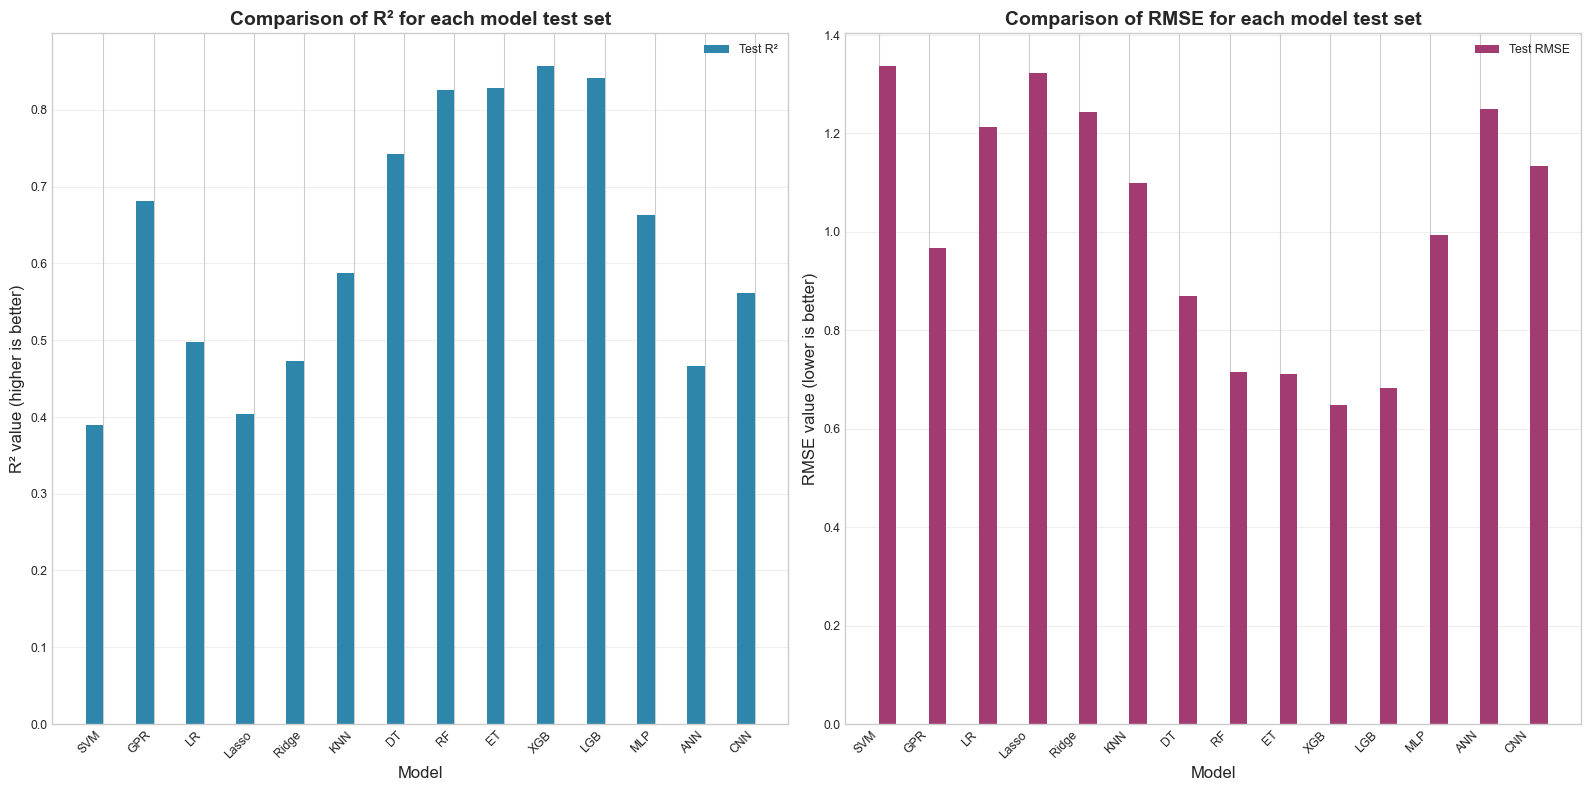

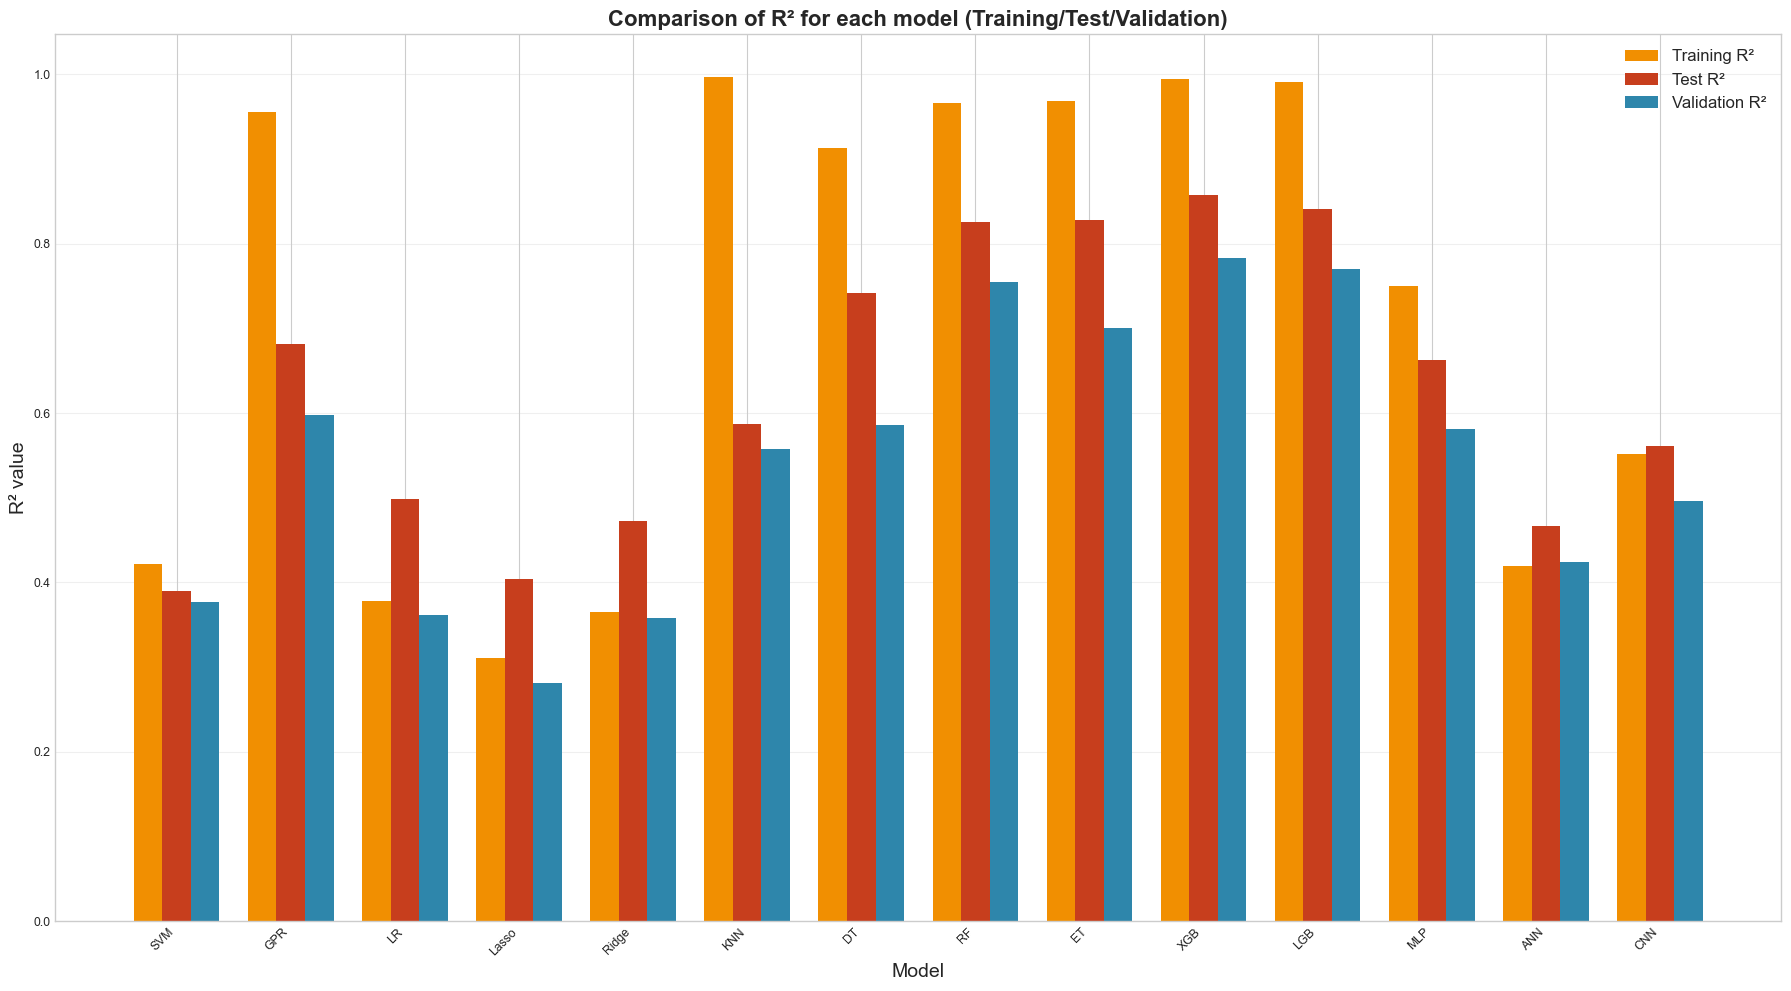

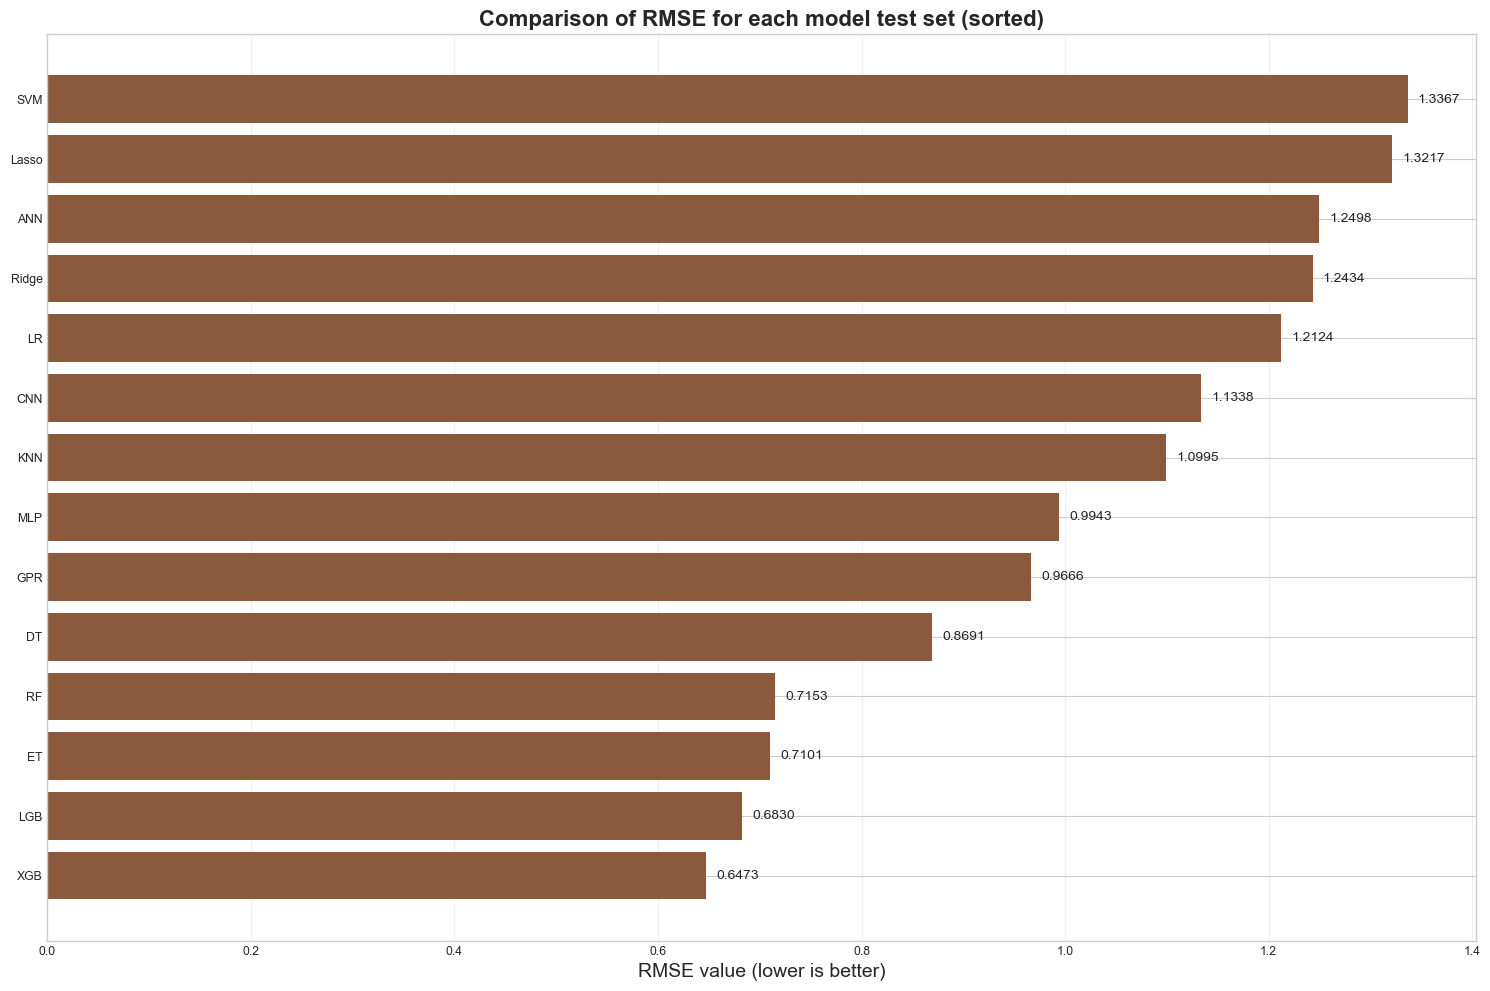

In [58]:
# Compare Test R² and Test RMSE 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
models = metrics_df.index
x = np.arange(len(models))
width = 0.35

# Test R²
ax1.bar(x - width/2, metrics_df['Test R²'], width, label='Test R²', color='#2E86AB')
ax1.set_title('Comparison of R² for each model test set', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('R² value (higher is better)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Test RMSE
ax2.bar(x + width/2, metrics_df['Test RMSE'], width, label='Test RMSE', color='#A23B72')
ax2.set_title('Comparison of RMSE for each model test set', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('RMSE value (lower is better)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Train/Test/Validation R² for each model
fig, ax = plt.subplots(figsize=(18, 10))
x = np.arange(len(models))
width = 0.25

ax.bar(x - width, metrics_df['Train R²'], width, label='Training R²', color='#F18F01')
ax.bar(x, metrics_df['Test R²'], width, label='Test R²', color='#C73E1D')
ax.bar(x + width, metrics_df['Val R²'], width, label='Validation R²', color='#2E86AB')

ax.set_title('Comparison of R² for each model (Training/Test/Validation)', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('R² value', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Train/Test/Validation RMSE for each model
fig, ax = plt.subplots(figsize=(15, 10))
sorted_rmse = metrics_df['Test RMSE'].sort_values() 
models_sorted = sorted_rmse.index
rmse_values = sorted_rmse.values

ax.barh(models_sorted, rmse_values, color='#8B5A3C')
ax.set_title('Comparison of RMSE for each model test set (sorted)', fontsize=16, fontweight='bold') 
ax.set_xlabel('RMSE value (lower is better)', fontsize=14)  
ax.grid(axis='x', alpha=0.3)

# Annotate each bar with its RMSE value (rounded to 4 decimal places for consistency)
for i, v in enumerate(rmse_values):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

ES-SVM, BO-SVM, ICA-SVM

In [59]:
print("ES-Optimized SVM")
# Train SVM model with given hyperparameters (GA-optimized)
def SVM_model(C, gamma, epsilon, x_train, y_train):
    C = float(C) 
    gamma = float(gamma)  
    epsilon = float(epsilon)
    model = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
    model.fit(x_train, y_train)
    return model

# Genetic Algorithm optimization for SVM hyperparameters (Evolution Strategy)
def ES_SVM(x_train, x_val, y_train, y_val, epochs=30):  
    # Compute initial gamma estimate based on feature variance
    if isinstance(x_train, pd.DataFrame):
        var_scalar = x_train.var().mean()  
    else:
        var_scalar = np.var(x_train)  
    # Initial gamma heuristic: 1 / (n_features * average_variance)
    gamm = 1 / (22 * var_scalar)  
    
    # Objective function for optimization
    # Evaluate SVM performance via 5-fold cross-validated R² score
    def svm_score_cv(C, gamma, epsilon):
        C = float(C)
        gamma = float(gamma)
        epsilon = float(epsilon)
        cv_scores = cross_val_score(
            SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon),
            X=x_train, y=y_train, 
            cv=5, 
            scoring='r2', 
            n_jobs=-1
        )
        return cv_scores.mean()
    
    # Define pure scalar search bounds and initialize ES optimizer
    p = ES(
        svm_score_cv, 
        param_len=3, 
        size=15,                          # Population size
        x_min=[0.1, float(gamm), 0.005],  # Ensure that float(gamm) is a pure scalar.
        x_max=[20.0, 1.0, 0.2],   
        alpha=0.1)

    C_opt, gamma_opt, epsilon_opt = p.solve(epoch=epochs, verbose=False)
    C_opt = float(C_opt)
    gamma_opt = float(gamma_opt)
    epsilon_opt = float(epsilon_opt)
    print(f'BEST ES-SVM hyperparameters: C={C_opt:.2f}, gamma={gamma_opt:.4f}, epsilon={epsilon_opt:.3f}')
    
    ES_SVM_model = SVM_model(C_opt, gamma_opt, epsilon_opt, x_train, y_train)
    return ES_SVM_model

es_svm = ES_SVM(x_train, x_val, y_train, y_val)
evaluate_model(es_svm, x_train, y_train, x_test, y_test, x_val, y_val, "ES-SVM")

ES-Optimized SVM
BEST ES-SVM hyperparameters: C=7.99, gamma=1.0000, epsilon=0.200
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9066
Train RMSE: 0.5128
Test R²: 0.6679
Test RMSE: 0.9862
Val R²: 0.5735
Val RMSE: 1.0078


In [60]:
print("Bayesian-Optimized SVM")
def SVM_model_bayes(C, gamma, epsilon, x_train, y_train):
    model = SVR(kernel='rbf',
                C=C,
                gamma=gamma,
                epsilon=epsilon)
    model.fit(x_train, y_train)
    return model  

# Bayesian optimization of SVM hyperparameters
def Bayes_SVM(x_train, x_val, y_train, y_val, n_calls=25):  # n_calls Corresponding to the original n_iter=25
    param_space = [
        Real(0.1, 10.0, name='C'),       
        Real(0.001, 1.0, name='gamma'), 
        Real(0.01, 0.2, name='epsilon')    
    ]

    # Define the objective function (maximize R2 → minimize negative R2)
    @use_named_args(param_space) 
    def objective_func(**params):
        cv_scores = cross_val_score(
            SVR(kernel='rbf',** params), 
            X=x_train, y=y_train, 
            cv=5, 
            scoring='r2', 
            n_jobs=-1
        )
        return -cv_scores.mean()

    result = gp_minimize(
        func=objective_func,       # Function to minimize
        dimensions=param_space,    # Hyperparameter search space
        n_calls=n_calls,           # Total number of evaluations
        random_state=1,              
        verbose=False                
    )
    
   # Extract best hyperparameters found
    C_opt, gamma_opt, epsilon_opt = result.x

    print(f'BEST Bayes-SVM hyperparameters: C={C_opt:.2f}, gamma={gamma_opt:.4f}, epsilon={epsilon_opt:.3f}')

    Bayes_SVM_model = SVM_model_bayes(C_opt, gamma_opt, epsilon_opt, x_train, y_train)
    return Bayes_SVM_model

bayes_svm = Bayes_SVM(x_train, x_val, y_train, y_val, n_calls=25)
evaluate_model(bayes_svm, x_train, y_train, x_test, y_test, x_val, y_val, "Bayes-SVM")

Bayesian-Optimized SVM
BEST Bayes-SVM hyperparameters: C=8.20, gamma=1.0000, epsilon=0.200
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9076
Train RMSE: 0.5101
Test R²: 0.6686
Test RMSE: 0.9852
Val R²: 0.5735
Val RMSE: 1.0079


In [61]:
print("ICA-Optimized SVM")
def SVM_model_ica(C, gamma, epsilon, x_train, y_train):
    model = SVR(kernel='rbf',
                C=C,
                gamma=gamma,
                epsilon=epsilon)
    model.fit(x_train, y_train)
    return model  

# ICA optimization of SVM hyperparameters
def ICA_SVM(x_train, x_val, y_train, y_val, epochs=30, pop_size=15):
    param_dist = {
        'C': np.arange(0.1, 10.1, 0.5), 
        'gamma': np.arange(0.001, 1.01, 0.01), 
        'epsilon': np.arange(0.01, 0.21, 0.01)  
    }
    
    rs = RandomizedSearchCV(
        estimator=SVR(kernel='rbf'),  
        param_distributions=param_dist,
        n_iter=epochs, 
        cv=5,          
        scoring='r2', 
        n_jobs=-1,     
        random_state=1,
        verbose=0
    )
    
    rs.fit(x_train, y_train)
    best = rs.best_params_

    print(f'BEST ICA-SVM hyperparameters (fallback RandomizedSearchCV): C={best["C"]:.2f}, gamma={best["gamma"]:.4f}, epsilon={best["epsilon"]:.3f}')
    
    ICA_SVM_model = SVM_model_ica(best['C'], best['gamma'], best['epsilon'], x_train, y_train)
    return ICA_SVM_model

ica_svm = ICA_SVM(x_train, x_val, y_train, y_val, epochs=30, pop_size=15)
evaluate_model(ica_svm, x_train, y_train, x_test, y_test, x_val, y_val, "ICA-SVM")

ICA-Optimized SVM
BEST ICA-SVM hyperparameters (fallback RandomizedSearchCV): C=8.60, gamma=0.7210, epsilon=0.190
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.8807
Train RMSE: 0.5796
Test R²: 0.6444
Test RMSE: 1.0205
Val R²: 0.5631
Val RMSE: 1.0201


ES-XGBoost, BO-XGBoost, ICA-XGBoost

In [62]:
print("ES-Optimized XGBoost")
def XGB_model(n_estimators, max_depth, learning_rate, subsample, x_train, y_train):
    model = XGBRegressor(random_state=1, n_jobs=-1,
                         n_estimators=int(round(n_estimators)),
                         max_depth=int(round(max_depth)),
                         learning_rate=learning_rate,
                         subsample=subsample)
    model.fit(x_train, y_train)
    return model

def ES_XGB(x_train, x_val, y_train, y_val, epochs=50, cv=5): 
    # Objective function: maximize R² via cross-validation (ES maximizes by default)
    def xgb_score_cv(n_estimators, max_depth, learning_rate, subsample):
        n_estimators = int(round(n_estimators))
        max_depth = int(round(max_depth))

        cv_scores = cross_val_score(
            XGBRegressor(random_state=1, 
                         n_jobs=-1,
                         n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         subsample=subsample),
            X=x_train, y=y_train, cv=cv, scoring='r2', n_jobs=-1
        )
        return cv_scores.mean() 
    
    # Initialize Evolution Strategy (ES) optimizer
    p = ES(xgb_score_cv, 
           param_len=4, 
           size=20, 
           x_min=[50, 3, 0.01, 0.8],
           x_max=[200, 7, 0.1, 1.0],
           alpha=0.05) 

    n_estimators_opt, max_depth_opt, learning_rate_opt, subsample_opt = p.solve(epoch=epochs, verbose=False)
    n_estimators_opt = int(round(n_estimators_opt))
    max_depth_opt = int(round(max_depth_opt))
    print(f'BEST ES-XGB hyperparameters: n_estimators={n_estimators_opt}, max_depth={max_depth_opt}, learning_rate={learning_rate_opt:.4f}, subsample={subsample_opt:.2f}')

    ES_XGB_model = XGB_model(n_estimators_opt, max_depth_opt, learning_rate_opt, subsample_opt, x_train, y_train)
    return ES_XGB_model

es_xgb = ES_XGB(x_train, x_val, y_train, y_val, epochs=50)
evaluate_model(es_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "ES-XGB")

ES-Optimized XGBoost
BEST ES-XGB hyperparameters: n_estimators=139, max_depth=5, learning_rate=0.1000, subsample=0.92
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9918
Train RMSE: 0.1520
Test R²: 0.8583
Test RMSE: 0.6442
Val R²: 0.7746
Val RMSE: 0.7326


In [63]:
print("Bayesian-Optimized XGBoost")
def XGB_model_bayes(n_estimators, max_depth, learning_rate, subsample, x_train, y_train):
    model = XGBRegressor(random_state=1, 
                         n_jobs=-1,
                         n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         subsample=subsample)
    model.fit(x_train, y_train)
    return model

def Bayes_XGB(x_train, x_val, y_train, y_val, n_calls=30):
    # Define the hyperparameter search space 
    param_space = [
        Integer(50, 200, name='n_estimators'),
        Integer(3, 7, name='max_depth'),
        Real(0.01, 0.1, name='learning_rate'),
        Real(0.8, 1.0, name='subsample')
    ]

    # Objective function for Bayesian optimization
    @use_named_args(param_space)
    def objective_func(**params):
        cv_scores = cross_val_score(
            XGBRegressor(random_state=1, n_jobs=-1,** params),
            X=x_train, y=y_train, 
            cv=5, 
            scoring='r2', 
            n_jobs=-1
        )
        return -cv_scores.mean()

    result = gp_minimize(
        func=objective_func,
        dimensions=param_space,
        n_calls=n_calls,
        random_state=1,
        verbose=False
    )

    n_estimators_opt, max_depth_opt, learning_rate_opt, subsample_opt = result.x
    print(f'BEST Bayes-XGB hyperparameters: n_estimators={n_estimators_opt}, max_depth={max_depth_opt}, learning_rate={learning_rate_opt:.4f}, subsample={subsample_opt:.2f}')

    Bayes_XGB_model = XGB_model_bayes(
        n_estimators_opt, max_depth_opt, learning_rate_opt, subsample_opt,
        x_train, y_train
    )
    return Bayes_XGB_model

bayes_xgb = Bayes_XGB(x_train, x_val, y_train, y_val, n_calls=30)
evaluate_model(bayes_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "Bayes-XGB")

Bayesian-Optimized XGBoost
BEST Bayes-XGB hyperparameters: n_estimators=200, max_depth=4, learning_rate=0.1000, subsample=0.84
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9888
Train RMSE: 0.1772
Test R²: 0.8269
Test RMSE: 0.7120
Val R²: 0.7665
Val RMSE: 0.7456


In [64]:
print("ICA-Optimized XGBoost")
def ICA_XGB(x_train, x_val, y_train, y_val, epochs=30, pop_size=15):
    param_dist = {
        'n_estimators': np.arange(50, 201, 10),
        'max_depth': np.arange(3, 8, 1),
        'learning_rate': np.arange(0.01, 0.11, 0.01), 
        'subsample': np.arange(0.8, 1.01, 0.05)  
    }

    rs = RandomizedSearchCV(
        estimator=XGBRegressor(random_state=1, n_jobs=-1),
        param_distributions=param_dist,
        n_iter=epochs, 
        cv=5,
        scoring='r2',
        n_jobs=-1,
        random_state=1,
        verbose=0
    )
    rs.fit(x_train, y_train)
    best = rs.best_params_
    
    print(f'BEST ICA-XGB hyperparameters (fallback RandomizedSearchCV): n_estimators={best["n_estimators"]}, max_depth={best["max_depth"]}, learning_rate={best["learning_rate"]:.4f}, subsample={best["subsample"]:.2f}')
    ICA_XGB_model = rs.best_estimator_
    return ICA_XGB_model

ica_xgb = ICA_XGB(x_train, x_val, y_train, y_val, epochs=30, pop_size=15)
evaluate_model(ica_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "ICA-XGB")

ICA-Optimized XGBoost
BEST ICA-XGB hyperparameters (fallback RandomizedSearchCV): n_estimators=90, max_depth=6, learning_rate=0.0900, subsample=0.90
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9905
Train RMSE: 0.1637
Test R²: 0.8515
Test RMSE: 0.6595
Val R²: 0.7574
Val RMSE: 0.7601


In [65]:
# XGBoost
print("XGBoost")
xgb_param_grid = {
    'n_estimators': [50, 100, 200], # Number of boosting rounds (trees)
    'max_depth': [3, 5, 7],         # Maximum depth of each tree (controls model complexity)
    'learning_rate': [0.01, 0.1],   # Step size shrinkage to prevent overfitting
    'subsample': [0.8, 1.0]         # Fraction of training samples used for fitting each tree
}

xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=1, n_jobs=-1),
    param_distributions=xgb_param_grid,  
    n_iter=20,  
    cv=5,  
    scoring='r2', 
    n_jobs=-1, 
    random_state=1  
)

xgb_random.fit(x_train, y_train)
print(f"Best XGBoost parameters: {xgb_random.best_params_}")
XGB_model = xgb_random.best_estimator_

evaluate_model(XGB_model, x_train, y_train, x_test, y_test, x_val, y_val, "XGB")

XGBoost
Best XGBoost parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9947
Train RMSE: 0.1218
Test R²: 0.8569
Test RMSE: 0.6473
Val R²: 0.7828
Val RMSE: 0.7191


In [66]:
# Optimized Models Evaluation Metrics
selected_models_metrics2 = []  

selected_models_metrics2.append(get_model_metrics(es_svm, x_train, y_train, x_test, y_test, x_val, y_val, "ES-SVM"))
selected_models_metrics2.append(get_model_metrics(bayes_svm, x_train, y_train, x_test, y_test, x_val, y_val, "Bayes-SVM"))
selected_models_metrics2.append(get_model_metrics(ica_svm, x_train, y_train, x_test, y_test, x_val, y_val, "ICA-SVM"))
selected_models_metrics2.append(get_model_metrics(es_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "ES-XGB"))
selected_models_metrics2.append(get_model_metrics(bayes_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "Bayes-XGB"))
selected_models_metrics2.append(get_model_metrics(ica_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "ICA-XGB"))

metrics_df2 = pd.DataFrame(selected_models_metrics2).set_index('Model Name')
metrics_df2 = metrics_df2.round(4)

print("Optimized Model Evaluation Metrics")
print(metrics_df2)

  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9066
Train RMSE: 0.5128
Test R²: 0.6679
Test RMSE: 0.9862
Val R²: 0.5735
Val RMSE: 1.0078
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9076
Train RMSE: 0.5101
Test R²: 0.6686
Test RMSE: 0.9852
Val R²: 0.5735
Val RMSE: 1.0079
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.8807
Train RMSE: 0.5796
Test R²: 0.6444
Test RMSE: 1.0205
Val R²: 0.5631
Val RMSE: 1.0201
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9918
Train RMSE: 0.1520
Test R²: 0.8583
Test RMSE: 0.6442
Val R²: 0.7746
Val RMSE: 0.7326
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9888
Train RMSE: 0.1772
Test R²: 0.8269
Test RMSE: 0.7120
Val R²: 0.7665
Val RMSE: 0.7456
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9905
Train RMSE: 0.1637
Test R²: 0.8515
Test RMSE: 0.6595
Val R²: 0.7574
Val RMSE: 0.7601
Optimized Model Evaluation Metrics
            Train R²  Train R

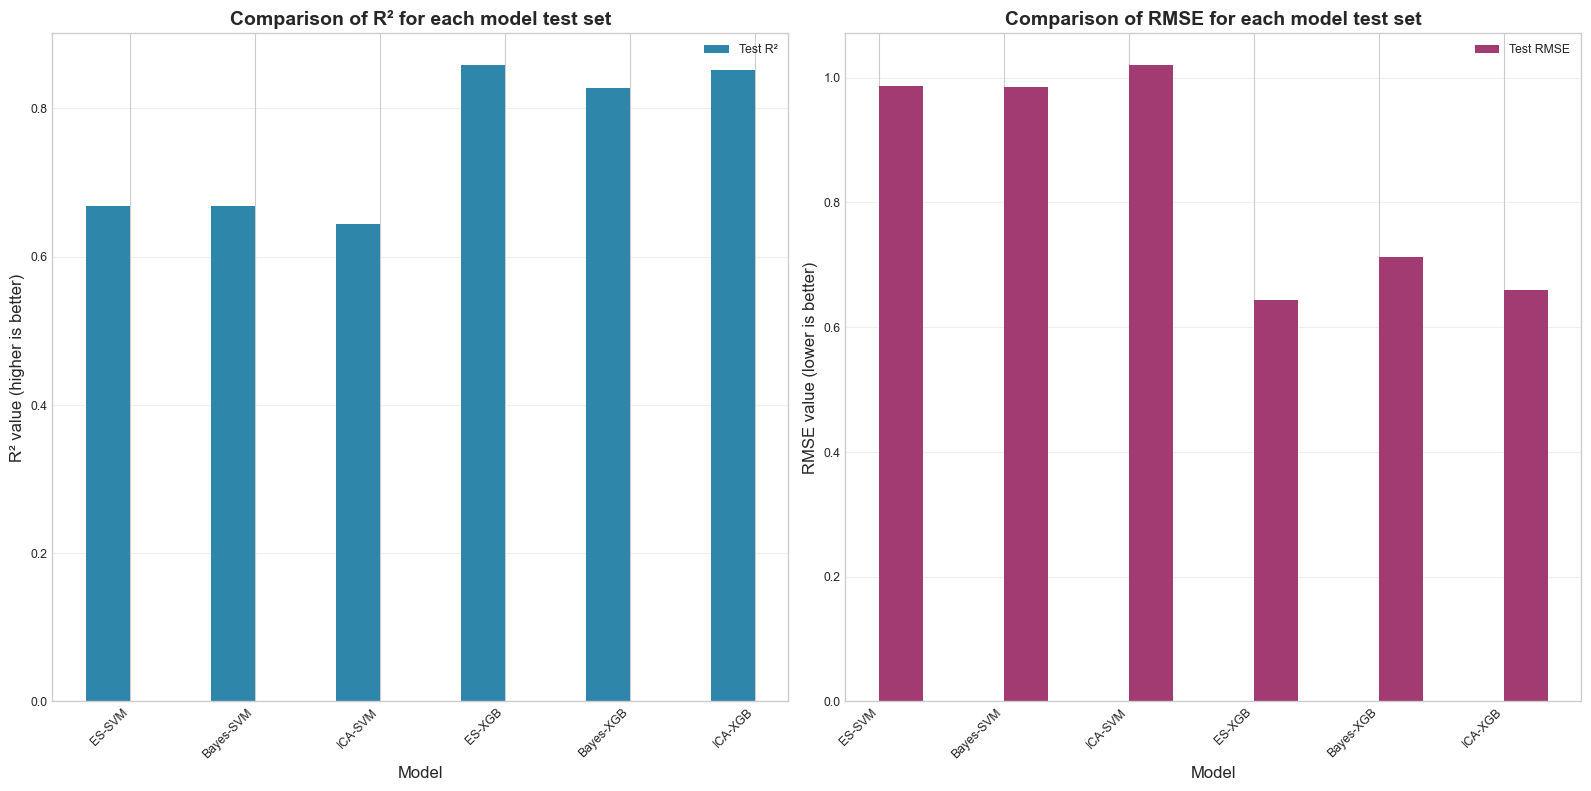

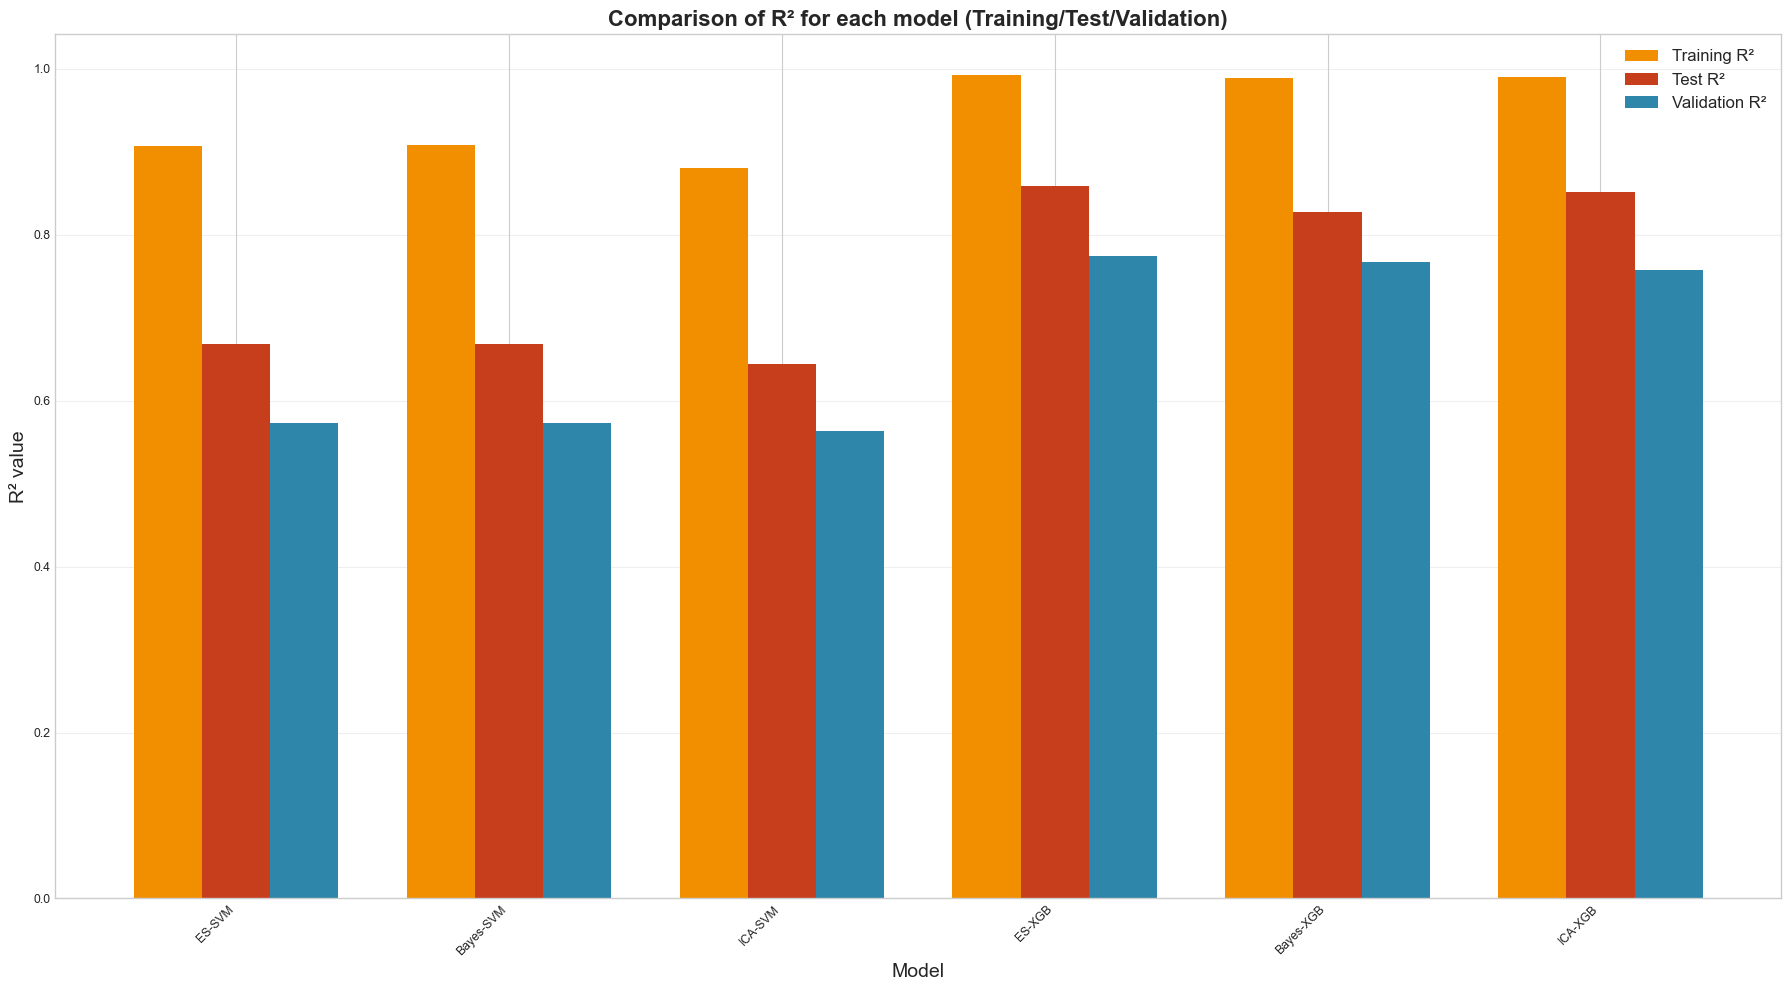

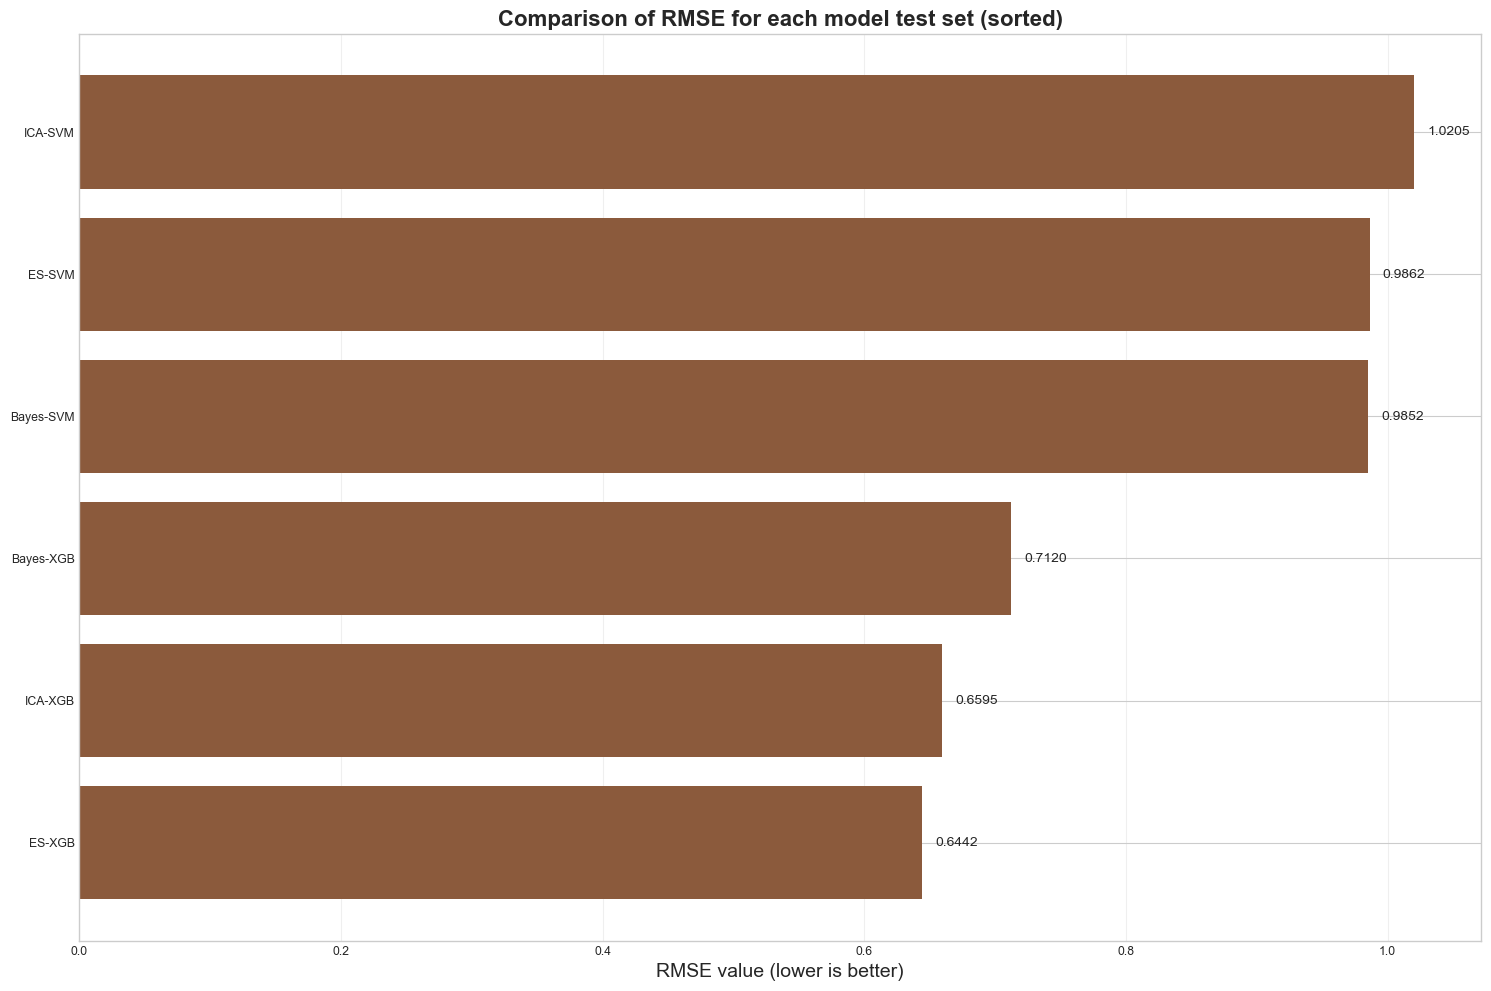

In [67]:
# Compare Test R² and Test RMSE 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
models2 = metrics_df2.index
x = np.arange(len(models2))
width = 0.35

# Test R²
ax1.bar(x - width/2, metrics_df2['Test R²'], width, label='Test R²', color='#2E86AB')
ax1.set_title('Comparison of R² for each model test set', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('R² value (higher is better)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models2, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Test RMSE
ax2.bar(x + width/2, metrics_df2['Test RMSE'], width, label='Test RMSE', color='#A23B72')
ax2.set_title('Comparison of RMSE for each model test set', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('RMSE value (lower is better)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models2, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Train/Test/Validation R² for each model
fig, ax = plt.subplots(figsize=(18, 10))
x = np.arange(len(models2))
width = 0.25

ax.bar(x - width, metrics_df2['Train R²'], width, label='Training R²', color='#F18F01')
ax.bar(x, metrics_df2['Test R²'], width, label='Test R²', color='#C73E1D')
ax.bar(x + width, metrics_df2['Val R²'], width, label='Validation R²', color='#2E86AB')

ax.set_title('Comparison of R² for each model (Training/Test/Validation)', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('R² value', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models2, rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Train/Test/Validation RMSE for each model
fig, ax = plt.subplots(figsize=(15, 10))
sorted_rmse2 = metrics_df2['Test RMSE'].sort_values() 
models_sorted2 = sorted_rmse2.index
rmse_values2 = sorted_rmse2.values

ax.barh(models_sorted2, rmse_values2, color='#8B5A3C')
ax.set_title('Comparison of RMSE for each model test set (sorted)', fontsize=16, fontweight='bold')  
ax.set_xlabel('RMSE value (lower is better)', fontsize=14)  
ax.grid(axis='x', alpha=0.3)

# Annotate each bar with its RMSE value (rounded to 4 decimal places for consistency)
for i, v in enumerate(rmse_values2):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Four XGBoost Models Evaluation Metrics

In [68]:
# Four XGBoost Models Evaluation Metrics
selected_models_metrics3 = [] 

selected_models_metrics3.append(get_model_metrics(XGB_model, x_train, y_train, x_test, y_test, x_val, y_val, "XGB")) # Need to re-run XGBoost model
selected_models_metrics3.append(get_model_metrics(es_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "ES-XGB"))
selected_models_metrics3.append(get_model_metrics(bayes_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "Bayes-XGB"))
selected_models_metrics3.append(get_model_metrics(ica_xgb, x_train, y_train, x_test, y_test, x_val, y_val, "ICA-XGB"))

metrics_df3 = pd.DataFrame(selected_models_metrics3).set_index('Model Name')
metrics_df3 = metrics_df3.round(4)

print("Four XGBoost Model Evaluation Metrics")
print(metrics_df3)

  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9947
Train RMSE: 0.1218
Test R²: 0.8569
Test RMSE: 0.6473
Val R²: 0.7828
Val RMSE: 0.7191
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9918
Train RMSE: 0.1520
Test R²: 0.8583
Test RMSE: 0.6442
Val R²: 0.7746
Val RMSE: 0.7326
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9888
Train RMSE: 0.1772
Test R²: 0.8269
Test RMSE: 0.7120
Val R²: 0.7665
Val RMSE: 0.7456
  x_train: (345, 9), x_test: (103, 9), x_val: (64, 9)
Train R²: 0.9905
Train RMSE: 0.1637
Test R²: 0.8515
Test RMSE: 0.6595
Val R²: 0.7574
Val RMSE: 0.7601
Four XGBoost Model Evaluation Metrics
            Train R²  Train RMSE  Test R²  Test RMSE  Val R²  Val RMSE
Model Name                                                            
XGB           0.9947      0.1218   0.8569     0.6473  0.7828    0.7191
ES-XGB        0.9918      0.1520   0.8583     0.6442  0.7746    0.7326
Bayes-XGB     0.9888      0.1772   0.8269     0.7120  

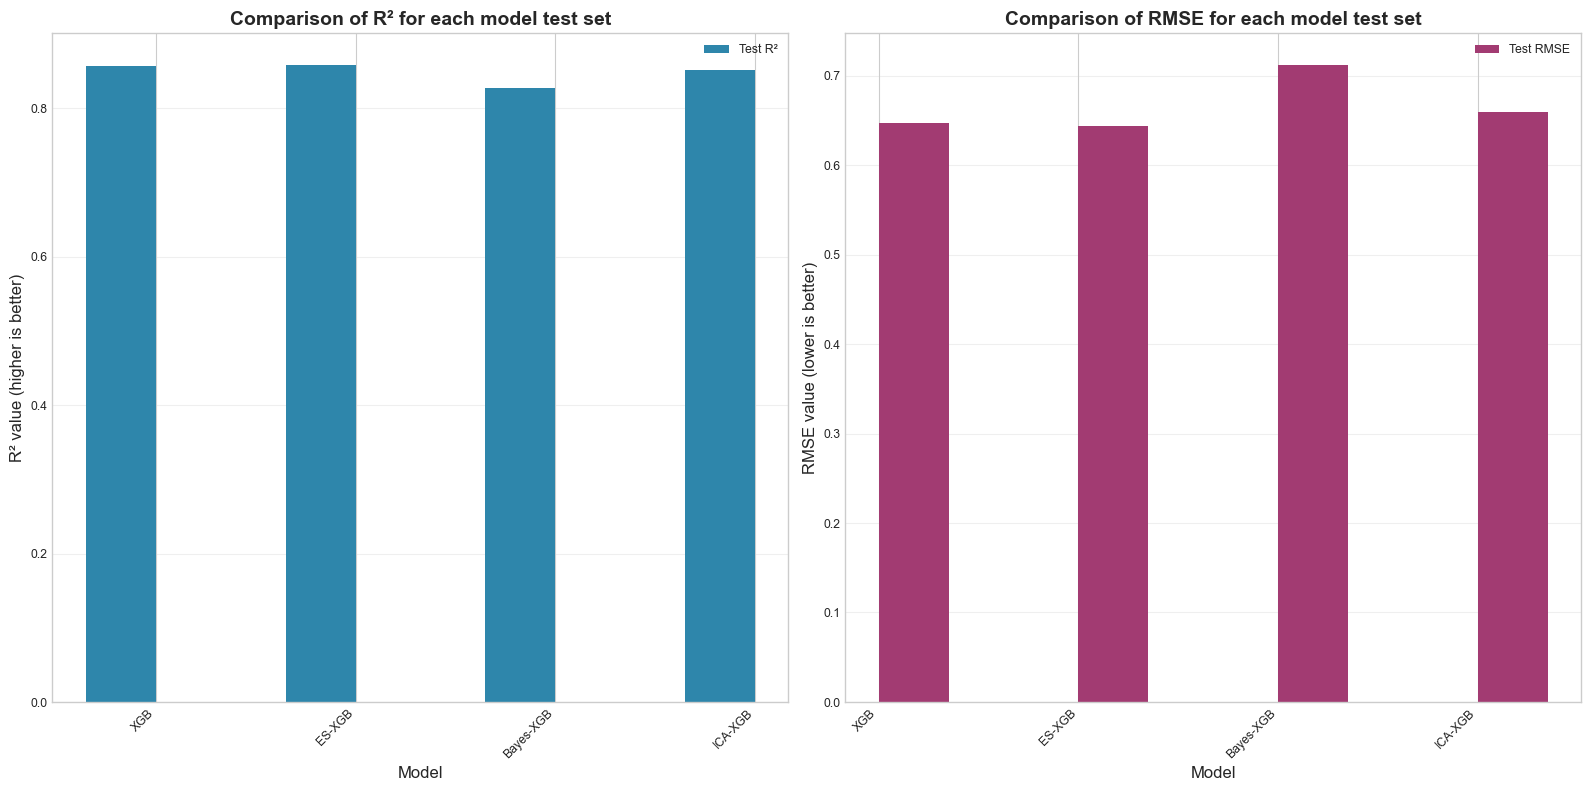

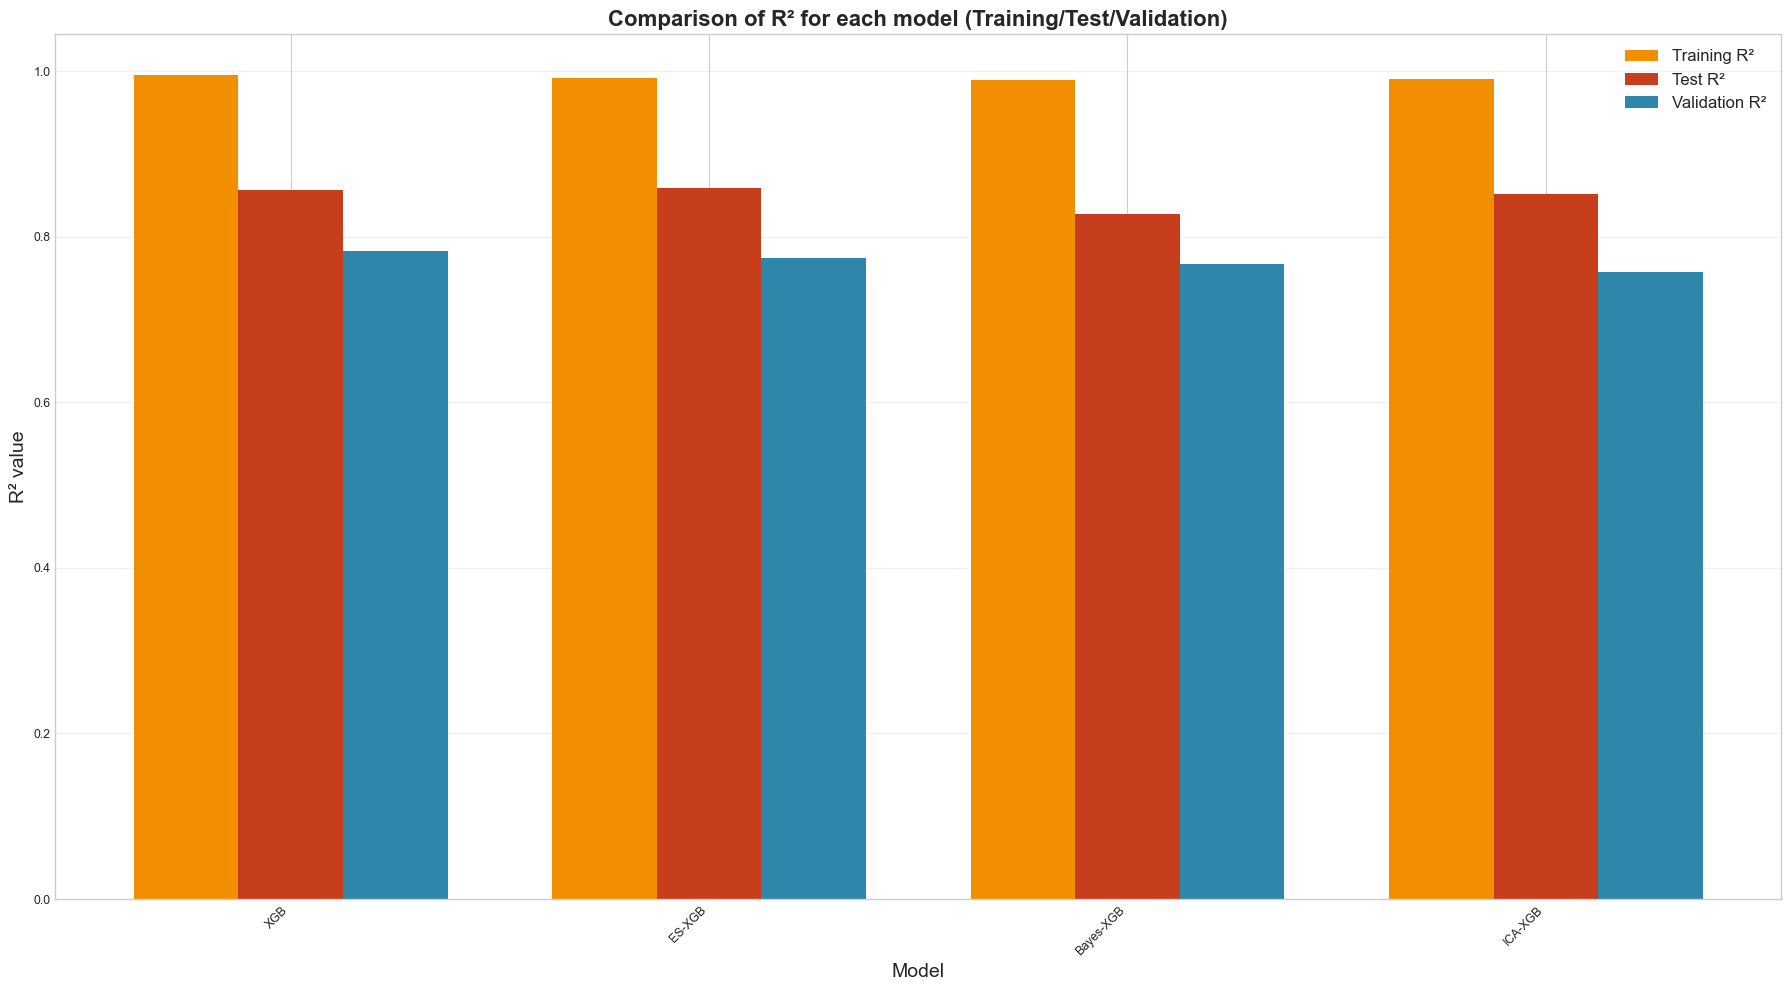

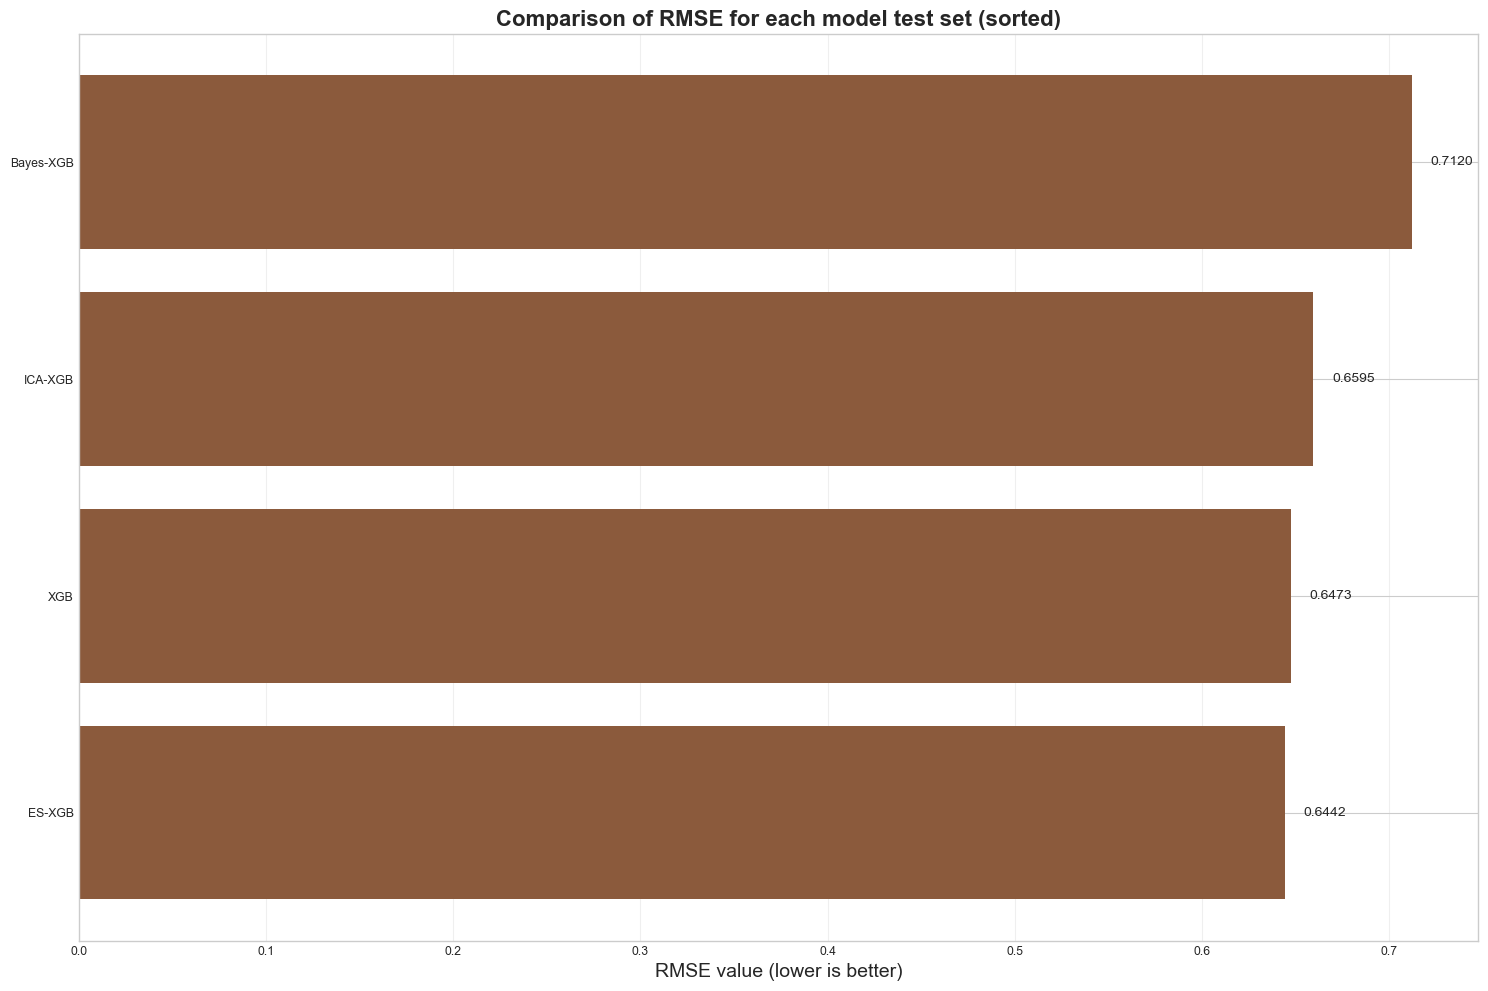

In [69]:
# Compare Test R² and Test RMSE 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
models3 = metrics_df3.index
x = np.arange(len(models3))
width = 0.35

# Test R²
ax1.bar(x - width/2, metrics_df3['Test R²'], width, label='Test R²', color='#2E86AB')
ax1.set_title('Comparison of R² for each model test set', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('R² value (higher is better)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models3, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Test RMSE
ax2.bar(x + width/2, metrics_df3['Test RMSE'], width, label='Test RMSE', color='#A23B72')
ax2.set_title('Comparison of RMSE for each model test set', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('RMSE value (lower is better)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models3, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Train/Test/Validation R² for each model
fig, ax = plt.subplots(figsize=(18, 10))
x = np.arange(len(models3))
width = 0.25

ax.bar(x - width, metrics_df3['Train R²'], width, label='Training R²', color='#F18F01')
ax.bar(x, metrics_df3['Test R²'], width, label='Test R²', color='#C73E1D')
ax.bar(x + width, metrics_df3['Val R²'], width, label='Validation R²', color='#2E86AB')

ax.set_title('Comparison of R² for each model (Training/Test/Validation)', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('R² value', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models3, rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Train/Test/Validation RMSE for each model
fig, ax = plt.subplots(figsize=(15, 10))
sorted_rmse3 = metrics_df3['Test RMSE'].sort_values()
models_sorted3 = sorted_rmse3.index
rmse_values3 = sorted_rmse3.values

ax.barh(models_sorted3, rmse_values3, color='#8B5A3C')
ax.set_title('Comparison of RMSE for each model test set (sorted)', fontsize=16, fontweight='bold') 
ax.set_xlabel('RMSE value (lower is better)', fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Annotate each bar with its RMSE value (rounded to 4 decimal places for consistency)
for i, v in enumerate(rmse_values3):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Gaussian Noise Robustness Test

In [75]:
features_to_remove = ['A', 'B', 'S']
feature_names = ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V']

models_to_test = {
    'XGB': XGB_model,
    'ES-XGB': es_xgb,
    'ICA-XGB': ica_xgb,
    'Bayes-XGB': bayes_xgb
}


# Calculating Baseline R² (Original Data without Noise)
baseline_models = {}
for model_name, model in models_to_test.items():
    baseline_model = clone(model)
    baseline_model.fit(x_train, y_train)
    baseline_r2_test = r2_score(y_test, baseline_model.predict(x_test))
    baseline_r2_val = r2_score(y_val, baseline_model.predict(x_val))
    baseline_models[model_name] = {
        'model': baseline_model,
        'test_r2': baseline_r2_test,
        'val_r2': baseline_r2_val
    }
    print(f"{model_name} Baseline Test R²: {baseline_r2_test:.4f}")
    print(f"{model_name} Baseline Val R²: {baseline_r2_val:.4f}")

XGB Baseline Test R²: 0.8569
XGB Baseline Val R²: 0.7828
ES-XGB Baseline Test R²: 0.8583
ES-XGB Baseline Val R²: 0.7746
ICA-XGB Baseline Test R²: 0.8515
ICA-XGB Baseline Val R²: 0.7574
Bayes-XGB Baseline Test R²: 0.8269
Bayes-XGB Baseline Val R²: 0.7665


In [76]:
# Define a function to evaluate model robustness across different data splits
def evaluate_model_robustness(model, x_train, y_train, x_test, y_test, x_val, y_val, model_name):
    def ensure_2d(data):
        if isinstance(data, pd.Series):
            return data.to_frame()
        elif isinstance(data, np.ndarray):
            if len(data.shape) == 1:
                return data.reshape(-1, 1)
            return data
        return data
    
    x_train_2d = ensure_2d(x_train)
    x_test_2d = ensure_2d(x_test)
    x_val_2d = ensure_2d(x_val)
    
    y_train_pred = model.predict(x_train_2d).ravel()  
    y_test_pred = model.predict(x_test_2d).ravel()  
    y_val_pred = model.predict(x_val_2d).ravel()   
    
    metrics = {
        "Model": model_name,
        "Train_R2": float(r2_score(y_train, y_train_pred)),
        "Train_RMSE": float(np.sqrt(mean_squared_error(y_train, y_train_pred))),
        "Test_R2": float(r2_score(y_test, y_test_pred)),
        "Test_RMSE": float(np.sqrt(mean_squared_error(y_test, y_test_pred))),
        "Val_R2": float(r2_score(y_val, y_val_pred)),
        "Val_RMSE": float(np.sqrt(mean_squared_error(y_val, y_val_pred))),
    }
    
    return metrics

In [77]:
# Define noise levels to test (as a percentage of the standard deviation of the data)
noise_levels = [0.10, 0.20, 0.30, 0.40, 0.50]  # 10%, 20%, 30%, 40%, 50%
robustness_results = []

models = {
    'XGB': XGB_model,
    'ES-XGB': es_xgb,
    'ICA-XGB': ica_xgb,
    'Bayes-XGB': bayes_xgb
}

print(f"\nTesting {len(models)} models × {len(noise_levels)} noise levels = {len(models)*len(noise_levels)} experiments")

for noise_level in noise_levels:
    print(f"\n{'='*60}")
    print(f"Adding Gaussian Noise: η = {noise_level*100:.0f}%")
    print(f"{'='*60}")
    
    # Calculate noise standard deviation based on the training data's standard deviation
    data_std = np.std(x_train, axis=0)
    noise_std = data_std * noise_level
    
    for model_name, model in models.items():
        print(f"\n  Training {model_name} with noise")
        
        # Add Gaussian noise to the training data
        # np.random.seed(1)  # For reproducibility
        for seed in range(5):
            np.random.seed(seed)
        x_train_noisy = x_train + np.random.normal(0, noise_std, x_train.shape)
        
        # Clone the original model to ensure we start with the same parameters for each noise level
        model_noisy = clone(model)
        model_noisy.fit(x_train_noisy, y_train)
        
        # Evaluate the model's performance on the original test and validation sets
        results = evaluate_model_robustness(
            model_noisy, x_train_noisy, y_train, 
            x_test, y_test, x_val, y_val, 
            f"{model_name}"
        )
        results['Noise_Level'] = f"{noise_level*100:.0f}%"
        
        robustness_results.append(results)
        
        print(f"    Train R² = {results['Train_R2']:.4f}")
        print(f"    Test R² = {results['Test_R2']:.4f}")
        print(f"    Valid R² = {results['Val_R2']:.4f}")
        print(f"    Test RMSE = {results['Test_RMSE']:.4f}")



Testing 4 models × 5 noise levels = 20 experiments

Adding Gaussian Noise: η = 10%

  Training XGB with noise
    Train R² = 0.9994
    Test R² = 0.6996
    Valid R² = 0.5743
    Test RMSE = 0.9380

  Training ES-XGB with noise
    Train R² = 0.9964
    Test R² = 0.6613
    Valid R² = 0.5922
    Test RMSE = 0.9961

  Training ICA-XGB with noise
    Train R² = 0.9955
    Test R² = 0.6930
    Valid R² = 0.6044
    Test RMSE = 0.9483

  Training Bayes-XGB with noise
    Train R² = 0.9944
    Test R² = 0.6670
    Valid R² = 0.5828
    Test RMSE = 0.9876

Adding Gaussian Noise: η = 20%

  Training XGB with noise
    Train R² = 0.9993
    Test R² = 0.5962
    Valid R² = 0.4872
    Test RMSE = 1.0875

  Training ES-XGB with noise
    Train R² = 0.9956
    Test R² = 0.6268
    Valid R² = 0.5314
    Test RMSE = 1.0454

  Training ICA-XGB with noise
    Train R² = 0.9941
    Test R² = 0.6010
    Valid R² = 0.4175
    Test RMSE = 1.0810

  Training Bayes-XGB with noise
    Train R² = 0.9930
    

In [78]:
robustness_df = pd.DataFrame(robustness_results)

print("\nRobustness Test Results (R²) Summary:")
for noise in [f'{i*10}%' for i in [1, 2, 3, 4, 5]]:
    print(f"\nη = {noise}:")
    noise_data = robustness_df[robustness_df['Noise_Level'] == noise]
    
    print(f"  {'Model':<12}{'Train R²':<12}{'Test R²':<12} {'Val R²':<12} {'Test RMSE':<12} ")
    print(f"  {'-'*60}")
    for _, row in noise_data.iterrows():
        print(f"  {row['Model']:<12} {row['Train_R2']:<12.4f} {row['Test_R2']:<12.4f} {row['Val_R2']:<12.4f} {row['Test_RMSE']:<12.4f} ")



Robustness Test Results (R²) Summary:

η = 10%:
  Model       Train R²    Test R²      Val R²       Test RMSE    
  ------------------------------------------------------------
  XGB          0.9994       0.6996       0.5743       0.9380       
  ES-XGB       0.9964       0.6613       0.5922       0.9961       
  ICA-XGB      0.9955       0.6930       0.6044       0.9483       
  Bayes-XGB    0.9944       0.6670       0.5828       0.9876       

η = 20%:
  Model       Train R²    Test R²      Val R²       Test RMSE    
  ------------------------------------------------------------
  XGB          0.9993       0.5962       0.4872       1.0875       
  ES-XGB       0.9956       0.6268       0.5314       1.0454       
  ICA-XGB      0.9941       0.6010       0.4175       1.0810       
  Bayes-XGB    0.9930       0.6240       0.4922       1.0494       

η = 30%:
  Model       Train R²    Test R²      Val R²       Test RMSE    
  ------------------------------------------------------------


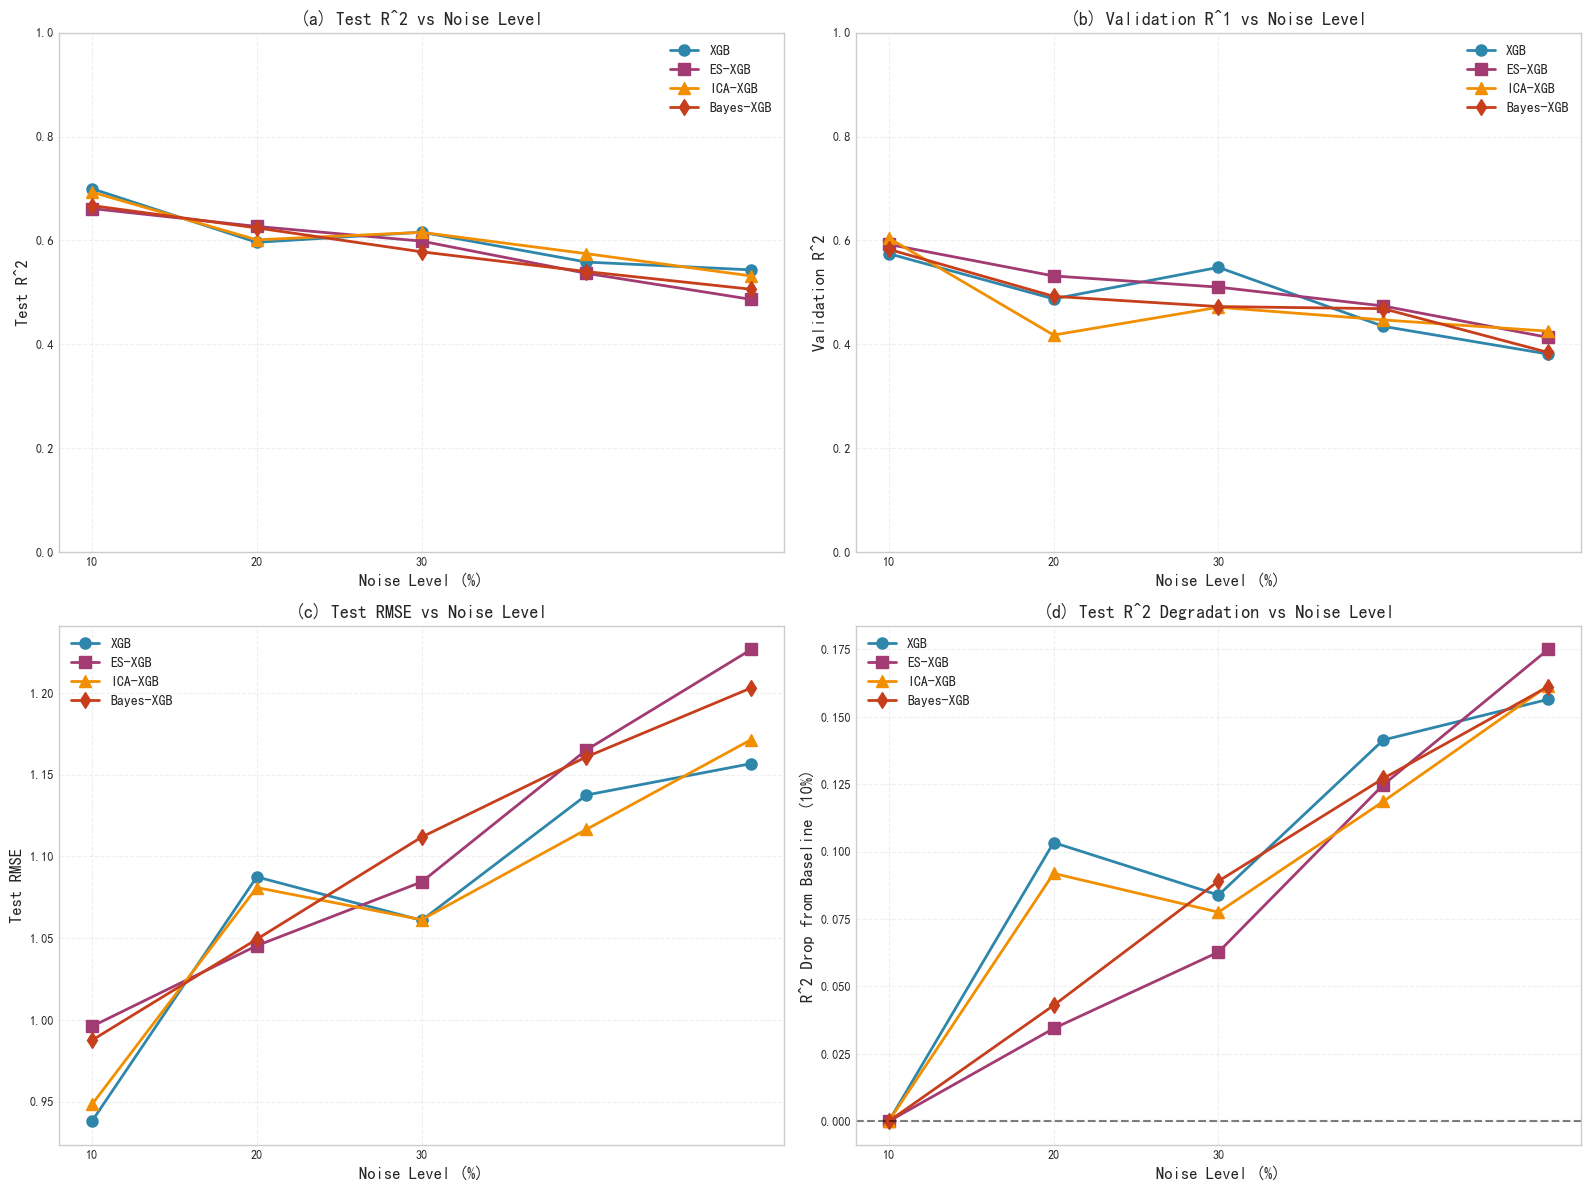

In [79]:
# Noise Robustness Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Test R² vs Noise Level
ax1 = axes[0, 0]
markers = {'XGB': 'o', 'ES-XGB': 's', 'ICA-XGB': '^', 'Bayes-XGB': 'd'}
colors = {'XGB': '#2E86AB', 'ES-XGB': '#A23B72', 'ICA-XGB': '#F18F01', 'Bayes-XGB': '#C73E1D'}

for model_name in models.keys():
    model_data = robustness_df[robustness_df['Model'] == model_name].sort_values('Noise_Level')
    noise_vals = [int(n.replace('%', '')) for n in model_data['Noise_Level'].values]
    ax1.plot(noise_vals, model_data['Test_R2'].values, 
            marker=markers[model_name], linewidth=2, label=model_name, 
            color=colors[model_name], markersize=8)

ax1.set_xlabel('Noise Level (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test R^2', fontsize=12, fontweight='bold')
ax1.set_title('(a) Test R^2 vs Noise Level', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks([10, 20, 30])
ax1.set_ylim([0, 1.0])

# (b) Validation R² vs Noise Level
ax2 = axes[0, 1]
for model_name in models.keys():
    model_data = robustness_df[robustness_df['Model'] == model_name].sort_values('Noise_Level')
    noise_vals = [int(n.replace('%', '')) for n in model_data['Noise_Level'].values]
    ax2.plot(noise_vals, model_data['Val_R2'].values, 
            marker=markers[model_name], linewidth=2, label=model_name,
            color=colors[model_name], markersize=8)

ax2.set_xlabel('Noise Level (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Validation R^2', fontsize=12, fontweight='bold')
ax2.set_title('(b) Validation R^1 vs Noise Level', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks([10, 20, 30])
ax2.set_ylim([0, 1.0])

# (c) Test RMSE vs Noise Level
ax3 = axes[1, 0]
for model_name in models.keys():
    model_data = robustness_df[robustness_df['Model'] == model_name].sort_values('Noise_Level')
    noise_vals = [int(n.replace('%', '')) for n in model_data['Noise_Level'].values]
    ax3.plot(noise_vals, model_data['Test_RMSE'].values, 
            marker=markers[model_name], linewidth=2, label=model_name,
            color=colors[model_name], markersize=8)

ax3.set_xlabel('Noise Level (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Test RMSE', fontsize=12, fontweight='bold')
ax3.set_title('(c) Test RMSE vs Noise Level', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xticks([10, 20, 30])

# (d) R² Drop vs Noise Level (relative to 10% noise baseline)
ax4 = axes[1, 1]
for model_name in models.keys():
    model_data = robustness_df[robustness_df['Model'] == model_name].sort_values('Noise_Level')
    baseline_r2 = model_data.iloc[0]['Test_R2']  # 10% noise level as baseline
    noise_vals = [int(n.replace('%', '')) for n in model_data['Noise_Level'].values]
    r2_drop = baseline_r2 - model_data['Test_R2'].values
    ax4.plot(noise_vals, r2_drop, 
            marker=markers[model_name], linewidth=2, label=model_name,
            color=colors[model_name], markersize=8)

ax4.set_xlabel('Noise Level (%)', fontsize=12, fontweight='bold')
ax4.set_ylabel('R^2 Drop from Baseline (10%)', fontsize=12, fontweight='bold')
ax4.set_title('(d) Test R^2 Degradation vs Noise Level', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xticks([10, 20, 30])
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)

plt.tight_layout()
plt.show()

FEATURE REMOVAL ROBUSTNESS TEST 

In [81]:
# Feature Removal Robustness TEST
feature_removal_results = []

for feature_to_remove in features_to_remove:
    print(f"Removing Feature: '{feature_to_remove}'")
    
    features_to_keep = [f for f in feature_names if f != feature_to_remove]
    feature_indices = [feature_names.index(f) for f in features_to_keep]
    
    print(f"  Remaining features ({len(features_to_keep)}): {features_to_keep}")
    
    if hasattr(x_train, 'iloc'):
        x_train_reduced = x_train.iloc[:, feature_indices].values
        x_test_reduced = x_test.iloc[:, feature_indices].values
        x_val_reduced = x_val.iloc[:, feature_indices].values
    else:
        x_train_reduced = x_train[:, feature_indices]
        x_test_reduced = x_test[:, feature_indices]
        x_val_reduced = x_val[:, feature_indices]
    
    for model_name, model in models_to_test.items():
        print(f"\n  Training {model_name} without '{feature_to_remove}'...")
        
        model_reduced = clone(model)
        model_reduced.fit(x_train_reduced, y_train)
        
        results = evaluate_model_robustness(
            model_reduced, x_train_reduced, y_train,
            x_test_reduced, y_test, x_val_reduced, y_val,
            f"{model_name}"
        )
        results['Removed_Feature'] = feature_to_remove
        results['Remaining_Features'] = len(features_to_keep)
        
        feature_removal_results.append(results)

        baseline_r2 = baseline_models[model_name]['test_r2']
        r2_drop = baseline_r2 - results['Test_R2']
        print(f"    Test R² = {results['Test_R2']:.4f} (Original: {baseline_r2:.4f}, Drop: {r2_drop:.4f})")
        print(f"    Validation R² = {results['Val_R2']:.4f}")
        print(f"    Test RMSE = {results['Test_RMSE']:.4f}")

Removing Feature: 'A'
  Remaining features (8): ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'B', 'V']

  Training XGB without 'A'...
    Test R² = 0.8496 (Original: 0.8569, Drop: 0.0074)
    Validation R² = 0.7718
    Test RMSE = 0.6637

  Training ES-XGB without 'A'...
    Test R² = 0.8504 (Original: 0.8583, Drop: 0.0080)
    Validation R² = 0.7331
    Test RMSE = 0.6620

  Training ICA-XGB without 'A'...
    Test R² = 0.8548 (Original: 0.8515, Drop: -0.0033)
    Validation R² = 0.7409
    Test RMSE = 0.6522

  Training Bayes-XGB without 'A'...
    Test R² = 0.8355 (Original: 0.8269, Drop: -0.0086)
    Validation R² = 0.7625
    Test RMSE = 0.6942
Removing Feature: 'B'
  Remaining features (8): ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'V']

  Training XGB without 'B'...
    Test R² = 0.8200 (Original: 0.8569, Drop: 0.0370)
    Validation R² = 0.7873
    Test RMSE = 0.7261

  Training ES-XGB without 'B'...
    Test R² = 0.8088 (Original: 0.8583, Drop: 0.0495)
    Validation R² = 0.6951
   

In [82]:
# Feature Removal Test Results
feature_removal_df = pd.DataFrame(feature_removal_results)

print("\nModel Performances After Feature Removal:")
print("-"*80)

for feature in features_to_remove:
    print(f"\nRemoving '{feature}':")
    feature_data = feature_removal_df[feature_removal_df['Removed_Feature'] == feature]
    
    print(f"  {'Model':<12} {'Train R²':<10} {'Test R²':<10} {'Val R²':<10}  {'Test RMSE':<12}")
    print(f"  {'-'*70}")
    for _, row in feature_data.iterrows():
        print(f"  {row['Model']:<12} {row['Train_R2']:<10.4f} {row['Test_R2']:<10.4f} {row['Val_R2']:<10.4f} {row['Test_RMSE']:<12.4f}")



Model Performances After Feature Removal:
--------------------------------------------------------------------------------

Removing 'A':
  Model        Train R²   Test R²    Val R²      Test RMSE   
  ----------------------------------------------------------------------
  XGB          0.9947     0.8496     0.7718     0.6637      
  ES-XGB       0.9920     0.8504     0.7331     0.6620      
  ICA-XGB      0.9900     0.8548     0.7409     0.6522      
  Bayes-XGB    0.9884     0.8355     0.7625     0.6942      

Removing 'B':
  Model        Train R²   Test R²    Val R²      Test RMSE   
  ----------------------------------------------------------------------
  XGB          0.9947     0.8200     0.7873     0.7261      
  ES-XGB       0.9920     0.8088     0.6951     0.7483      
  ICA-XGB      0.9902     0.8011     0.7126     0.7632      
  Bayes-XGB    0.9884     0.7936     0.7093     0.7775      

Removing 'S':
  Model        Train R²   Test R²    Val R²      Test RMSE   
  ---------

5-FOLD CROSS-VALIDATION

In [83]:
print("5-FOLD CROSS-VALIDATION")
cv_results = {}
for model_name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2')
    cv_results[model_name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"{model_name:12s}: R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-FOLD CROSS-VALIDATION
XGB         : R² = 0.8067 ± 0.0408
ES-XGB      : R² = 0.8069 ± 0.0379
ICA-XGB     : R² = 0.7994 ± 0.0372
Bayes-XGB   : R² = 0.8070 ± 0.0307


XGB         : R² = 0.8067 ± 0.0408
  Fold 1: R² = 0.7802
  Fold 2: R² = 0.7826
  Fold 3: R² = 0.7725
  Fold 4: R² = 0.8827
  Fold 5: R² = 0.8153
ES-XGB      : R² = 0.8069 ± 0.0379
  Fold 1: R² = 0.7673
  Fold 2: R² = 0.7879
  Fold 3: R² = 0.7934
  Fold 4: R² = 0.8782
  Fold 5: R² = 0.8076
ICA-XGB     : R² = 0.7994 ± 0.0372
  Fold 1: R² = 0.7685
  Fold 2: R² = 0.7843
  Fold 3: R² = 0.7786
  Fold 4: R² = 0.8719
  Fold 5: R² = 0.7939
Bayes-XGB   : R² = 0.8070 ± 0.0307
  Fold 1: R² = 0.7829
  Fold 2: R² = 0.7919
  Fold 3: R² = 0.7878
  Fold 4: R² = 0.8665
  Fold 5: R² = 0.8059


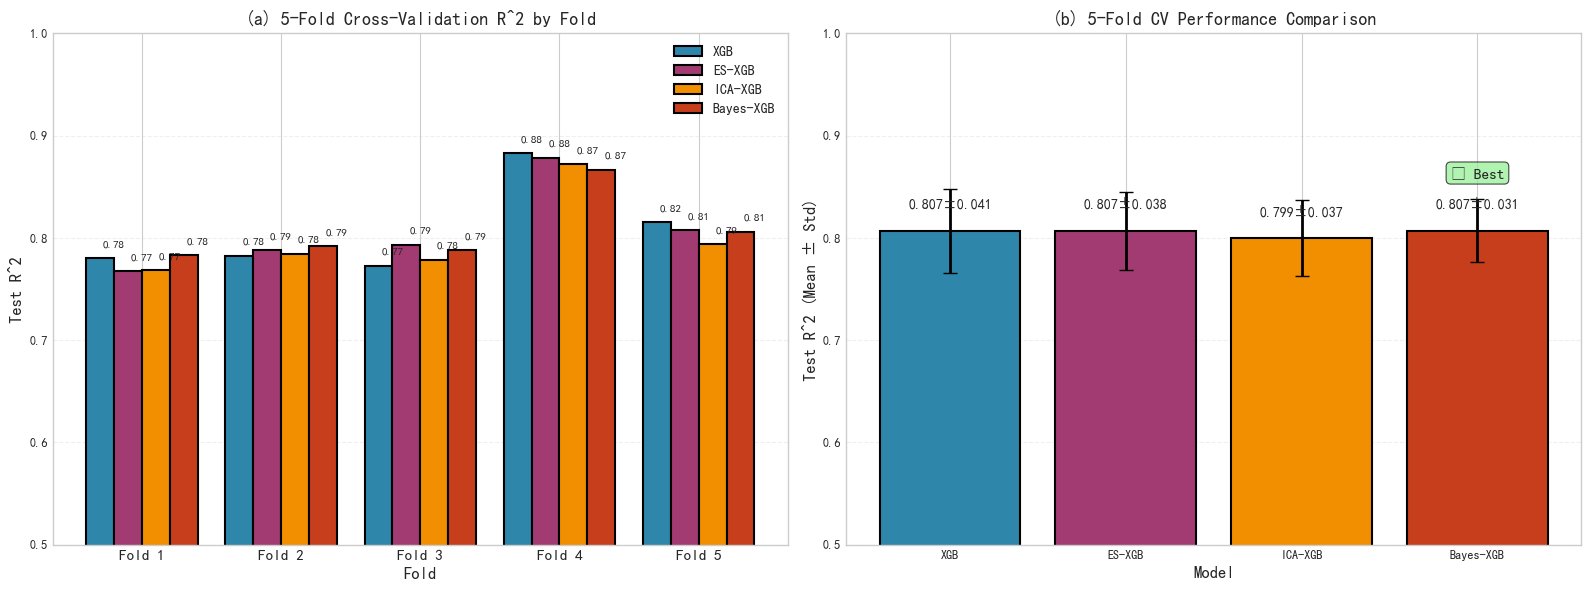

In [84]:
cv_results = {}
folds = [1, 2, 3, 4, 5]

for model_name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2')
    cv_results[model_name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"{model_name:12s}: R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    for i, score in enumerate(cv_scores, 1):
        print(f"  Fold {i}: R² = {score:.4f}")

table_s5_data = []
for model_name, results in cv_results.items():
    for i, score in enumerate(results['scores'], 1):
        table_s5_data.append({
            'Fold': i,
            'Model': model_name,
            'Test_R2': score
        })

table_s5 = pd.DataFrame(table_s5_data)
table_s5.to_csv('Table_S5_5Fold_CV_Results.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'XGB': '#2E86AB', 'ES-XGB': '#A23B72', 'ICA-XGB': '#F18F01', 'Bayes-XGB': '#C73E1D'}

# (a) R² by Fold for Each Model
ax1 = axes[0]
width = 0.2
x_pos = np.arange(len(folds))

for i, (model_name, results) in enumerate(cv_results.items()):
    ax1.bar(x_pos + i*width, results['scores'], width, 
            label=model_name, color=colors[model_name], 
            edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test R^2', fontsize=12, fontweight='bold')
ax1.set_title('(a) 5-Fold Cross-Validation R^2 by Fold', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos + width*1.5)
ax1.set_xticklabels([f'Fold {i}' for i in folds], fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.set_ylim([0.5, 1.0])

for i, (model_name, results) in enumerate(cv_results.items()):
    for j, score in enumerate(results['scores']):
        ax1.text(x_pos[j] + i*width + width/2, score + 0.01, 
                f'{score:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# (b) Mean R² with Std Dev for Each Model
ax2 = axes[1]
model_names = list(cv_results.keys())
mean_scores = [cv_results[m]['mean'] for m in model_names]
std_scores = [cv_results[m]['std'] for m in model_names]
model_colors = [colors[m] for m in model_names]

bars = ax2.bar(model_names, mean_scores, yerr=std_scores, 
               color=model_colors, edgecolor='black', linewidth=1.5, 
               capsize=5, error_kw={'elinewidth': 2})

ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test R^2 (Mean ± Std)', fontsize=12, fontweight='bold')
ax2.set_title('(b) 5-Fold CV Performance Comparison', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.set_ylim([0.5, 1.0])

for bar, mean, std in zip(bars, mean_scores, std_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold')

best_model = max(cv_results, key=lambda x: cv_results[x]['mean'])
best_bar = bars[model_names.index(best_model)]
ax2.text(best_bar.get_x() + best_bar.get_width()/2., best_bar.get_height() + 0.05,
         '✅ Best', ha='center', va='bottom', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

ES-BO-XGBoost

In [85]:
# ES-BO-XGBoost Complete code (including optimizations for random search)
# Basic Model Functions 
def XGB_model(n_estimators, max_depth, learning_rate, subsample, x_train, y_train):
    #Create and train XGBoost model
    model = XGBRegressor(random_state=1, n_jobs=-1,
                         n_estimators=int(round(n_estimators)),
                         max_depth=int(round(max_depth)),
                         learning_rate=learning_rate,
                         subsample=subsample)
    model.fit(x_train, y_train)
    return model

def XGB_model_bayes(n_estimators, max_depth, learning_rate, subsample, x_train, y_train):
    #Create and train Bayes optimized XGBoost model
    model = XGBRegressor(random_state=1, n_jobs=-1,
                         n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         subsample=subsample)
    model.fit(x_train, y_train)
    return model

#  Phase 1: ES Global Rough Search 
print("\n" + "="*80)
print("Phase 1: ES Global Rough Search")
print("="*80)

def ES_XGB(x_train, x_val, y_train, y_val, epochs=50, cv=5):
    #ES Optimization of Global Coarse Search
    
    def xgb_score_cv(n_estimators, max_depth, learning_rate, subsample):
        n_estimators = int(round(n_estimators))
        max_depth = int(round(max_depth))
        
        cv_scores = cross_val_score(
            XGBRegressor(random_state=1, n_jobs=-1,
                        n_estimators=n_estimators, max_depth=max_depth,
                        learning_rate=learning_rate, subsample=subsample),
            X=x_train, y=y_train, cv=cv, scoring='r2', n_jobs=-1
        )
        return cv_scores.mean()
    
    # Initialize the evolutionary strategy optimizer
    p = ES(xgb_score_cv, param_len=4, size=20,
           x_min=[50, 3, 0.01, 0.8],
           x_max=[200, 7, 0.1, 1.0],
           alpha=0.05)
    
    # Finding the Optimal Hyperparameters for ES
    n_estimators_opt, max_depth_opt, learning_rate_opt, subsample_opt = p.solve(epoch=epochs, verbose=False)
    n_estimators_opt = int(round(n_estimators_opt))
    max_depth_opt = int(round(max_depth_opt))
    
    print(f'\n Optimal hyperparameters for ES coarse search:')
    print(f'  n_estimators={n_estimators_opt}, max_depth={max_depth_opt}, '
          f'learning_rate={learning_rate_opt:.4f}, subsample={subsample_opt:.2f}')
    
    # Building ES Model
    ES_XGB_model = XGB_model(n_estimators_opt, max_depth_opt, learning_rate_opt, 
                             subsample_opt, x_train, y_train)
    
    es_best_params = {
        'n_estimators': n_estimators_opt,
        'max_depth': max_depth_opt,
        'learning_rate': learning_rate_opt,
        'subsample': subsample_opt
    }
    original_bounds = {
        'n_estimators': (50, 200),
        'max_depth': (3, 7),
        'learning_rate': (0.01, 0.1),
        'subsample': (0.8, 1.0)
    }
    
    return ES_XGB_model, es_best_params, original_bounds

# generate Bayes prescise search space
def generate_refined_search_space(es_best_params, original_bounds, shrink_ratio=0.4):
    # Generate the Bayes prescise search space based on ES results
    refined_space = []
    
    # n_estimators
    n_opt = es_best_params['n_estimators']
    n_min, n_max = original_bounds['n_estimators']
    n_delta = int(max(10, n_opt * shrink_ratio))
    refined_n_min = max(n_min, n_opt - n_delta)
    refined_n_max = min(n_max, n_opt + n_delta)
    refined_space.append(Integer(refined_n_min, refined_n_max, name='n_estimators'))
    
    # max_depth
    d_opt = es_best_params['max_depth']
    d_min, d_max = original_bounds['max_depth']
    refined_d_min = max(d_min, d_opt - 2)
    refined_d_max = min(d_max, d_opt + 2)
    refined_space.append(Integer(refined_d_min, refined_d_max, name='max_depth'))
    
    # learning_rate
    lr_opt = es_best_params['learning_rate']
    lr_min, lr_max = original_bounds['learning_rate']
    lr_delta = max(0.01, lr_opt * shrink_ratio)
    refined_lr_min = max(lr_min, lr_opt - lr_delta)
    refined_lr_max = min(lr_max, lr_opt + lr_delta)
    refined_space.append(Real(refined_lr_min, refined_lr_max, name='learning_rate'))
    
    # subsample
    ss_opt = es_best_params['subsample']
    ss_min, ss_max = original_bounds['subsample']
    ss_delta = max(0.05, ss_opt * shrink_ratio)
    refined_ss_min = max(ss_min, ss_opt - ss_delta)
    refined_ss_max = min(ss_max, ss_opt + ss_delta)
    refined_space.append(Real(refined_ss_min, refined_ss_max, name='subsample'))
    
    print(f'\n generate Bayes prescise search space (Expanded):')
    for param in refined_space:
        print(f'  {param.name}: {param.low} ~ {param.high}')
    
    return refined_space

#  Phase Two: Bayes prescise Search
print("\n" + "="*80)
print("Phase 2: Bayesian Prescise Search")
print("="*80)

def Bayes_XGB_Refined(x_train, x_val, y_train, y_val, param_space, n_calls=30, stability_penalty=0.5):
    # Bayesian Prescise Search (with Stability Penalty)
    
    @use_named_args(param_space)
    def objective_func(**params):
        cv_scores = cross_val_score(
            XGBRegressor(random_state=1, n_jobs=-1, **params),
            X=x_train, y=y_train, cv=5, scoring='r2', n_jobs=-1
        )
        mean_score = np.mean(cv_scores)
        std_score = np.std(cv_scores)
        robust_score = -(mean_score - stability_penalty * std_score)
        return robust_score
    
    result = gp_minimize(
        func=objective_func,
        dimensions=param_space,
        n_calls=n_calls,
        random_state=1,
        verbose=False,
        n_initial_points=5
    )
    
    n_estimators_opt, max_depth_opt, learning_rate_opt, subsample_opt = result.x
    print(f'\nBayes Optimal Hyperparameter Search (Stability-Aware):')
    print(f'  n_estimators={n_estimators_opt}, max_depth={max_depth_opt}, '
          f'learning_rate={learning_rate_opt:.4f}, subsample={subsample_opt:.2f}')
    
    Bayes_XGB_model = XGB_model_bayes(
        n_estimators_opt, max_depth_opt, learning_rate_opt, subsample_opt,
        x_train, y_train
    )
    return Bayes_XGB_model, result.x

# Random search + 5-fold CV optimize for three key parameters

print("\n" + "="*80)
print("Phase 3: Optimizing Key Parameters via Random Search")
print("="*80)

def random_search_optimization(x_train, y_train, es_best_params, original_bounds, 
                                n_iter=20, cv_folds=5, random_seed=1):
    """
    Three key parameters for stochastic search optimization:
    1. ensemble_weights (ES weight)
    2. shrink_ratio
    3. stability_penalty
    
    Evaluate each set of parameters using 5-fold cross-validation
    """
    
    print(f"\n[Random Search Settings]")
    print(f"  Number of iterations:{n_iter}")
    print(f"  Number of cross-validation folds:{cv_folds}")
    print(f"  Random seed:{random_seed}")
    
    np.random.seed(random_seed)
    
    # Parameter search space
    param_grid = {
        'ensemble_weights': [ (0.1, 0.9), (0.2, 0.8), (0.3, 0.7), (0.4, 0.6), (0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (0.8, 0.2), (0.9, 0.1)],
        'shrink_ratio': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'stability_penalty': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    }
    
    # Save results
    search_results = []
    best_cv_mean = -np.inf
    best_params = None
    
    print(f"\nStart random search (number of iteration: {n_iter} )...")
    print("-"*80)
    print(f"{'Iter':<6} {'Weights':<12} {'Shrink':<8} {'Penalty':<10} {'CV Mean':<10} {'CV Std':<10} {'Status'}")
    print("-"*80)
    
    for i in range(n_iter):
        # Random sampling parameters
        w_es = np.random.choice([w[0] for w in param_grid['ensemble_weights']])
        w_bo = 1.0 - w_es
        shrink = np.random.choice(param_grid['shrink_ratio'])
        penalty = np.random.choice(param_grid['stability_penalty'])
        
        # Generate search space
        refined_space = generate_refined_search_space(es_best_params, original_bounds, shrink_ratio=shrink)
        
        # Define the objective function (with stability penalty)
        @use_named_args(refined_space)
        def objective(**params):
            cv_scores = cross_val_score(
                XGBRegressor(random_state=random_seed+i, n_jobs=-1, **params),
                X=x_train, y=y_train, cv=cv_folds, scoring='r2', n_jobs=-1
            )
            mean_score = np.mean(cv_scores)
            std_score = np.std(cv_scores)
            return -(mean_score - penalty * std_score)
        
        # Run Bayesian optimization (simplified version, with fewer calls to speed up the search)
        result = gp_minimize(
            func=objective,
            dimensions=refined_space,
            n_calls=15,  # Reduce calls to speed up searches
            random_state=random_seed+i,
            verbose=False,
            n_initial_points=3
        )
        
        # Evaluate the optimal parameters
        best_params_temp = {
            'n_estimators': int(round(result.x[0])),
            'max_depth': int(round(result.x[1])),
            'learning_rate': result.x[2],
            'subsample': result.x[3]
        }
        
        model = XGBRegressor(
            random_state=random_seed+i, n_jobs=-1,
            n_estimators=best_params_temp['n_estimators'],
            max_depth=best_params_temp['max_depth'],
            learning_rate=best_params_temp['learning_rate'],
            subsample=best_params_temp['subsample']
        )
        
        # 5-fold CV Evaluation
        cv_scores = cross_val_score(model, x_train, y_train, cv=cv_folds, scoring='r2', n_jobs=-1)
        cv_mean = np.mean(cv_scores)
        cv_std = np.std(cv_scores)
        
        # Save results
        search_results.append({
            'iteration': i+1,
            'weight_es': w_es,
            'weight_bo': w_bo,
            'shrink_ratio': shrink,
            'stability_penalty': penalty,
            'cv_mean': cv_mean,
            'cv_std': cv_std,
            'n_estimators': best_params_temp['n_estimators'],
            'max_depth': best_params_temp['max_depth'],
            'learning_rate': best_params_temp['learning_rate'],
            'subsample': best_params_temp['subsample']
        })
        
        # Optimal Update
        if cv_mean > best_cv_mean:
            best_cv_mean = cv_mean
            best_params = {
                'weight_es': w_es,
                'weight_bo': w_bo,
                'shrink_ratio': shrink,
                'stability_penalty': penalty,
                'xgb_params': best_params_temp
            }
            status = "BEST"
        else:
            status = ""
        
        # Print progress every 5 iterations
        if (i+1) % 5 == 0 or i == n_iter-1:
            print(f"{i+1:<6} {w_es:.1f}:{w_bo:.1f}       {shrink:<8} {penalty:<10} {cv_mean:<10.4f} {cv_std:<10.4f} {status}")
    
    print("-"*80)
    
    # Convert to DataFrame
    results_df = pd.DataFrame(search_results)
    
    # Print the best result
    print(f"\n[Best Results from Random Search]")
    print(f"  Optimal CV Mean R²: {best_cv_mean:.4f} (±{results_df.loc[results_df['cv_mean'].idxmax(), 'cv_std']:.4f})")
    print(f"  Optimal parameter configuration:")
    print(f"    - Ensemble Weights: ES {best_params['weight_es']:.1f} + Bayes {best_params['weight_bo']:.1f}")
    print(f"    - Shrink Ratio: {best_params['shrink_ratio']}")
    print(f"    - Stability Penalty: {best_params['stability_penalty']}")
    print(f"    - XGBoost Params: n_estimators={best_params['xgb_params']['n_estimators']}, "
          f"max_depth={best_params['xgb_params']['max_depth']}, "
          f"learning_rate={best_params['xgb_params']['learning_rate']:.4f}, "
          f"subsample={best_params['xgb_params']['subsample']:.2f}")
    
    return best_params, results_df

class EnsembleWrapper:
    """ES and Bayes Emsemble Wrapper with Optimal Weights"""
    def __init__(self, model_es, model_bo, weight_es=0.5, weight_bo=0.5):
        self.model_es = model_es
        self.model_bo = model_bo
        self.weight_es = weight_es
        self.weight_bo = weight_bo
        
    def predict(self, X):
        pred_es = self.model_es.predict(X)
        pred_bo = self.model_bo.predict(X)
        return self.weight_es * pred_es + self.weight_bo * pred_bo
    
    def fit(self, X, y):
        return self
    
    def score(self, X, y):
        from sklearn.metrics import r2_score
        return r2_score(y, self.predict(X))

# Main Process
print("\n" + "="*80)
print("Start the full optimization process")
print("="*80)

# 1. Phase 1:ES coarse search
es_model, es_best_params, original_bounds = ES_XGB(x_train, x_val, y_train, y_val, epochs=50)

# 2. Phase 2: Bayes Peecise Search (using default settings)
refined_space = generate_refined_search_space(es_best_params, original_bounds, shrink_ratio=0.4)
bayes_model, bayes_result = Bayes_XGB_Refined(x_train, x_val, y_train, y_val, refined_space, 
                                               n_calls=30, stability_penalty=0.5)

# 3. Phase 3: Optimizing Three Key Parameters via Random Search
best_params, search_results_df = random_search_optimization(
    x_train, y_train, 
    es_best_params, original_bounds,
    n_iter=20,  # 20 iterations
    cv_folds=5,
    random_seed=1
)

# 4. Retrain the final model using the optimal parameters
print("\n" + "="*80)
print("=== Train the final model using the optimal parameters ===")
print("="*80)

# Generate the optimal search space
optimal_space = generate_refined_search_space(
    es_best_params, original_bounds, 
    shrink_ratio=best_params['shrink_ratio']
)

# Rerun Bayesian optimization using the optimal stability_penalty
@use_named_args(optimal_space)
def final_objective(**params):
    cv_scores = cross_val_score(
        XGBRegressor(random_state=1, n_jobs=-1, **params),
        X=x_train, y=y_train, cv=5, scoring='r2', n_jobs=-1
    )
    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)
    return -(mean_score - best_params['stability_penalty'] * std_score)

final_result = gp_minimize(
    func=final_objective,
    dimensions=optimal_space,
    n_calls=30,
    random_state=1,
    verbose=False,
    n_initial_points=5
)

# Build the final model
final_es_bayes_model = XGBRegressor(
    random_state=1, n_jobs=-1,
    n_estimators=int(round(final_result.x[0])),
    max_depth=int(round(final_result.x[1])),
    learning_rate=final_result.x[2],
    subsample=final_result.x[3]
)
final_es_bayes_model.fit(x_train, y_train)

# Create an integrated model (using optimal weights)
ensemble_model = EnsembleWrapper(
    es_model, final_es_bayes_model,
    weight_es=best_params['weight_es'],
    weight_bo=best_params['weight_bo']
)

print(f"\n✓ The final model has been trained!")
print(f"  Integrated weights: ES {best_params['weight_es']:.1f} + Bayes {best_params['weight_bo']:.1f}")

# Model Evaluation
print("\n" + "="*80)
print("Comparative Evaluation of Model Performance")
print("="*80)

def evaluate_model(model, x_train, y_train, x_test, y_test, x_val, y_val, model_name):
    # Evaluate model performance
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    
    # training set
    train_pred = model.predict(x_train)
    train_r2 = r2_score(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    
    # Test set
    test_pred = model.predict(x_test)
    test_r2 = r2_score(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    # Validation set
    val_pred = model.predict(x_val)
    val_r2 = r2_score(y_val, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    print(f"\n{model_name}:")
    print(f"  Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
    print(f"  Test R²:  {test_r2:.4f}, RMSE: {test_rmse:.4f}")
    print(f"  Val R²:   {val_r2:.4f}, RMSE: {val_rmse:.4f}")
    
    return {
        'model': model_name,
        'train_r2': train_r2, 'test_r2': test_r2, 'val_r2': val_r2,
        'train_rmse': train_rmse, 'test_rmse': test_rmse, 'val_rmse': val_rmse
    }

# Evaluate three models
results = []
results.append(evaluate_model(es_model, x_train, y_train, x_test, y_test, x_val, y_val, "ES-XGB (Coarse)"))
results.append(evaluate_model(bayes_model, x_train, y_train, x_test, y_test, x_val, y_val, "Bayes-XGB (Default)"))
results.append(evaluate_model(final_es_bayes_model, x_train, y_train, x_test, y_test, x_val, y_val, "ES-Bayes-XGB (Optimized)"))
results.append(evaluate_model(ensemble_model, x_train, y_train, x_test, y_test, x_val, y_val, f"Ensemble (ES:{best_params['weight_es']:.1f}+Bayes:{best_params['weight_bo']:.1f})"))


Phase 1: ES Global Rough Search

Phase 2: Bayesian Prescise Search

Phase 3: Optimizing Key Parameters via Random Search

Start the full optimization process

 Optimal hyperparameters for ES coarse search:
  n_estimators=138, max_depth=5, learning_rate=0.1000, subsample=0.90

 generate Bayes prescise search space (Expanded):
  n_estimators: 83 ~ 193
  max_depth: 3 ~ 7
  learning_rate: 0.06 ~ 0.1
  subsample: 0.8 ~ 1.0

Bayes Optimal Hyperparameter Search (Stability-Aware):
  n_estimators=186, max_depth=6, learning_rate=0.0725, subsample=0.90

[Random Search Settings]
  Number of iterations:20
  Number of cross-validation folds:5
  Random seed:1

Start random search (number of iteration: 20 )...
--------------------------------------------------------------------------------
Iter   Weights      Shrink   Penalty    CV Mean    CV Std     Status
--------------------------------------------------------------------------------

 generate Bayes prescise search space (Expanded):
  n_estimator

Ablation Study


 Ablation Study
  shrink_ratio: 0.5
  stability_penalty: 0.9

[Experiment 1/2: Sensitivity Analysis of stability_penalty]

 Objective: To validate the effectiveness of the stability penalty term and determine the optimal penalty value
--------------------------------------------------------------------------------

[1/11] Test stability_penalty = 0.0... 
 generate Bayes prescise search space (Expanded):
  n_estimators: 71 ~ 200
  max_depth: 4 ~ 7
  learning_rate: 0.05 ~ 0.1
  subsample: 0.8 ~ 1.0
Test R²=0.8589 (116.7s)

[2/11] Test stability_penalty = 0.1... 
 generate Bayes prescise search space (Expanded):
  n_estimators: 54 ~ 160
  max_depth: 3 ~ 7
  learning_rate: 0.05 ~ 0.1
  subsample: 0.8 ~ 1.0
Test R²=0.8651 (90.7s)

[3/11] Test stability_penalty = 0.2... 
 generate Bayes prescise search space (Expanded):
  n_estimators: 63 ~ 187
  max_depth: 3 ~ 7
  learning_rate: 0.05 ~ 0.1
  subsample: 0.8 ~ 1.0
Test R²=0.8283 (87.8s)

[4/11] Test stability_penalty = 0.3... 
 generate Baye

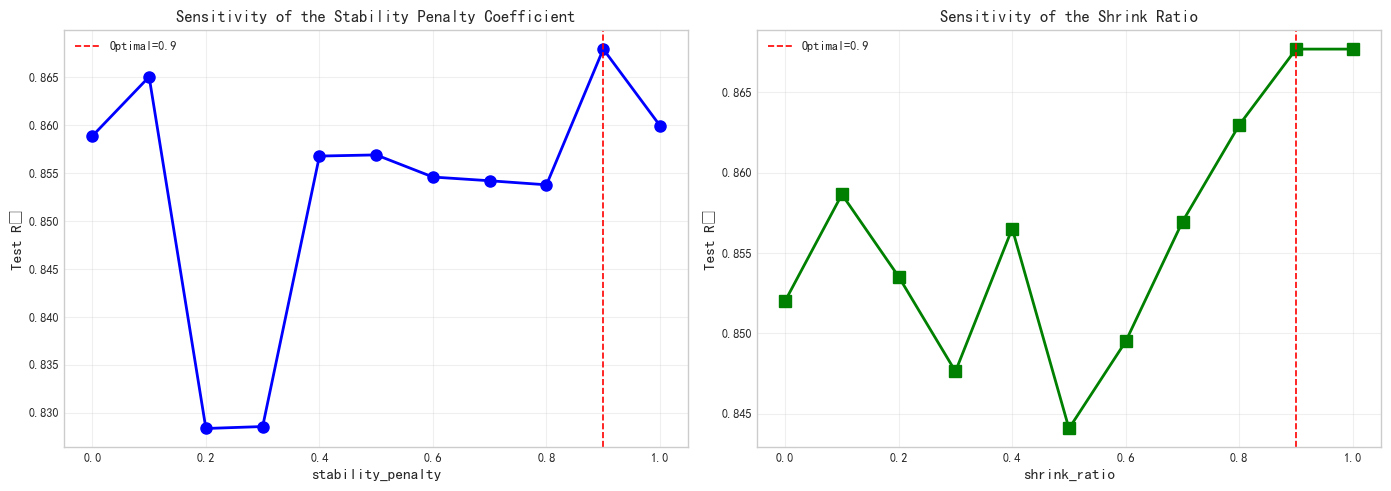

In [86]:
print("\n" + "="*80)
print(" Ablation Study")
print("="*80)

def run_ablation_study(x_train, x_val, y_train, y_val, x_test, y_test, 
                       random_seed=1, quick_mode=False,
                       optimal_shrink_ratio=0.5,
                       optimal_stability_penalty=0.9):
    """
    Experiment 1: Sensitivity to stability_penalty (Validating the stability penalty term)
    Experiment 2: Sensitivity to shrink_ratio (Validating the search space shrinkage strategy)
    """
    
    print(f"  shrink_ratio: {optimal_shrink_ratio}")
    print(f"  stability_penalty: {optimal_stability_penalty}")
    
    # Save all results
    all_results = {
        'penalty': [],
        'shrink': [],
        'framework': []
    }
    
    total_start_time = time.time()
    
    # Configuration Parameters
    es_epochs = 20 if quick_mode else 50
    es_size = 15 if quick_mode else 20
    bayes_calls = 15 if quick_mode else 30
    bayes_init_points = 3 if quick_mode else 5
    
    # Experiment 1: Sensitivity Analysis of stability_penalty
    print("\n" + "="*80)
    print("[Experiment 1/2: Sensitivity Analysis of stability_penalty]")
    print("="*80)
    print("\n Objective: To validate the effectiveness of the stability penalty term and determine the optimal penalty value")
    print("-"*80)
    
    penalty_start_time = time.time()
    penalty_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    penalty_results = []
    
    for i, penalty in enumerate(penalty_values, 1):
        print(f"\n[{i}/{len(penalty_values)}] Test stability_penalty = {penalty}...", end=" ")
        iter_start = time.time()
        
        try:
            # Phase 1: Coarse Search for ES
            def es_objective(n_estimators, max_depth, learning_rate, subsample):
                n_estimators = int(round(n_estimators))
                max_depth = int(round(max_depth))
                cv_scores = cross_val_score(
                    XGBRegressor(random_state=random_seed, n_jobs=-1,
                                n_estimators=n_estimators, max_depth=max_depth,
                                learning_rate=learning_rate, subsample=subsample),
                    X=x_train, y=y_train, cv=5, scoring='r2', n_jobs=-1
                )
                return cv_scores.mean()
            
            p_es = ES(es_objective, param_len=4, size=es_size,
                      x_min=[50, 3, 0.01, 0.8], x_max=[200, 7, 0.1, 1.0], alpha=0.05)
            es_params_opt = p_es.solve(epoch=es_epochs, verbose=False)
            
            es_best_params = {
                'n_estimators': int(round(es_params_opt[0])),
                'max_depth': int(round(es_params_opt[1])),
                'learning_rate': es_params_opt[2],
                'subsample': es_params_opt[3]
            }
            
            # Generate Search Space (using the optimal shrink_ratio)
            original_bounds = {
                'n_estimators': (50, 200), 'max_depth': (3, 7),
                'learning_rate': (0.01, 0.1), 'subsample': (0.8, 1.0)
            }
            refined_space = generate_refined_search_space(
                es_best_params, original_bounds, 
                shrink_ratio=optimal_shrink_ratio
            )
            
            # Phase 2: Bayesian Precise Search (Testing Different penalties)
            @use_named_args(refined_space)
            def bayes_objective(**params):
                cv_scores = cross_val_score(
                    XGBRegressor(random_state=random_seed, n_jobs=-1, **params),
                    X=x_train, y=y_train, cv=5, scoring='r2', n_jobs=-1
                )
                mean_score = np.mean(cv_scores)
                std_score = np.std(cv_scores)
                return -(mean_score - penalty * std_score)
            
            result = gp_minimize(
                func=bayes_objective, dimensions=refined_space,
                n_calls=bayes_calls, random_state=random_seed,
                verbose=False, n_initial_points=bayes_init_points
            )
            
            # Build model
            model = XGBRegressor(
                random_state=random_seed, n_jobs=-1,
                n_estimators=int(round(result.x[0])),
                max_depth=int(round(result.x[1])),
                learning_rate=result.x[2],
                subsample=result.x[3]
            )
            model.fit(x_train, y_train)
            
            # Evaluation
            cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2', n_jobs=-1)
            test_score = model.score(x_test, y_test)
            
            penalty_results.append({
                'stability_penalty': penalty,
                'CV_Mean': cv_scores.mean(),
                'CV_Std': cv_scores.std(),
                'Test_R2': test_score
            })
            
            iter_elapsed = time.time() - iter_start
            print(f"Test R²={test_score:.4f} ({iter_elapsed:.1f}s)")
            
        except Exception as e:
            print(f"Error:{e}")
            penalty_results.append({
                'stability_penalty': penalty,
                'CV_Mean': np.nan, 'CV_Std': np.nan, 'Test_R2': np.nan
            })
    
    penalty_df = pd.DataFrame(penalty_results)
    all_results['penalty'] = penalty_results
    
    if not penalty_df['Test_R2'].isna().all():
        best_penalty_idx = penalty_df['Test_R2'].idxmax()
        best_penalty = penalty_df.loc[best_penalty_idx, 'stability_penalty']
        print(f"\n✓ Optimal stability_penalty: {best_penalty} (Test R² = {penalty_df.loc[best_penalty_idx, 'Test_R2']:.4f})")
    else:
        best_penalty = optimal_stability_penalty
    
    penalty_elapsed = time.time() - penalty_start_time
    print(f"Experiment 1 Duration:{penalty_elapsed/60:.1f} minutes")
    
   
    # Experiment 2: Sensitivity Analysis of shrink_ratio
    print("\n" + "="*80)
    print("[ Experiment 2/2: Sensitivity Analysis of shrink_ratio]")
    print("="*80)
    print("\n Objective: To verify the impact of the search space contraction ratio and determine the optimal shrink_ratio")
    print("-"*80)
    
    shrink_start_time = time.time()
    shrink_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    shrink_results = []
    
    for i, shrink in enumerate(shrink_values, 1):
        print(f"\n[{i}/{len(shrink_values)}] Test shrink_ratio = {shrink}...", end=" ")
        iter_start = time.time()
        
        try:
            # Phase 1: Coarse Search of ES
            es_params_opt = p_es.solve(epoch=es_epochs, verbose=False)
            es_best_params = {
                'n_estimators': int(round(es_params_opt[0])),
                'max_depth': int(round(es_params_opt[1])),
                'learning_rate': es_params_opt[2],
                'subsample': es_params_opt[3]
            }
            
            # Generate search space (test different shrink_ratio values)
            refined_space = generate_refined_search_space(
                es_best_params, original_bounds, 
                shrink_ratio=shrink
            )
            
            # Phase 2: Bayesian Precise Search (using the optimal stability_penalty)
            @use_named_args(refined_space)
            def bayes_objective2(**params):
                cv_scores = cross_val_score(
                    XGBRegressor(random_state=random_seed, n_jobs=-1, **params),
                    X=x_train, y=y_train, cv=5, scoring='r2', n_jobs=-1
                )
                mean_score = np.mean(cv_scores)
                std_score = np.std(cv_scores)
                return -(mean_score - optimal_stability_penalty * std_score)
            
            result = gp_minimize(
                func=bayes_objective2, dimensions=refined_space,
                n_calls=bayes_calls, random_state=random_seed,
                verbose=False, n_initial_points=bayes_init_points
            )
            
            model = XGBRegressor(
                random_state=random_seed, n_jobs=-1,
                n_estimators=int(round(result.x[0])),
                max_depth=int(round(result.x[1])),
                learning_rate=result.x[2],
                subsample=result.x[3]
            )
            model.fit(x_train, y_train)
            
            cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2', n_jobs=-1)
            test_score = model.score(x_test, y_test)
            
            shrink_results.append({
                'shrink_ratio': shrink,
                'CV_Mean': cv_scores.mean(),
                'CV_Std': cv_scores.std(),
                'Test_R2': test_score
            })
            
            iter_elapsed = time.time() - iter_start
            print(f"Test R²={test_score:.4f} ({iter_elapsed:.1f}s)")
            
        except Exception as e:
            print(f"Error:{e}")
            shrink_results.append({
                'shrink_ratio': shrink,
                'CV_Mean': np.nan, 'CV_Std': np.nan, 'Test_R2': np.nan
            })
    
    shrink_df = pd.DataFrame(shrink_results)
    all_results['shrink'] = shrink_results
    
    if not shrink_df['Test_R2'].isna().all():
        best_shrink_idx = shrink_df['Test_R2'].idxmax()
        best_shrink = shrink_df.loc[best_shrink_idx, 'shrink_ratio']
        print(f"\nOptimal shrink_ratio: {best_shrink} (Test R² = {shrink_df.loc[best_shrink_idx, 'Test_R2']:.4f})")
    else:
        best_shrink = optimal_shrink_ratio
    
    shrink_elapsed = time.time() - shrink_start_time
    print(f"Experiment 2 Duration: {shrink_elapsed/60:.1f} minutes")
    
    # Total time
    total_elapsed = time.time() - total_start_time
    
    print("\n" + "="*80)
    print("[Ablation Experiment Complete]")
    print("="*80)
    print(f"  Total time: {total_elapsed/60:.1f} minutes ({total_elapsed/3600:.2f} hours)")
    

    # Visualization
    print("\n" + "="*80)
    print("[Generate Visualization]")
    print("="*80)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # FIgure 1: stability_penalty
    if not penalty_df['Test_R2'].isna().all():
        axes[0].plot(penalty_df['stability_penalty'], penalty_df['Test_R2'], 'o-', linewidth=2, color='blue', markersize=8)
        axes[0].axvline(x=best_penalty, color='r', linestyle='--', label=f'Optimal={best_penalty}')
        axes[0].set_xlabel('stability_penalty', fontsize=11)
        axes[0].set_ylabel('Test R²', fontsize=11)
        axes[0].set_title('Sensitivity of the Stability Penalty Coefficient', fontsize=12, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # FIgure 2: shrink_ratio
    if not shrink_df['Test_R2'].isna().all():
        axes[1].plot(shrink_df['shrink_ratio'], shrink_df['Test_R2'], 's-', linewidth=2, color='green', markersize=8)
        axes[1].axvline(x=best_shrink, color='r', linestyle='--', label=f'Optimal={best_shrink}')
        axes[1].set_xlabel('shrink_ratio', fontsize=11)
        axes[1].set_ylabel('Test R²', fontsize=11)
        axes[1].set_title('Sensitivity of the Shrink Ratio', fontsize=12, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return penalty_df, shrink_df


# Execute
if __name__ == "__main__":
    quick_mode = False  # Set to True for quick testing
    
    try:
        penalty_df, shrink_df = run_ablation_study(
            x_train, x_val, y_train, y_val, x_test, y_test,
            random_seed=1,
            quick_mode=quick_mode,
            optimal_shrink_ratio=0.5,        # Finding the Optimal Value via Random Search
            optimal_stability_penalty=0.9    # Finding the Optimal Value via Random Search
        )
        
    except Exception as e:
        print(f"\n✗ Experiment execution error: {e}")
        import traceback
        traceback.print_exc()

In [10]:
# ES-BO-XGBoost Complete code (Fixed Params Version)
# Basic Model Functions 
def XGB_model(n_estimators, max_depth, learning_rate, subsample, x_train, y_train):
    # Create and train XGBoost model
    model = XGBRegressor(random_state=1, n_jobs=-1,
                         n_estimators=int(round(n_estimators)),
                         max_depth=int(round(max_depth)),
                         learning_rate=learning_rate,
                         subsample=subsample)
    model.fit(x_train, y_train)
    return model

#  Phase 1: ES Global Rough Search 
print("\n" + "="*80)
print("Phase 1: ES Global Rough Search")
print("="*80)

def ES_XGB(x_train, x_val, y_train, y_val, epochs=50, cv=5):
    # ES Optimization of Global Coarse Search
    
    def xgb_score_cv(n_estimators, max_depth, learning_rate, subsample):
        n_estimators = int(round(n_estimators))
        max_depth = int(round(max_depth))
        
        cv_scores = cross_val_score(
            XGBRegressor(random_state=1, n_jobs=-1,
                        n_estimators=n_estimators, max_depth=max_depth,
                        learning_rate=learning_rate, subsample=subsample),
            X=x_train, y=y_train, cv=cv, scoring='r2', n_jobs=-1
        )
        return cv_scores.mean()
    
    # Initialize the evolutionary strategy optimizer
    p = ES(xgb_score_cv, param_len=4, size=20,
           x_min=[50, 3, 0.01, 0.8],
           x_max=[200, 7, 0.1, 1.0],
           alpha=0.05)
    
    # Finding the Optimal Hyperparameters for ES
    n_estimators_opt, max_depth_opt, learning_rate_opt, subsample_opt = p.solve(epoch=epochs, verbose=False)
    n_estimators_opt = int(round(n_estimators_opt))
    max_depth_opt = int(round(max_depth_opt))
    
    print(f'\n Optimal hyperparameters for ES coarse search:')
    print(f'  n_estimators={n_estimators_opt}, max_depth={max_depth_opt}, '
          f'learning_rate={learning_rate_opt:.4f}, subsample={subsample_opt:.2f}')
    
    # Building ES Model (For initial search space reference)
    ES_XGB_model = XGB_model(n_estimators_opt, max_depth_opt, learning_rate_opt, 
                             subsample_opt, x_train, y_train)
    
    es_best_params = {
        'n_estimators': n_estimators_opt,
        'max_depth': max_depth_opt,
        'learning_rate': learning_rate_opt,
        'subsample': subsample_opt
    }
    original_bounds = {
        'n_estimators': (50, 200),
        'max_depth': (3, 7),
        'learning_rate': (0.01, 0.1),
        'subsample': (0.8, 1.0)
    }
    
    return ES_XGB_model, es_best_params, original_bounds

# generate Bayes prescise search space
def generate_refined_search_space(es_best_params, original_bounds, shrink_ratio=0.4):
    # Generate the Bayes prescise search space based on ES results
    refined_space = []
    
    # n_estimators
    n_opt = es_best_params['n_estimators']
    n_min, n_max = original_bounds['n_estimators']
    n_delta = int(max(10, n_opt * shrink_ratio))
    refined_n_min = max(n_min, n_opt - n_delta)
    refined_n_max = min(n_max, n_opt + n_delta)
    refined_space.append(Integer(refined_n_min, refined_n_max, name='n_estimators'))
    
    # max_depth
    d_opt = es_best_params['max_depth']
    d_min, d_max = original_bounds['max_depth']
    refined_d_min = max(d_min, d_opt - 2)
    refined_d_max = min(d_max, d_opt + 2)
    refined_space.append(Integer(refined_d_min, refined_d_max, name='max_depth'))
    
    # learning_rate
    lr_opt = es_best_params['learning_rate']
    lr_min, lr_max = original_bounds['learning_rate']
    lr_delta = max(0.01, lr_opt * shrink_ratio)
    refined_lr_min = max(lr_min, lr_opt - lr_delta)
    refined_lr_max = min(lr_max, lr_opt + lr_delta)
    refined_space.append(Real(refined_lr_min, refined_lr_max, name='learning_rate'))
    
    # subsample
    ss_opt = es_best_params['subsample']
    ss_min, ss_max = original_bounds['subsample']
    ss_delta = max(0.05, ss_opt * shrink_ratio)
    refined_ss_min = max(ss_min, ss_opt - ss_delta)
    refined_ss_max = min(ss_max, ss_opt + ss_delta)
    refined_space.append(Real(refined_ss_min, refined_ss_max, name='subsample'))
    
    print(f'\n Generated Bayes precise search space (Shrink Ratio: {shrink_ratio}):')
    for param in refined_space:
        print(f'  {param.name}: {param.low} ~ {param.high}')
    
    return refined_space

# Main Process
print("\n" + "="*80)
print("Start the optimization process (Fixed Params)")
print("="*80)

# 1. Phase 1: ES coarse search
es_model, es_best_params, original_bounds = ES_XGB(x_train, x_val, y_train, y_val, epochs=50)

# 2. Train the final model (as_es_bayes_model) with fixed params
print("\n" + "="*80)
print("=== Training Final Model: as_es_bayes_model ===")
print("="*80)

# Fixed Parameters
FIXED_SHRINK_RATIO = 0.9
FIXED_STABILITY_PENALTY = 0.9

# Generate the search space with fixed shrink ratio
optimal_space = generate_refined_search_space(
    es_best_params, original_bounds, 
    shrink_ratio=FIXED_SHRINK_RATIO
)

# Define objective function with fixed stability penalty
@use_named_args(optimal_space)
def final_objective(**params):
    cv_scores = cross_val_score(
        XGBRegressor(random_state=1, n_jobs=-1, **params),
        X=x_train, y=y_train, cv=5, scoring='r2', n_jobs=-1
    )
    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)
    return -(mean_score - FIXED_STABILITY_PENALTY * std_score)

# Run Bayesian Optimization
final_result = gp_minimize(
    func=final_objective,
    dimensions=optimal_space,
    n_calls=30,
    random_state=1,
    verbose=False,
    n_initial_points=5
)

# Build the final model (Renamed to as_es_bayes_model)
as_es_bayes_model = XGBRegressor(
    random_state=1, n_jobs=-1,
    n_estimators=int(round(final_result.x[0])),
    max_depth=int(round(final_result.x[1])),
    learning_rate=final_result.x[2],
    subsample=final_result.x[3]
)
as_es_bayes_model.fit(x_train, y_train)

print(f"\n✓ Final model 'as_es_bayes_model' trained successfully!")
print(f"  Hyperparameters:")
print(f"  - n_estimators: {int(round(final_result.x[0]))}")
print(f"  - max_depth:    {int(round(final_result.x[1]))}")
print(f"  - learning_rate: {final_result.x[2]:.4f}")
print(f"  - subsample:    {final_result.x[3]:.2f}")
print(f"  (Settings: shrink_ratio={FIXED_SHRINK_RATIO}, stability_penalty={FIXED_STABILITY_PENALTY})")

# Model Evaluation (Only for as_es_bayes_model)
print("\n" + "="*80)
print("Model Performance Evaluation: as_es_bayes_model")
print("="*80)

def evaluate_model(model, x_train, y_train, x_test, y_test, x_val, y_val, model_name):
    # Evaluate model performance
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    
    # Training set
    train_pred = model.predict(x_train)
    train_r2 = r2_score(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    
    # Test set
    test_pred = model.predict(x_test)
    test_r2 = r2_score(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    # Validation set
    val_pred = model.predict(x_val)
    val_r2 = r2_score(y_val, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    print(f"\n{model_name}:")
    print(f"  Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
    print(f"  Test R²:  {test_r2:.4f}, RMSE: {test_rmse:.4f}")
    print(f"  Val R²:   {val_r2:.4f}, RMSE: {val_rmse:.4f}")
    
    return {
        'model': model_name,
        'train_r2': train_r2, 'test_r2': test_r2, 'val_r2': val_r2,
        'train_rmse': train_rmse, 'test_rmse': test_rmse, 'val_rmse': val_rmse
    }

# Evaluate only the final model
final_results = evaluate_model(as_es_bayes_model, x_train, y_train, x_test, y_test, x_val, y_val, "as_es_bayes_model")


Phase 1: ES Global Rough Search

Start the optimization process (Fixed Params)

 Optimal hyperparameters for ES coarse search:
  n_estimators=132, max_depth=5, learning_rate=0.1000, subsample=0.87

=== Training Final Model: as_es_bayes_model ===

 Generated Bayes precise search space (Shrink Ratio: 0.9):
  n_estimators: 50 ~ 200
  max_depth: 3 ~ 7
  learning_rate: 0.01 ~ 0.1
  subsample: 0.8 ~ 1.0

✓ Final model 'as_es_bayes_model' trained successfully!
  Hyperparameters:
  - n_estimators: 200
  - max_depth:    5
  - learning_rate: 0.1000
  - subsample:    0.92
  (Settings: shrink_ratio=0.9, stability_penalty=0.9)

Model Performance Evaluation: as_es_bayes_model

as_es_bayes_model:
  Train R²: 0.9952, RMSE: 0.1167
  Test R²:  0.8578, RMSE: 0.6453
  Val R²:   0.7873, RMSE: 0.7116


Rubustness Test

In [87]:
# Define noise levels to test (as a percentage of the standard deviation of the data)
noise_levels = [0.10, 0.20, 0.30, 0.40, 0.50]  # 10%, 20%, 30%, 40%, 50%
robustness_results = []

models = {
    'ES-XGB': es_xgb,
    'Bayes-XGB': bayes_xgb,
    'ES-Bayes-XGB': final_es_bayes_model
}

print(f"\nTesting {len(models)} models × {len(noise_levels)} noise levels = {len(models)*len(noise_levels)} experiments")

for noise_level in noise_levels:
    print(f"\n{'='*60}")
    print(f"Adding Gaussian Noise: η = {noise_level*100:.0f}%")
    print(f"{'='*60}")
    
    # Calculate noise standard deviation based on the training data's standard deviation
    data_std = np.std(x_train, axis=0)
    noise_std = data_std * noise_level
    
    for model_name, model in models.items():
        print(f"\n  Training {model_name} with noise")
        
        # Add Gaussian noise to the training data
        # np.random.seed(1)  # For reproducibility
        for seed in range(5):
            np.random.seed(seed)
        x_train_noisy = x_train + np.random.normal(0, noise_std, x_train.shape)
        
        # Clone the original model to ensure we start with the same parameters for each noise level
        model_noisy = clone(model)
        model_noisy.fit(x_train_noisy, y_train)
        
        # Evaluate the model's performance on the original test and validation sets
        results = evaluate_model_robustness(
            model_noisy, x_train_noisy, y_train, 
            x_test, y_test, x_val, y_val, 
            f"{model_name}"
        )
        results['Noise_Level'] = f"{noise_level*100:.0f}%"
        
        robustness_results.append(results)
        
        print(f"    Train R² = {results['Train_R2']:.4f}")
        print(f"    Test R² = {results['Test_R2']:.4f}")
        print(f"    Valid R² = {results['Val_R2']:.4f}")
        print(f"    Test RMSE = {results['Test_RMSE']:.4f}")



Testing 3 models × 5 noise levels = 15 experiments

Adding Gaussian Noise: η = 10%

  Training ES-XGB with noise
    Train R² = 0.9964
    Test R² = 0.6613
    Valid R² = 0.5922
    Test RMSE = 0.9961

  Training Bayes-XGB with noise
    Train R² = 0.9944
    Test R² = 0.6670
    Valid R² = 0.5828
    Test RMSE = 0.9876

  Training ES-Bayes-XGB with noise
    Train R² = 0.9992
    Test R² = 0.6772
    Valid R² = 0.5771
    Test RMSE = 0.9723

Adding Gaussian Noise: η = 20%

  Training ES-XGB with noise
    Train R² = 0.9956
    Test R² = 0.6268
    Valid R² = 0.5314
    Test RMSE = 1.0454

  Training Bayes-XGB with noise
    Train R² = 0.9930
    Test R² = 0.6240
    Valid R² = 0.4922
    Test RMSE = 1.0494

  Training ES-Bayes-XGB with noise
    Train R² = 0.9992
    Test R² = 0.6234
    Valid R² = 0.5156
    Test RMSE = 1.0503

Adding Gaussian Noise: η = 30%

  Training ES-XGB with noise
    Train R² = 0.9933
    Test R² = 0.5985
    Valid R² = 0.5099
    Test RMSE = 1.0844

  Train

In [88]:
models_to_test = {
    'ES-XGB': es_xgb,
    'Bayes-XGB': bayes_xgb,
    'ES-Bayes-XGB': final_es_bayes_model
}

baseline_models = {}
for model_name, model in models_to_test.items():
    baseline_model = clone(model)
    baseline_model.fit(x_train, y_train)
    baseline_r2_test = r2_score(y_test, baseline_model.predict(x_test))
    baseline_r2_val = r2_score(y_val, baseline_model.predict(x_val))
    baseline_models[model_name] = {
        'model': baseline_model,
        'test_r2': baseline_r2_test,
        'val_r2': baseline_r2_val
    }
    print(f"{model_name} Baseline Test R²: {baseline_r2_test:.4f}")
    print(f"{model_name} Baseline Val R²: {baseline_r2_val:.4f}")

ES-XGB Baseline Test R²: 0.8583
ES-XGB Baseline Val R²: 0.7746
Bayes-XGB Baseline Test R²: 0.8269
Bayes-XGB Baseline Val R²: 0.7665
ES-Bayes-XGB Baseline Test R²: 0.8697
ES-Bayes-XGB Baseline Val R²: 0.7881


In [90]:
# Feature Removal Robustness TEST
feature_removal_results = []

for feature_to_remove in features_to_remove:
    print(f"Removing Feature: '{feature_to_remove}'")
    
    features_to_keep = [f for f in feature_names if f != feature_to_remove]
    feature_indices = [feature_names.index(f) for f in features_to_keep]
    
    print(f"  Remaining features ({len(features_to_keep)}): {features_to_keep}")
    
    if hasattr(x_train, 'iloc'):
        x_train_reduced = x_train.iloc[:, feature_indices].values
        x_test_reduced = x_test.iloc[:, feature_indices].values
        x_val_reduced = x_val.iloc[:, feature_indices].values
    else:
        x_train_reduced = x_train[:, feature_indices]
        x_test_reduced = x_test[:, feature_indices]
        x_val_reduced = x_val[:, feature_indices]
    
    for model_name, model in models_to_test.items():
        print(f"\n  Training {model_name} without '{feature_to_remove}'...")
        
        model_reduced = clone(model)
        model_reduced.fit(x_train_reduced, y_train)
        
        results = evaluate_model_robustness(
            model_reduced, x_train_reduced, y_train,
            x_test_reduced, y_test, x_val_reduced, y_val,
            f"{model_name}"
        )
        results['Removed_Feature'] = feature_to_remove
        results['Remaining_Features'] = len(features_to_keep)
        
        feature_removal_results.append(results)

        baseline_r2 = baseline_models[model_name]['test_r2']
        r2_drop = baseline_r2 - results['Test_R2']
        print(f"    Test R² = {results['Test_R2']:.4f} (Original: {baseline_r2:.4f}, Drop: {r2_drop:.4f})")
        print(f"    Validation R² = {results['Val_R2']:.4f}")
        print(f"    Test RMSE = {results['Test_RMSE']:.4f}")

Removing Feature: 'A'
  Remaining features (8): ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'B', 'V']

  Training ES-XGB without 'A'...
    Test R² = 0.8504 (Original: 0.8583, Drop: 0.0080)
    Validation R² = 0.7331
    Test RMSE = 0.6620

  Training Bayes-XGB without 'A'...
    Test R² = 0.8355 (Original: 0.8269, Drop: -0.0086)
    Validation R² = 0.7625
    Test RMSE = 0.6942

  Training ES-Bayes-XGB without 'A'...
    Test R² = 0.8533 (Original: 0.8697, Drop: 0.0164)
    Validation R² = 0.7653
    Test RMSE = 0.6555
Removing Feature: 'B'
  Remaining features (8): ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'V']

  Training ES-XGB without 'B'...
    Test R² = 0.8088 (Original: 0.8583, Drop: 0.0495)
    Validation R² = 0.6951
    Test RMSE = 0.7483

  Training Bayes-XGB without 'B'...
    Test R² = 0.7936 (Original: 0.8269, Drop: 0.0333)
    Validation R² = 0.7093
    Test RMSE = 0.7775

  Training ES-Bayes-XGB without 'B'...
    Test R² = 0.8196 (Original: 0.8697, Drop: 0.0501)
    Validat

In [91]:
print("5-FOLD CROSS-VALIDATION")
cv_results = {}
for model_name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2')
    cv_results[model_name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"{model_name:12s}: R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-FOLD CROSS-VALIDATION
ES-XGB      : R² = 0.8069 ± 0.0379
Bayes-XGB   : R² = 0.8070 ± 0.0307
ES-Bayes-XGB: R² = 0.8000 ± 0.0372


In [92]:
cv_results = {}
folds = [1, 2, 3, 4, 5]

for model_name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2')
    cv_results[model_name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"{model_name:12s}: R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    for i, score in enumerate(cv_scores, 1):
        print(f"  Fold {i}: R² = {score:.4f}")

table_s5_data = []
for model_name, results in cv_results.items():
    for i, score in enumerate(results['scores'], 1):
        table_s5_data.append({
            'Fold': i,
            'Model': model_name,
            'Test_R2': score
        })

table_s5 = pd.DataFrame(table_s5_data)

ES-XGB      : R² = 0.8069 ± 0.0379
  Fold 1: R² = 0.7673
  Fold 2: R² = 0.7879
  Fold 3: R² = 0.7934
  Fold 4: R² = 0.8782
  Fold 5: R² = 0.8076
Bayes-XGB   : R² = 0.8070 ± 0.0307
  Fold 1: R² = 0.7829
  Fold 2: R² = 0.7919
  Fold 3: R² = 0.7878
  Fold 4: R² = 0.8665
  Fold 5: R² = 0.8059
ES-Bayes-XGB: R² = 0.8000 ± 0.0372
  Fold 1: R² = 0.7609
  Fold 2: R² = 0.7802
  Fold 3: R² = 0.7959
  Fold 4: R² = 0.8703
  Fold 5: R² = 0.7926


Uncertainty Quantification Analysis


Bootstrap Uncertainty Quantification

Begin quantifying uncertainty

[Experimental Setup]
  Bootstrap Count:2000
  Confidence level:95.0%
  BCa Correction: Yes
  Coverage Calibration: Yes

 Bootstrap resampling in progress...
  Progress:200/2000 (Success:200)
  Progress:400/2000 (Success:400)
  Progress:600/2000 (Success:600)
  Progress:800/2000 (Success:800)
  Progress:1000/2000 (Success:1000)
  Progress:1200/2000 (Success:1200)
  Progress:1400/2000 (Success:1400)
  Progress:1600/2000 (Success:1600)
  Progress:1800/2000 (Success:1800)
  Progress:2000/2000 (Success:2000)

✓ Successfully completed 2000/2000 Bootstrap runs

 Calculating the BCa corrected confidence interval...

 Performing coverage calibration...
 Coverage before calibration:78.6%
  Calibration factor: 1.208 (interval expanded)

[Bootstrap Quantification of Uncertainty]
  Nominal coverage: 95.0%
  Actual coverage:87.4%
  Average interval width:1.8429
  Number of samples covered:90/103

[Uncertainty Decomposition]
  Alea

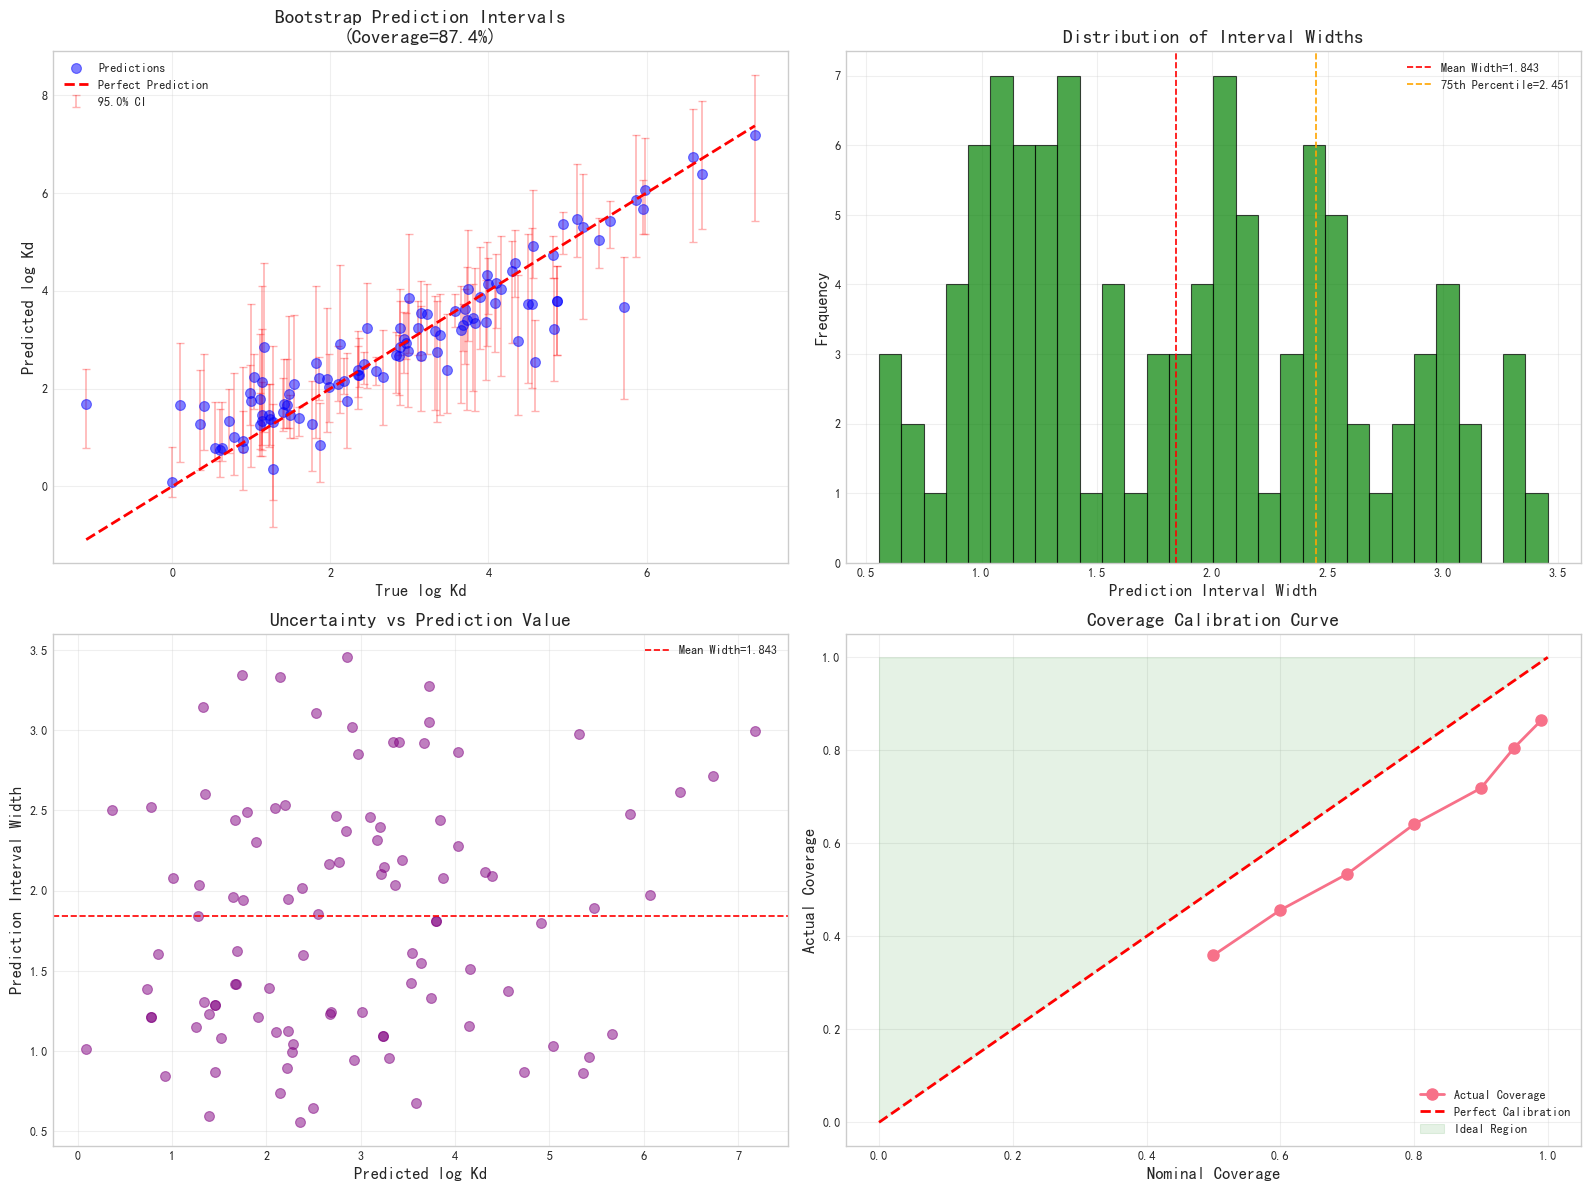


Quantification of uncertainty completed 

 [Summary of Key Metrics]
  Coverage:87.4%
  Average interval width:1.8429
  Aleatoric Uncertainty:0.6813
  Epistemic Uncertainty:0.3987
  Samples with high uncertainty:26
  Number of successful Bootstraps:2000


In [ ]:
print("\n" + "="*80)
print("Bootstrap Uncertainty Quantification")
print("="*80)

def bca_confidence_interval(bootstrap_predictions, alpha=0.05):
    """
    BCa (Bias-Corrected and Accelerated) Bootstrap 
    """
    n_bootstrap = bootstrap_predictions.shape[0]
    n_samples = bootstrap_predictions.shape[1]
    
    y_lower = np.zeros(n_samples)
    y_upper = np.zeros(n_samples)
    
    for i in range(n_samples):
        pred_dist = bootstrap_predictions[:, i]
        
        # 1. Calculate the correction factor (z0)
        median = np.median(pred_dist)
        z0 = stats.norm.ppf(np.mean(pred_dist < median))
        
        # 2. Calculate the acceleration factor (a)
        jackknife_estimates = np.zeros(n_bootstrap)
        for j in range(n_bootstrap):
            jackknife_estimates[j] = np.mean(np.delete(pred_dist, j))
        
        mean_jack = np.mean(jackknife_estimates)
        numerator = np.sum((mean_jack - jackknife_estimates)**3)
        denominator = (np.sum((mean_jack - jackknife_estimates)**2))**1.5
        
        if denominator > 0:
            a = numerator / (6 * denominator)
        else:
            a = 0
        
        # 3. Calculate the BCa percentile
        z_alpha = stats.norm.ppf(alpha / 2)
        z_1_alpha = stats.norm.ppf(1 - alpha / 2)
        
        alpha_lower = stats.norm.cdf(z0 + (z0 + z_alpha) / (1 - a * (z0 + z_alpha)))
        alpha_upper = stats.norm.cdf(z0 + (z0 + z_1_alpha) / (1 - a * (z0 + z_1_alpha)))
        
        # 4. Calculate the confidence interval
        y_lower[i] = np.percentile(pred_dist, max(0, min(100, alpha_lower * 100)))
        y_upper[i] = np.percentile(pred_dist, max(0, min(100, alpha_upper * 100)))
    
    return y_lower, y_upper


def uncertainty_quantification_enhanced(model, x_train, y_train, x_test, y_test, 
                                         n_bootstrap=2000, confidence_level=0.95,
                                         use_bca=True, calibrate=True, random_seed=1):
    
    # Quantification of Bootstrap Uncertainty
    print(f"\n[Experimental Setup]")
    print(f"  Bootstrap Count:{n_bootstrap}")
    print(f"  Confidence level:{confidence_level*100}%")
    print(f"  BCa Correction: {'Yes' if use_bca else 'No'}")
    print(f"  Coverage Calibration: {'Yes' if calibrate else 'No'}")
    
    # Set the random seed
    np.random.seed(random_seed)
    
    # Store all bootstrap predictions
    bootstrap_predictions = []
    successful_bootstrap = 0
    
    print(f"\n Bootstrap resampling in progress...")
    
    for i in range(n_bootstrap):
        indices = np.random.randint(0, len(x_train), size=len(x_train))
        
        if hasattr(x_train, 'iloc'):
            x_boot = x_train.iloc[indices]
            y_boot = y_train.iloc[indices]
        else:
            x_boot = x_train[indices]
            y_boot = y_train[indices]
        
        # Train model
        try:
            model_boot = clone(model)
            model_boot.fit(x_boot, y_boot)
            pred = model_boot.predict(x_test)
            bootstrap_predictions.append(pred)
            successful_bootstrap += 1
        except Exception as e:
            if i < 5:  # Show only the first 5 errors
                print(f"  Warning: Bootstrap failed for the {i+1}th time:{e}")
            continue
        
        if (i + 1) % 200 == 0:
            print(f"  Progress:{i+1}/{n_bootstrap} (Success:{successful_bootstrap})")
    
    # Convert to a NumPy array
    bootstrap_predictions = np.array(bootstrap_predictions)
    actual_n_bootstrap = bootstrap_predictions.shape[0]
    
    if actual_n_bootstrap < n_bootstrap * 0.9:
        print(f"\n⚠️  Warning: Only {actual_n_bootstrap}/{n_bootstrap} bootstraps were successful")
    
    print(f"\n✓ Successfully completed {actual_n_bootstrap}/{n_bootstrap} Bootstrap runs")
    
    # Calculate the predicted statistic
    y_pred_mean = np.mean(bootstrap_predictions, axis=0)
    y_pred_std = np.std(bootstrap_predictions, axis=0)  # Epistemic uncertainty
    
    # Calculate the prediction interval
    if use_bca:
        print("\n Calculating the BCa corrected confidence interval...")
        y_lower, y_upper = bca_confidence_interval(bootstrap_predictions, alpha=1-confidence_level)
    else:
        alpha = 1 - confidence_level
        y_lower = np.percentile(bootstrap_predictions, alpha/2 * 100, axis=0)
        y_upper = np.percentile(bootstrap_predictions, (1-alpha/2) * 100, axis=0)
    
    # Coverage Calibration (Calibration)
    calibration_factor = 1.0
    if calibrate:
        print("\n Performing coverage calibration...")
        initial_coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))
        print(f" Coverage before calibration:{initial_coverage*100:.1f}%")
        
        # Calculate the calibration factor
        if initial_coverage < confidence_level:
            calibration_factor = confidence_level / initial_coverage
            y_pred_center = (y_lower + y_upper) / 2
            half_width = (y_upper - y_lower) / 2 * calibration_factor
            y_lower = y_pred_center - half_width
            y_upper = y_pred_center + half_width
            print(f"  Calibration factor: {calibration_factor:.3f} (interval expanded)")
        else:
            print(f"  Calibration factor: {calibration_factor:.3f} (No adjustment required)")
    
    # Calculate uncertainty metrics
    interval_width = y_upper - y_lower
    coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))
    
    # Uncertainty decomposition
    residuals = y_test - y_pred_mean
    aleatoric_uncertainty = np.std(residuals)
    epistemic_uncertainty = np.mean(y_pred_std)
    total_uncertainty = np.sqrt(aleatoric_uncertainty**2 + epistemic_uncertainty**2)
    
    print(f"\n[Bootstrap Quantification of Uncertainty]")
    print(f"  Nominal coverage: {confidence_level*100}%")
    print(f"  Actual coverage:{coverage*100:.1f}%")
    print(f"  Average interval width:{np.mean(interval_width):.4f}")
    print(f"  Number of samples covered:{np.sum((y_test >= y_lower) & (y_test <= y_upper))}/{len(y_test)}")
    
    print(f"\n[Uncertainty Decomposition]")
    print(f"  Aleatoric (Data uncertainty): {aleatoric_uncertainty:.4f}")
    print(f"  Epistemic (Model uncertainty): {epistemic_uncertainty:.4f}")
    print(f"  Total uncertainty:{total_uncertainty:.4f}")
    
    # Identifying samples with high uncertainty
    high_uncertainty_threshold = np.percentile(interval_width, 75)
    high_uncertainty_indices = np.where(interval_width > high_uncertainty_threshold)[0]
    print(f"\n[Identifying samples with high uncertainty]")
    print(f"  Threshold (75th Percentile): {high_uncertainty_threshold:.4f}")
    print(f"  Number of samples with high uncertainty:{len(high_uncertainty_indices)} ({len(high_uncertainty_indices)/len(y_test)*100:.1f}%)")
    
    # Visualization
    print("\n[Generate Visualizations]")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Figure 1: Predicted values vs. actual values (with error bars)
    axes[0, 0].scatter(y_test, y_pred_mean, alpha=0.5, s=50, c='blue', label='Predictions', zorder=5)
    axes[0, 0].errorbar(y_test, y_pred_mean, 
                        yerr=[y_pred_mean-y_lower, y_upper-y_pred_mean],
                        fmt='none', ecolor='red', alpha=0.3, capsize=3, 
                        label=f'{confidence_level*100}% CI', zorder=1)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                    'r--', linewidth=2, label='Perfect Prediction', zorder=10)
    axes[0, 0].set_xlabel('True log Kd', fontsize=12)
    axes[0, 0].set_ylabel('Predicted log Kd', fontsize=12)
    axes[0, 0].set_title(f'Bootstrap Prediction Intervals\n(Coverage={coverage*100:.1f}%)', fontsize=14)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Figure 2: Distribution of prediction interval widths
    axes[0, 1].hist(interval_width, bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].axvline(x=np.mean(interval_width), color='r', linestyle='--', 
                       label=f'Mean Width={np.mean(interval_width):.3f}')
    axes[0, 1].axvline(x=high_uncertainty_threshold, color='orange', linestyle='--',
                       label=f'75th Percentile={high_uncertainty_threshold:.3f}')
    axes[0, 1].set_xlabel('Prediction Interval Width', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Distribution of Interval Widths', fontsize=14)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Figure 3: Uncertainty vs. Forecast
    axes[1, 0].scatter(y_pred_mean, interval_width, alpha=0.5, s=50, c='purple')
    axes[1, 0].axhline(y=np.mean(interval_width), color='r', linestyle='--', 
                       label=f'Mean Width={np.mean(interval_width):.3f}')
    axes[1, 0].set_xlabel('Predicted log Kd', fontsize=12)
    axes[1, 0].set_ylabel('Prediction Interval Width', fontsize=12)
    axes[1, 0].set_title('Uncertainty vs Prediction Value', fontsize=14)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Figure 4: Coverage calibration curve
    coverages = []
    nominal_levels = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    for level in nominal_levels:
        alpha = 1 - level
        lower = np.percentile(bootstrap_predictions, alpha/2 * 100, axis=0)
        upper = np.percentile(bootstrap_predictions, (1-alpha/2) * 100, axis=0)
        cov = np.mean((y_test >= lower) & (y_test <= upper))
        coverages.append(cov)
    
    axes[1, 1].plot(nominal_levels, coverages, 'o-', linewidth=2, markersize=8, label='Actual Coverage')
    axes[1, 1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Calibration')
    axes[1, 1].fill_between([0, 1], [0, 1], [1, 1], alpha=0.1, color='green', label='Ideal Region')
    axes[1, 1].set_xlabel('Nominal Coverage', fontsize=12)
    axes[1, 1].set_ylabel('Actual Coverage', fontsize=12)
    axes[1, 1].set_title('Coverage Calibration Curve', fontsize=14)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    uncertainty_results = pd.DataFrame({
        'True_logKd': y_test,
        'Pred_Mean': y_pred_mean,
        'Pred_Lower': y_lower,
        'Pred_Upper': y_upper,
        'Interval_Width': interval_width,
        'Pred_Std': y_pred_std,
        'Covered': (y_test >= y_lower) & (y_test <= y_upper),
        'High_Uncertainty': interval_width > high_uncertainty_threshold
    })

    # Back to Detailed Results
    results = {
        'coverage': coverage,
        'avg_width': np.mean(interval_width),
        'aleatoric': aleatoric_uncertainty,
        'epistemic': epistemic_uncertainty,
        'total': total_uncertainty,
        'high_uncertainty_count': len(high_uncertainty_indices),
        'calibration_factor': calibration_factor if calibrate else 1.0,
        'n_bootstrap': actual_n_bootstrap
    }
    
    return uncertainty_results, results


# Quantification Uncertainty

if __name__ == "__main__":
    print("\n" + "="*80)
    print("Begin quantifying uncertainty")
    print("="*80)
    
    # Check if the required variables exist
    required_vars = ['final_es_bayes_model', 'x_train', 'y_train', 'x_test', 'y_test']
    missing_vars = [var for var in required_vars if var not in globals()]
    
    if missing_vars:
        print(f"\n✗ Error: The following variables are missing:{missing_vars}")
        print("Please run the model training code first to ensure that the following variables have been defined:")
        for var in required_vars:
            print(f"  - {var}")
    else:
        try:
            uncertainty_results, results = uncertainty_quantification_enhanced(
                model=final_es_bayes_model,
                x_train=x_train,
                y_train=y_train,
                x_test=x_test,
                y_test=y_test,
                n_bootstrap=2000,
                confidence_level=0.95,
                use_bca=True,
                calibrate=True,
                random_seed=1
            )
            
            print("\n" + "="*80)
            print("Quantification of uncertainty completed ")
            print("="*80)
            
            print(f"\n [Summary of Key Metrics]")
            print(f"  Coverage:{results['coverage']*100:.1f}%")
            print(f"  Average interval width:{results['avg_width']:.4f}")
            print(f"  Aleatoric Uncertainty:{results['aleatoric']:.4f}")
            print(f"  Epistemic Uncertainty:{results['epistemic']:.4f}")
            print(f"  Samples with high uncertainty:{results['high_uncertainty_count']}")
            print(f"  Number of successful Bootstraps:{results['n_bootstrap']}")
            
        except Exception as e:
            print(f"\n✗ error:{e}")
            import traceback
            traceback.print_exc()

In [96]:
high_uncertainty_samples = uncertainty_results[uncertainty_results['High_Uncertainty'] == True]
print(high_uncertainty_samples[['True_logKd', 'Pred_Mean', 'Interval_Width']].describe())

       True_logKd  Pred_Mean  Interval_Width
count   26.000000  26.000000       26.000000
mean     3.298346   3.239504        2.849298
std      2.067555   1.795801        0.312489
min      0.892095   0.365058        2.461987
25%      1.270674   2.101229        2.523648
50%      3.373733   2.936264        2.890397
75%      4.542714   3.725443        3.043226
max      7.370000   7.177944        3.454725



Analysis of Sample Characteristics with High Uncertainty

Data conversion complete:(103, 9)

[Sample Distribution]
  Samples with high uncertainty:26  (25.2%)
  Normal sample:77  (74.8%)

[Comparison of Feature Distributions]
Feature  High_Uncertainty_Mean  Normal_Mean  Difference  High_Uncertainty_Std  Normal_Std   Cohen_d Significance
    H/C               0.098877     0.122735   -0.023858              0.050059    0.059425 -0.434238            *
      E               2.044615     1.818312    0.226304              0.575550    0.663804  0.364274            *
      B               0.610769     0.859753   -0.248984              0.598571    0.890938 -0.328057            *
     C%               0.768885     0.811627   -0.042741              0.189231    0.120237 -0.269606            *
      A               0.301154     0.245455    0.055699              0.361810    0.383246  0.149455             
    SSA               7.472942     5.982295    1.490647             15.636173   15.619937  0.09

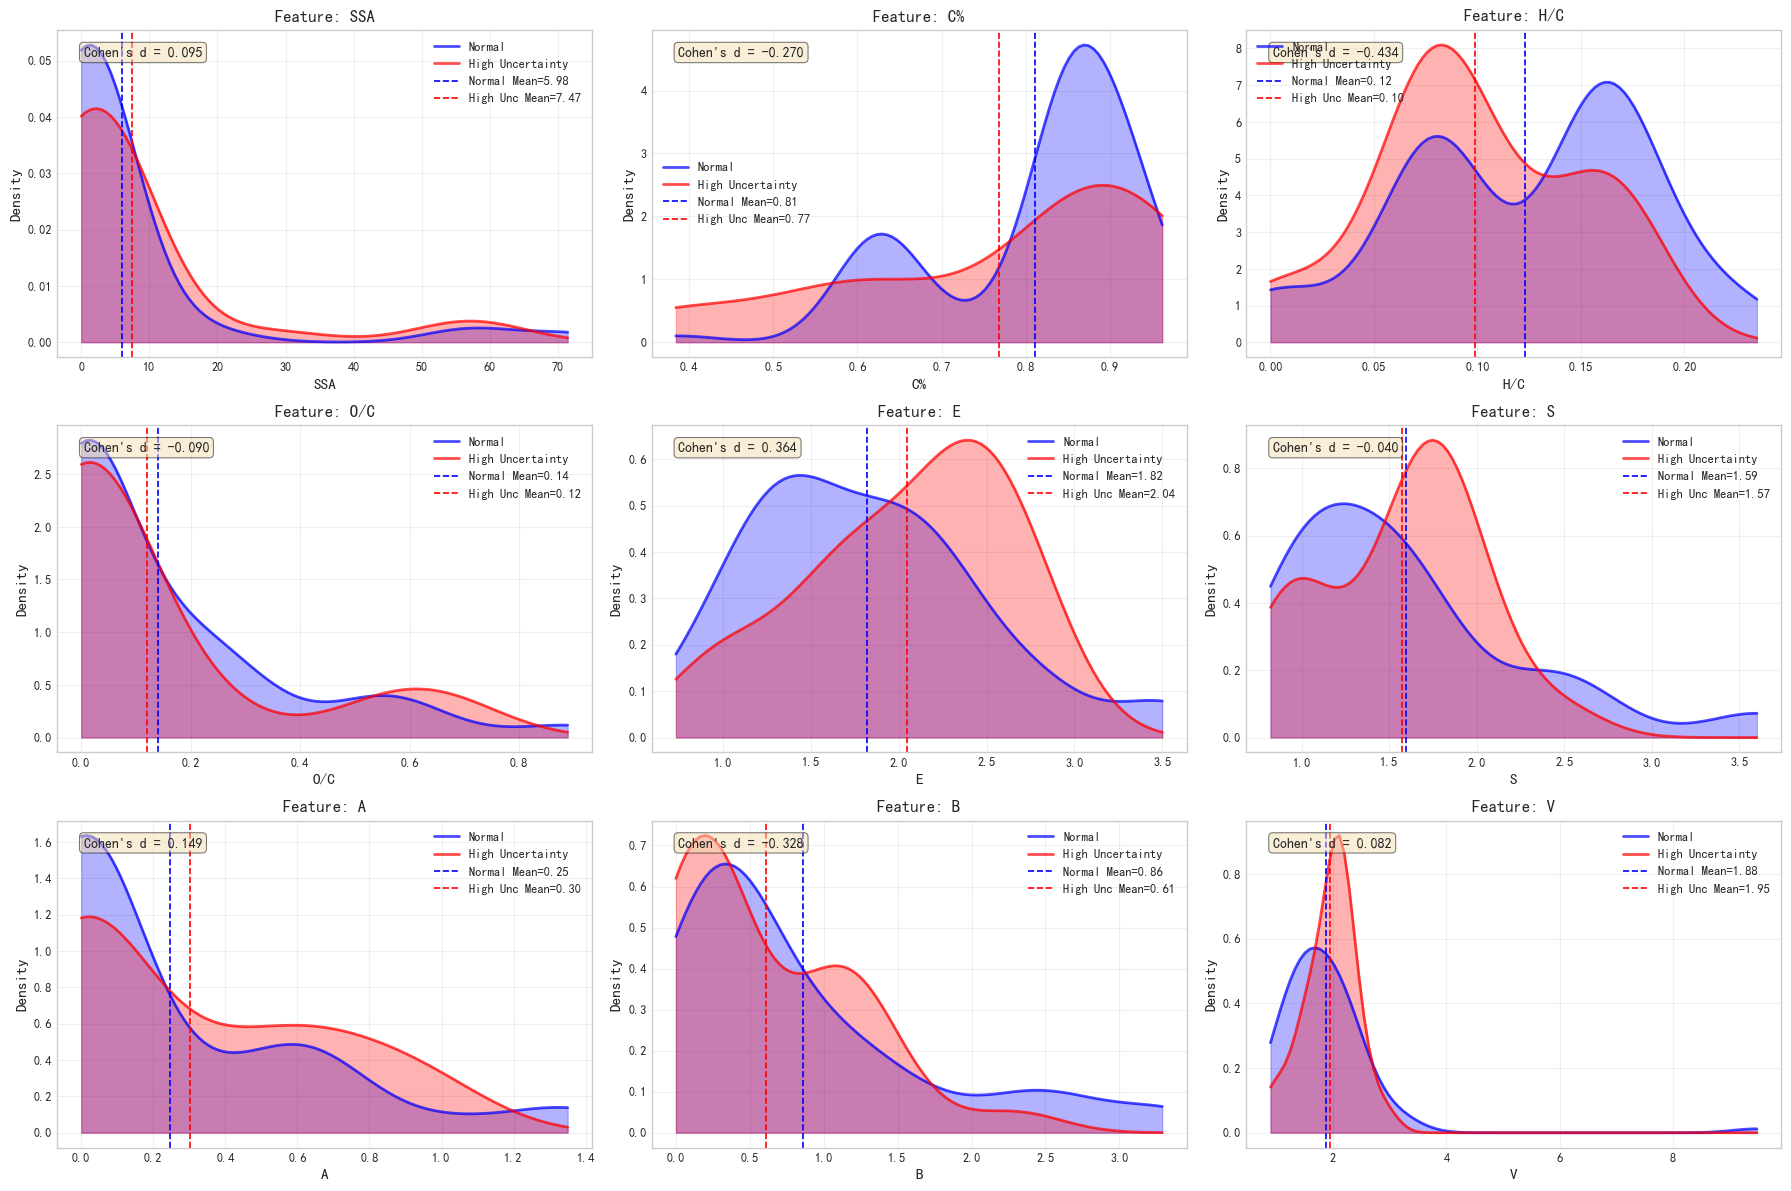


Analysis by Feature Type

【Physical Properties of Microplastics】
------------------------------------------------------------
  Average effect size |Cohen's d|: 0.095
  maximum effect size |Cohen's d|: 0.095
  ✓ This category shows little variation in samples with high uncertainty

  Detailed Comparison:
    SSA: High uncertainty=7.473, Normal=5.982, Difference=1.491, Effect size=0.095 

【Chemical Composition of Microplastics】
------------------------------------------------------------
  Average effect size |Cohen's d|: 0.265
  maximum effect size |Cohen's d|: 0.434
  ✓ This category shows little variation in samples with high uncertainty

  Detailed Comparison:
    H/C: High uncertainty=0.099, Normal=0.123, Difference=-0.024, Effect size=-0.434 *
    C%: High uncertainty=0.769, Normal=0.812, Difference=-0.043, Effect size=-0.270 *
    O/C: High uncertainty=0.120, Normal=0.140, Difference=-0.020, Effect size=-0.090 

【Solute descriptor (Abraham)】
-------------------------------------

In [98]:
print("\n" + "="*80)
print("Analysis of Sample Characteristics with High Uncertainty")
print("="*80)

# Convert a NumPy array to a DataFrame
feature_names = ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V']  

# Convert the test set to a DataFrame
if isinstance(x_test, np.ndarray):
    x_test_df = pd.DataFrame(x_test, columns=feature_names)
    x_train_df = pd.DataFrame(x_train, columns=feature_names)
else:
    x_test_df = x_test
    x_train_df = x_train

print(f"\nData conversion complete:{x_test_df.shape}")

# Retrieve the index for samples with high uncertainty
high_uncertainty_indices = uncertainty_results[uncertainty_results['High_Uncertainty'] == True].index

# Extracting the original features of samples with high uncertainty
high_uncertainty_features = x_test_df.iloc[high_uncertainty_indices]
normal_features = x_test_df.drop(high_uncertainty_indices)

print(f"\n[Sample Distribution]")
print(f"  Samples with high uncertainty:{len(high_uncertainty_indices)}  ({len(high_uncertainty_indices)/len(x_test_df)*100:.1f}%)")
print(f"  Normal sample:{len(normal_features)}  ({len(normal_features)/len(x_test_df)*100:.1f}%)")

# Comparison of Feature Distributions
feature_comparison = pd.DataFrame({
    'Feature': high_uncertainty_features.columns,
    'High_Uncertainty_Mean': high_uncertainty_features.mean().values,
    'Normal_Mean': normal_features.mean().values,
    'Difference': high_uncertainty_features.mean().values - normal_features.mean().values,
    'High_Uncertainty_Std': high_uncertainty_features.std().values,
    'Normal_Std': normal_features.std().values
})

# Calculate the effect size (Cohen's d)
feature_comparison['Cohen_d'] = feature_comparison['Difference'] / np.sqrt(
    (feature_comparison['High_Uncertainty_Std']**2 + feature_comparison['Normal_Std']**2) / 2
)

# Sort by effect size
feature_comparison = feature_comparison.sort_values('Cohen_d', key=abs, ascending=False)

# Add a highlight
feature_comparison['Significance'] = feature_comparison['Cohen_d'].apply(
    lambda x: '***' if abs(x) > 0.8 else '**' if abs(x) > 0.5 else '*' if abs(x) > 0.2 else ''
)

print(f"\n[Comparison of Feature Distributions]")
print("="*80)
print(feature_comparison.to_string(index=False))
print("="*80)
print("Note: *** |Cohen's d| > 0.8 (large effect), ** |Cohen's d| > 0.5 (moderate effect), * |Cohen's d| > 0.2 (small effect)")

# Visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, col in enumerate(high_uncertainty_features.columns):
    ax = axes[i//3, i%3]
    
    # Plotting a KDE curve
    normal_data = normal_features[col].dropna()
    high_data = high_uncertainty_features[col].dropna()
    
    # KDE Curve
    normal_kde = stats.gaussian_kde(normal_data)
    high_kde = stats.gaussian_kde(high_data)
    
    x_range = np.linspace(min(normal_data.min(), high_data.min()), 
                          max(normal_data.max(), high_data.max()), 100)
    
    ax.plot(x_range, normal_kde(x_range), 'b-', linewidth=2, label='Normal', alpha=0.7)
    ax.plot(x_range, high_kde(x_range), 'r-', linewidth=2, label='High Uncertainty', alpha=0.7)
    
    # Fill area
    ax.fill_between(x_range, normal_kde(x_range), alpha=0.3, color='blue')
    ax.fill_between(x_range, high_kde(x_range), alpha=0.3, color='red')
    
    # Label the mean
    ax.axvline(normal_features[col].mean(), color='blue', linestyle='--', 
               label=f'Normal Mean={normal_features[col].mean():.2f}')
    ax.axvline(high_uncertainty_features[col].mean(), color='red', linestyle='--', 
               label=f'High Unc Mean={high_uncertainty_features[col].mean():.2f}')
    
    # Label effect
    cohen_d = feature_comparison[feature_comparison['Feature'] == col]['Cohen_d'].values[0]
    ax.text(0.05, 0.95, f"Cohen's d = {cohen_d:.3f}", transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Feature: {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Classified according to the baseline paper feature system
print("\n" + "="*80)
print("Analysis by Feature Type")
print("="*80)

# Classification of Feature Systems
feature_categories = {
    'Physical Properties of Microplastics': ['SSA'],
    'Chemical Composition of Microplastics': ['C%', 'H/C', 'O/C'],
    'Solute descriptor (Abraham)': ['E', 'S', 'A', 'B', 'V']
}

for category, features in feature_categories.items():
    print(f"\n【{category}】")
    print("-"*60)
    
    category_features = [f for f in features if f in feature_comparison['Feature'].values]
    category_data = feature_comparison[feature_comparison['Feature'].isin(category_features)]
    
    if len(category_data) > 0:
        avg_cohen_d = category_data['Cohen_d'].abs().mean()
        max_cohen_d = category_data['Cohen_d'].abs().max()
        
        print(f"  Average effect size |Cohen's d|: {avg_cohen_d:.3f}")
        print(f"  maximum effect size |Cohen's d|: {max_cohen_d:.3f}")
        
        if avg_cohen_d > 0.5:
            print(f"  ⚠️  There are significant differences in this category's characteristics among samples with high uncertainty!")
        else:
            print(f"  ✓ This category shows little variation in samples with high uncertainty")
        
        print(f"\n  Detailed Comparison:")
        for _, row in category_data.iterrows():
            print(f"    {row['Feature']}: High uncertainty={row['High_Uncertainty_Mean']:.3f}, "
                  f"Normal={row['Normal_Mean']:.3f}, Difference={row['Difference']:.3f}, "
                  f"Effect size={row['Cohen_d']:.3f} {row['Significance']}")

Feature Contribution Analysis

In [ ]:
import shap
from SALib.sample import saltelli
from SALib.analyze import sobol


========== ES-BO-XGB FSW Feature Importance
Baseline MSE (all features): 0.013896

Feature importance ranking (the higher the MSE increment, the more important the feature):
  feature  mse_increase  importance_ratio
7       B        1.5585           39.8222
2     H/C        0.9319           23.8113
0     SSA        0.4843           12.3749
3     O/C        0.3843            9.8187
4       E        0.1665            4.2550
1      C%        0.1186            3.0296
8       V        0.1042            2.6617
6       A        0.0906            2.3154
5       S        0.0748            1.9110


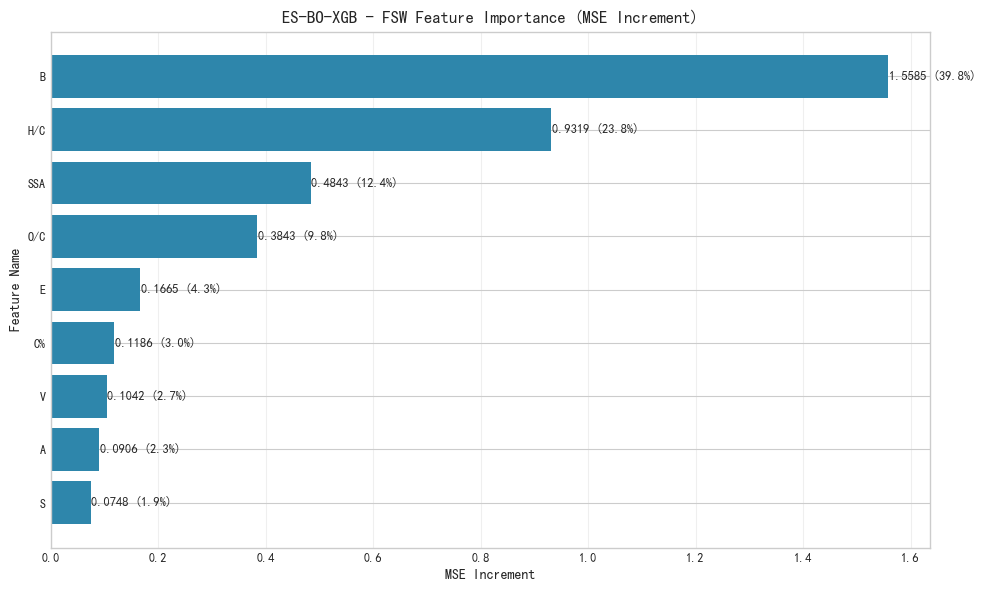

In [99]:
def fsw_feature_importance(model, x_data, y_data, feature_names, model_name="Model"):
    """
    FSW Perturbation-Based Feature Importance: Replace features with their means and calculate the MSE increment.
    The larger the MSE increment, the more important the feature.
    """
    if isinstance(x_data, pd.DataFrame):
        x_data = x_data.values
    x_data = np.array(x_data)
    if x_data.ndim == 1:
        x_data = x_data.reshape(-1, 1)
    
    # Baseline MSE (all features)
    y_pred_base = model.predict(x_data)
    base_mse = mean_squared_error(y_data, y_pred_base)
    print(f"\{model_name} FSW Feature Importance")
    print(f"Baseline MSE (all features): {base_mse:.6f}")
    
    # Calculate the MSE increment for each feature
    fsw_importance = []
    for i, feat in enumerate(feature_names):
        x_modified = x_data.copy()
        x_modified[:, i] = np.mean(x_data[:, i])
        
        y_pred_modified = model.predict(x_modified)
        modified_mse = mean_squared_error(y_data, y_pred_modified)
        mse_increase = modified_mse - base_mse
        
        fsw_importance.append({
            "feature": feat,
            "modified_mse": modified_mse,
            "mse_increase": mse_increase,
            "importance_ratio": 0.0
        })

    # Sorting + Calculating Weighted Proportions
    fsw_df = pd.DataFrame(fsw_importance).sort_values("mse_increase", ascending=False)
    total_mse_increase = fsw_df['mse_increase'].sum()
    fsw_df['importance_ratio'] = (fsw_df['mse_increase'] / total_mse_increase) * 100
    
    # Print results
    print("\nFeature importance ranking (the higher the MSE increment, the more important the feature):")
    print(fsw_df[["feature", "mse_increase", "importance_ratio"]].round(4))
    
    # Drawing
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    plt.figure(figsize=(10, 6))
    
    sorted_feats = fsw_df['feature'].tolist()
    sorted_increase = fsw_df['mse_increase'].tolist()
    sorted_ratio = fsw_df['importance_ratio'].tolist()

    bars = plt.barh(sorted_feats, sorted_increase, color='#2E86AB')
    plt.gca().invert_yaxis()
    
    # Add label
    for i, bar in enumerate(bars):
        width = bar.get_width()
        label = f'{width:.4f} ({sorted_ratio[i]:.1f}%)'
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 label, ha='left', va='center', fontsize=9)
    
    plt.title(f'{model_name} - FSW Feature Importance (MSE Increment)', fontsize=12, fontweight='bold')
    plt.xlabel('MSE Increment', fontsize=10)
    plt.ylabel('Feature Name', fontsize=10)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return fsw_df

fsw_final_df = fsw_feature_importance(final_es_bayes_model, x_train, y_train, feature_names, model_name="ES-BO-XGB")

ES-BO-XGB SHAP (Mean Absolute Shapley - MAS) Feature Importance 
Shapley-MAS Feature Importance (Higher MAS value = more important):
  feature  MAS_value  importance_ratio
7       B     0.7177         36.367802
0     SSA     0.2362         11.966600
2     H/C     0.2354         11.928100
4       E     0.1837          9.305500
6       A     0.1818          9.210500
3     O/C     0.1197          6.063800
8       V     0.1119          5.671300
5       S     0.1026          5.196600
1      C%     0.0847          4.289700


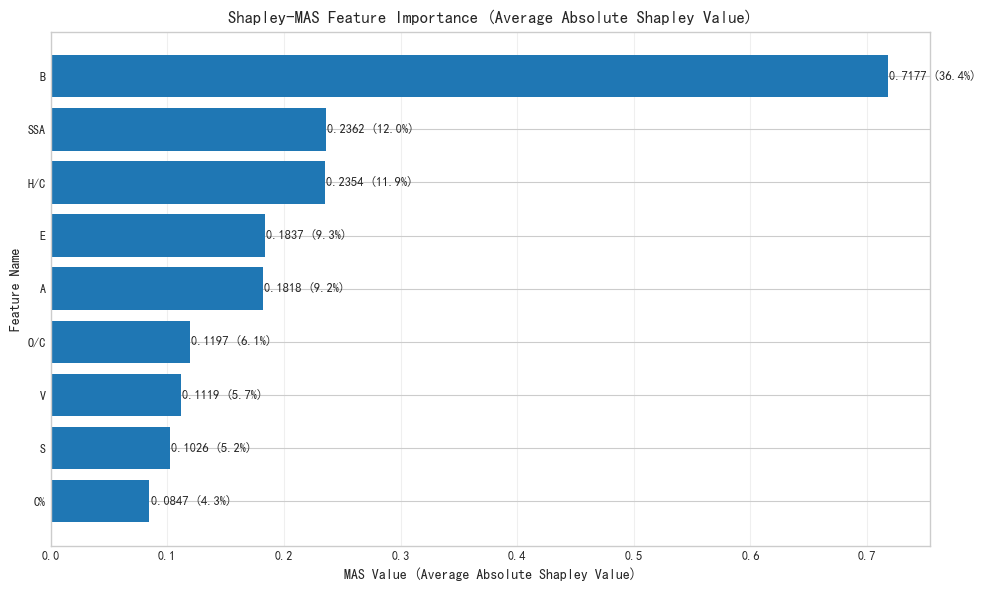

In [100]:
print("ES-BO-XGB SHAP (Mean Absolute Shapley - MAS) Feature Importance ")
def shap_mas_importance(model, x_data, feature_names):
    if isinstance(x_data, pd.DataFrame):
        x_data = x_data.values 
    x_data = np.array(x_data)
    if x_data.ndim == 1:
        x_data = x_data.reshape(-1, 1)
    
    # Initialize SHAP TreeExplainer
    explainer = shap.TreeExplainer(model)
    
    # Calculate SHAP values for the dataset
    shap_values = explainer.shap_values(x_data)
    
    # Calculate MAS importance (mean absolute Shapley value per feature)
    mas_importance = np.abs(shap_values).mean(axis=0)
    
    total_mas = np.sum(mas_importance)
    mas_ratio = (mas_importance / total_mas) * 100
    
    shap_df = pd.DataFrame({
        "feature": feature_names,
        "MAS_value": mas_importance,
        "importance_ratio": mas_ratio
    }).sort_values("MAS_value", ascending=False)

    # Visualization
    print("Shapley-MAS Feature Importance (Higher MAS value = more important):")
    print(shap_df[["feature", "MAS_value", "importance_ratio"]].round(4))

    plt.rcParams['font.sans-serif'] = ['SimHei'] 
    plt.rcParams['axes.unicode_minus'] = False  
    
    plt.figure(figsize=(10, 6))
    sorted_features = shap_df['feature'].tolist()
    sorted_mas = shap_df['MAS_value'].tolist()
    sorted_ratio = shap_df['importance_ratio'].tolist()

    bars = plt.barh(sorted_features, sorted_mas, color='#1f77b4')
    plt.gca().invert_yaxis()
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ratio = sorted_ratio[i]
        label_text = f'{width:.4f} ({ratio:.1f}%)'
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 label_text, ha='left', va='center', fontsize=9)

    plt.title('Shapley-MAS Feature Importance (Average Absolute Shapley Value)', fontsize=12, fontweight='bold')
    plt.xlabel('MAS Value (Average Absolute Shapley Value)', fontsize=10)
    plt.ylabel('Feature Name', fontsize=10)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout() 
    plt.show()

    return shap_df, shap_values

feature_names = ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V']
shap_importance_df, shap_values = shap_mas_importance(final_es_bayes_model, x_train, feature_names)

ES-BO-XGB Global Sensitivity Analysis (GSA) via Sobol Method
Generated Sobol sample points: 110000
Sobol Global Sensitivity Ranking (Higher ST = More Influential):
  feature  Sobol_ST  importance_ratio
7       B    0.4763           34.3822
4       E    0.2981           21.5216
3     O/C    0.1848           13.3425
5       S    0.1532           11.0630
2     H/C    0.0664            4.7956
1      C%    0.0657            4.7447
0     SSA    0.0579            4.1831
6       A    0.0451            3.2537
8       V    0.0376            2.7137


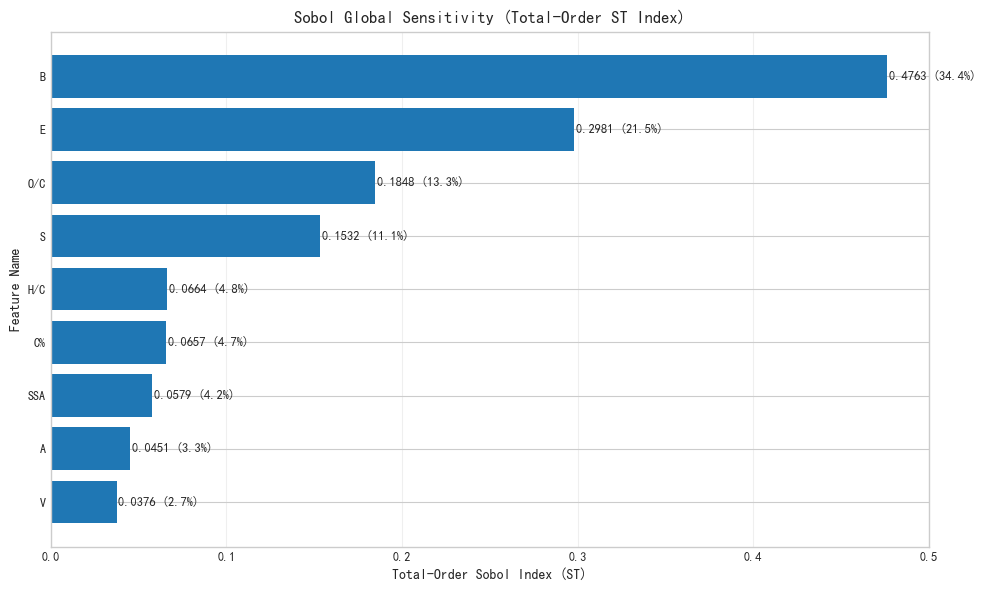

In [101]:
print("ES-BO-XGB Global Sensitivity Analysis (GSA) via Sobol Method")
def sobol_gsa_importance(model, x_data, feature_names, n_samples=10000):
    if isinstance(x_data, pd.DataFrame):
        x_np = x_data.values
    else:
        x_np = np.asarray(x_data)
    if x_np.ndim == 1:
        x_np = x_np.reshape(-1, 1)

    # Define parameter bounds based on observed training data range
    param_bounds = []
    for i in range(x_np.shape[1]):
        param_bounds.append([float(x_np[:, i].min()), float(x_np[:, i].max())])
    
    # Construct SALib problem specification
    problem = {
        "num_vars": len(feature_names),
        "names": feature_names,
        "bounds": param_bounds
    }
    
    # Generate Sobol sampling matrix
    param_values = saltelli.sample(
        problem, 
        n_samples, 
        calc_second_order=False) 
    print(f"Generated Sobol sample points: {param_values.shape[0]}")
    
    y_pred_sobol = model.predict(param_values)
    
    # Perform Sobol sensitivity analysis
    sobol_results = sobol.analyze(problem, y_pred_sobol, calc_second_order=False)
    si_values = sobol_results["ST"]  # Total-order Sobol indices

    sobol_df = pd.DataFrame({
        "feature": feature_names,
        "Sobol_ST": si_values,
        "importance_ratio": (si_values / np.nansum(si_values)) * 100 
    }).sort_values("Sobol_ST", ascending=False)
    
    # Visualization
    print("Sobol Global Sensitivity Ranking (Higher ST = More Influential):")
    print(sobol_df[["feature", "Sobol_ST", "importance_ratio"]].round(4))
    

    plt.rcParams['font.sans-serif'] = ['SimHei']  
    plt.rcParams['axes.unicode_minus'] = False  
    
    plt.figure(figsize=(10, 6))
    sorted_features = sobol_df['feature'].tolist()
    sorted_sobol = sobol_df['Sobol_ST'].tolist()
    sorted_ratio = sobol_df['importance_ratio'].tolist()  
    
    bars = plt.barh(sorted_features, sorted_sobol, color='#1f77b4')
    plt.gca().invert_yaxis()
    
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ratio = sorted_ratio[i]
        label_text = f'{width:.4f} ({ratio:.1f}%)'
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 label_text, ha='left', va='center', fontsize=9)
    
    plt.title('Sobol Global Sensitivity (Total-Order ST Index)', fontsize=12, fontweight='bold')
    plt.xlabel('Total-Order Sobol Index (ST)', fontsize=10)
    plt.ylabel('Feature Name', fontsize=10)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout() 
    plt.show()
    
    return sobol_df, sobol_results

feature_names = ['SSA', 'C%', 'H/C', 'O/C', 'E', 'S', 'A', 'B', 'V']
sobol_importance_df, sobol_results = sobol_gsa_importance(final_es_bayes_model, x_train, feature_names, n_samples=10000)